# Training NPZ Spectral And Reduced-Velocity Analysis

Load the exported training `.npz` files, compare CFD and Vivana-TD spectra for each case, and plot spectral and summary diagnostics as a function of reduced velocity.


In [23]:
# Block 1: core notebook imports and plotting style.
from __future__ import annotations

import importlib
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import scipy.signal as signal
import numpy as np

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable=None, **kwargs):
        return iterable

plt.style.use("seaborn-v0_8-whitegrid")

In [24]:
# Block 2: locate the repo/data roots and define shared notebook configuration.
CWD = Path.cwd().resolve()
REPO_ROOT_CANDIDATES = [
    CWD,
    CWD.parent,
    CWD.parent.parent,
]
REPO_ROOT = next((path.resolve() for path in REPO_ROOT_CANDIDATES if (path / "training/training_utils.py").exists()), None)
if REPO_ROOT is None:
    tried = "\n".join(str(path) for path in REPO_ROOT_CANDIDATES)
    raise FileNotFoundError(f"Could not locate repo root. Tried:\n{tried}")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
CFD_DATA_DIR_CANDIDATES = [
    REPO_ROOT / "vivana_cfd_data_pipeline",
    CWD / "vivana_cfd_data_pipeline",
    CWD,
]
CFD_DATA_DIR = next((path.resolve() for path in CFD_DATA_DIR_CANDIDATES if (path / "training_npz_loader.py").exists()), None)
if CFD_DATA_DIR is None:
    tried = "\n".join(str(path) for path in CFD_DATA_DIR_CANDIDATES)
    raise FileNotFoundError(f"Could not locate vivana_cfd_data_pipeline directory. Tried:\n{tried}")
if str(CFD_DATA_DIR) not in sys.path:
    sys.path.insert(0, str(CFD_DATA_DIR))

from training_npz_loader import (
    iter_all_npz_files as shared_iter_all_npz_files,
    iter_npz_files as shared_iter_npz_files,
    load_series as shared_load_series,
    resolve_dataset_root,
)

PREFERRED_DATASET_CANDIDATES = [
    CFD_DATA_DIR / "npz_exports_td_burnin_trimmed",
    CFD_DATA_DIR / "npz_exports",
    CWD / "vivana_cfd_data_pipeline" / "npz_exports_td_burnin_trimmed",
    CWD / "vivana_cfd_data_pipeline" / "npz_exports",
    CWD / "npz_exports_td_burnin_trimmed",
    CWD / "npz_exports",
]
DATASET_ROOT = resolve_dataset_root(CWD, repo_root=REPO_ROOT, extra_candidates=PREFERRED_DATASET_CANDIDATES)

ORDERED_SPLIT_DIRS = ("train", "val")
MAX_FILES_PER_SPLIT = None  # Set to an int to limit plots per split.
FIGSIZE = (14, 8)
TD_MASS_SOURCE = "dry"  # dry | effective
TD_PARAM_OVERRIDES = {}
NEWMARK_BETA = 0.25
NEWMARK_GAMMA = 0.5



In [25]:
# Block 3: load the helper module from the vivana_cfd_data_pipeline folder and expose the shared dataset-loading helpers.
import importlib.util
import sys

helpers_path = CFD_DATA_DIR / 'helpers' / 'spectral_metrics.py'
spec = importlib.util.spec_from_file_location('spectral_metrics', helpers_path)
if spec is None or spec.loader is None:
    raise ImportError(f'Could not load helper module from {helpers_path}')
spectral_helpers = importlib.util.module_from_spec(spec)
sys.modules['spectral_metrics'] = spectral_helpers
spec.loader.exec_module(spectral_helpers)

load_series, iter_npz_files, iter_all_npz_files = spectral_helpers.build_dataset_accessors(
    load_series_fn=shared_load_series,
    iter_npz_files_fn=shared_iter_npz_files,
    iter_all_npz_files_fn=shared_iter_all_npz_files,
    split_dirs=ORDERED_SPLIT_DIRS,
    max_files_per_split=MAX_FILES_PER_SPLIT,
)


In [26]:
# Block 4: bind the TD/SIMA/PSD helper functions used by the analysis blocks below.
resolve_td_params = spectral_helpers.resolve_td_params
simulate_structural_response_with_force_rk4 = spectral_helpers.simulate_structural_response_with_force_rk4
simulate_vivana_td = spectral_helpers.simulate_vivana_td
load_sima_series_for_npz = spectral_helpers.load_sima_series_for_npz
compute_psd_welch = spectral_helpers.compute_psd_welch
suggest_psd_xlim = spectral_helpers.suggest_psd_xlim
normalize_psd_area = spectral_helpers.normalize_psd_area

TD_PARAMS = resolve_td_params(TD_PARAM_OVERRIDES)


In [27]:
# Block 5: quick dataset sanity check showing how many NPZ files will be analyzed.
files = iter_all_npz_files(DATASET_ROOT)
print(f"all: {len(files)} file(s)")


all: 14 file(s)


Block 6 selected 7 longest representative timeseries from 14 available files.
Skipping SIMA overlay for comb_Ur2__2Hydro: Case 'comb_Ur2__2Hydro' does not contain enough samples for HIDDEN_STATE_BURNIN_SECONDS=0.0.
Skipping SIMA overlay for comb_Ur4__Hydro: Case 'comb_Ur4__Hydro' does not contain enough samples for HIDDEN_STATE_BURNIN_SECONDS=0.0.
Skipping SIMA overlay for comb_Ur5__2Hydro: Case 'comb_Ur5__2Hydro' does not contain enough samples for HIDDEN_STATE_BURNIN_SECONDS=0.0.
Skipping SIMA overlay for comb_Ur575__2Hydro: Case 'comb_Ur575__2Hydro' does not contain enough samples for HIDDEN_STATE_BURNIN_SECONDS=0.0.
Skipping SIMA overlay for comb_Ur7__2Hydro: Case 'comb_Ur7__2Hydro' does not contain enough samples for HIDDEN_STATE_BURNIN_SECONDS=0.0.
Skipping SIMA overlay for comb_Ur8__3Hydro: Case 'comb_Ur8__3Hydro' does not contain enough samples for HIDDEN_STATE_BURNIN_SECONDS=0.0.
Skipping SIMA overlay for comb_Ur10__3Hydro: Case 'comb_Ur10__3Hydro' does not contain enough samp

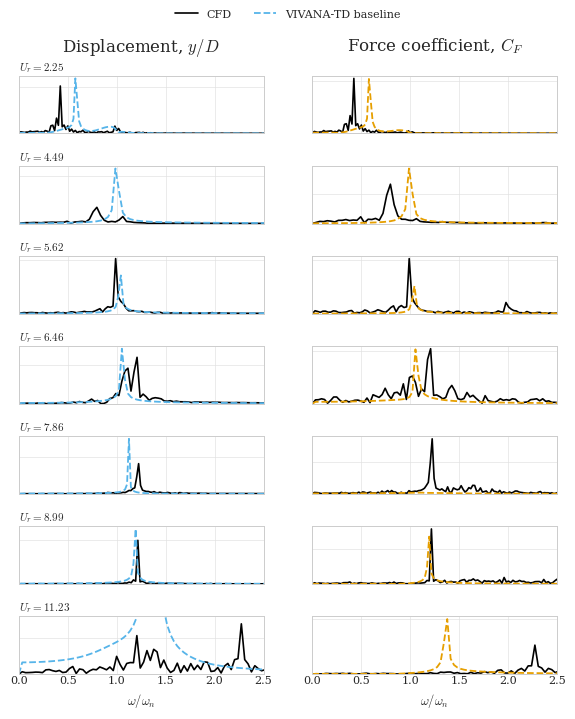

In [28]:
# Block 6: compare CFD, VIVANA-TD baseline, and optional SIMA amplitude spectra.
series_force_coefficient = spectral_helpers.series_force_coefficient

files = iter_all_npz_files(DATASET_ROOT)

BLOCK_6_VIVANA_TD_SWEEP_SPECS = [
    {
        'label': 'VIVANA-TD baseline',
        'color': '#56B4E9',
        'disp_color': '#56B4E9',
        'force_color': '#E69F00',
        'linestyle': '--',
        'linewidth': 1.3,
        'fmax': 0.26,
        'f0': 0.18,
        'fmin': 0.11,
        'cv': 1.2,
        'cd': 1.1,
        'ca': 1.0,
    },
]
BLOCK_6_TD_SWEEP_KEY_MAP = {
    'cv': 'td_cv',
    'cd': 'td_cd',
    'ca': 'td_ca',
    'f0': 'td_fhat0',
    'fmin': 'td_fhat_min',
    'fmax': 'td_fhat_max',
}

def _b6_td_sweep_overrides(spec):
    overrides = {}
    for short_key, td_key in BLOCK_6_TD_SWEEP_KEY_MAP.items():
        value = spec.get(short_key)
        if value is not None:
            overrides[td_key] = float(value)
    return overrides

def _b6_amplitude_spectrum(time, values):
    time = np.asarray(time, dtype=float).reshape(-1)
    values = np.asarray(values, dtype=float).reshape(-1)
    n = min(time.size, values.size)
    if n < 4:
        raise ValueError('Need at least four samples to compute an amplitude spectrum.')
    time = time[:n]
    values = values[:n]
    dt = float(np.median(np.diff(time)))
    if not np.isfinite(dt) or dt <= 0.0:
        raise ValueError('Need a positive finite dt to compute an amplitude spectrum.')
    centered = values - float(np.mean(values))
    freqs = np.fft.rfftfreq(n, d=dt)
    amplitudes = np.abs(np.fft.rfft(centered)) / float(n)
    if amplitudes.size > 1:
        if n % 2 == 0:
            amplitudes[1:-1] *= 2.0
        else:
            amplitudes[1:] *= 2.0
    return freqs, amplitudes

def _b6_frequency_ratio(series, freqs):
    stiffness = float(series['stiffness'])
    effective_mass = float(series['effective_mass'])
    natural_frequency_hz = math.sqrt(stiffness / effective_mass) / (2.0 * math.pi)
    return np.asarray(freqs, dtype=float) / natural_frequency_hz

def _b6_series_duration(series):
    time = np.asarray(series['time'], dtype=float).reshape(-1)
    finite = time[np.isfinite(time)]
    if finite.size < 2:
        return 0.0
    return float(np.max(finite) - np.min(finite))

def _b6_assign_case_numbers_by_ur(series_list):
    grouped = {}
    for series in sorted(series_list, key=lambda item: (round(float(item['ur_effective']), 6), str(item['name']))):
        key = round(float(series['ur_effective']), 6)
        grouped[key] = grouped.get(key, 0) + 1
        series['case_index_for_ur'] = grouped[key]

def _b6_select_longest_timeseries_by_ur(series_list):
    grouped = {}
    for series in series_list:
        grouped.setdefault(round(float(series['ur_effective']), 6), []).append(series)
    representatives = []
    for _ur_key, entries in sorted(grouped.items(), key=lambda item: item[0]):
        representatives.append(
            max(
                entries,
                key=lambda item: (_b6_series_duration(item), np.asarray(item['time']).size, str(item['name'])),
            )
        )
    return representatives

series_rollouts = []
_b6_all_series = [load_series(path) for path in files]
_b6_all_series = [series for series in _b6_all_series if np.isfinite(float(series['ur_effective']))]
_b6_assign_case_numbers_by_ur(_b6_all_series)
_b6_selected_series = _b6_select_longest_timeseries_by_ur(_b6_all_series)
print(f"Block 6 selected {len(_b6_selected_series)} longest representative timeseries from {len(_b6_all_series)} available files.")

for series in _b6_selected_series:
    rollouts = []
    for sweep_spec in BLOCK_6_VIVANA_TD_SWEEP_SPECS:
        sweep_cfg = dict(TD_PARAM_OVERRIDES)
        sweep_cfg.update(_b6_td_sweep_overrides(sweep_spec))
        sweep_td_params = resolve_td_params(sweep_cfg)
        rollouts.append({
            'label': sweep_spec['label'],
            'color': sweep_spec['color'],
            'disp_color': sweep_spec['disp_color'],
            'force_color': sweep_spec['force_color'],
            'linestyle': sweep_spec['linestyle'],
            'linewidth': float(sweep_spec['linewidth']),
            'rollout': simulate_vivana_td(series, td_params=sweep_td_params, mass_source=TD_MASS_SOURCE),
        })
    sima_series = load_sima_series_for_npz(series)
    series_rollouts.append((series, rollouts, sima_series))

if not series_rollouts:
    raise ValueError('No NPZ files found to plot.')

series_rollouts.sort(key=lambda x: float(x[0]['ur_effective']))

n_cases = len(series_rollouts)
ncols = 2
nrows = n_cases
BLOCK_6_CFD_COLOR = 'black'
BLOCK_6_SIMA_COLOR = '#009E73'
BLOCK_6_LABEL_FONTSIZE = 9
BLOCK_6_TICK_FONTSIZE = 8
BLOCK_6_LEGEND_FONTSIZE = 8
BLOCK_6_PANEL_FONTSIZE = 9
BLOCK_6_XMIN = 0.0
BLOCK_6_XMAX_DISP = 2.5
BLOCK_6_XMAX_FORCE = 2.5
BLOCK_6_FIGURE_DPI = 300
BLOCK_6_FIGURE_PATH = REPO_ROOT / 'figures' / 'spectral_block_6_amplitude_spectra.pdf'

_skip_zero_fmt = plt.FuncFormatter(lambda val, pos: '' if val == 0 else f'{val:g}')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Latin Modern Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'axes.unicode_minus': False,
})

_b6_spectrum_data = []
for series, rollouts, sima_series in series_rollouts:
    freq_disp_true, amp_disp_true = _b6_amplitude_spectrum(series['time'], series['displacement'])
    freq_force_true, amp_force_true = _b6_amplitude_spectrum(
        series['time'],
        series_force_coefficient(series, series['force_per_m']),
    )
    td_spectra = []
    for rollout_spec in rollouts:
        rollout = rollout_spec['rollout']
        freq_disp_td, amp_disp_td = _b6_amplitude_spectrum(series['time'], rollout['displacement_td'])
        freq_force_td, amp_force_td = _b6_amplitude_spectrum(
            series['time'],
            series_force_coefficient(series, rollout['force_td']),
        )
        td_spectra.append({
            **{key: rollout_spec[key] for key in ('label', 'color', 'disp_color', 'force_color', 'linestyle', 'linewidth')},
            'x_disp': _b6_frequency_ratio(series, freq_disp_td),
            'amp_disp': amp_disp_td,
            'x_force': _b6_frequency_ratio(series, freq_force_td),
            'amp_force': amp_force_td,
        })
    x_disp_sima = amp_disp_sima = x_force_sima = amp_force_sima = None
    if sima_series is not None:
        freq_disp_sima, amp_disp_sima = _b6_amplitude_spectrum(sima_series['time'], sima_series['displacement'])
        freq_force_sima, amp_force_sima = _b6_amplitude_spectrum(
            sima_series['time'],
            series_force_coefficient(sima_series, sima_series['force_per_m']),
        )
        x_disp_sima = _b6_frequency_ratio(series, freq_disp_sima)
        x_force_sima = _b6_frequency_ratio(series, freq_force_sima)
    _b6_spectrum_data.append({
        'ur': float(series['ur_effective']),
        'case_index_for_ur': int(series.get('case_index_for_ur', 1)),
        'x_disp_true': _b6_frequency_ratio(series, freq_disp_true),
        'amp_disp_true': amp_disp_true,
        'x_force_true': _b6_frequency_ratio(series, freq_force_true),
        'amp_force_true': amp_force_true,
        'td_spectra': td_spectra,
        'x_disp_sima': x_disp_sima,
        'amp_disp_sima': amp_disp_sima,
        'x_force_sima': x_force_sima,
        'amp_force_sima': amp_force_sima,
        'has_sima': sima_series is not None,
    })

def _b6_plot_amplitude_spectra_grid(data_list, save_path=None):
    n_rows = len(data_list)
    fig_height = min(7.4, max(2.4, 1.03 * n_rows))
    fig, axes = plt.subplots(n_rows, 2, figsize=(5.85, fig_height), squeeze=False, sharex='col')
    for row_idx, d in enumerate(data_list):
        ax_disp = axes[row_idx, 0]
        ax_force = axes[row_idx, 1]

        ax_disp.plot(d['x_disp_true'], d['amp_disp_true'], label='CFD', color=BLOCK_6_CFD_COLOR, linewidth=1.2)
        ax_force.plot(d['x_force_true'], d['amp_force_true'], label='CFD', color=BLOCK_6_CFD_COLOR, linewidth=1.2)
        for td in d['td_spectra']:
            ax_disp.plot(td['x_disp'], td['amp_disp'], label=td['label'], color=td['disp_color'], linestyle=td['linestyle'], linewidth=td['linewidth'])
            ax_force.plot(td['x_force'], td['amp_force'], label=td['label'], color=td['force_color'], linestyle=td['linestyle'], linewidth=td['linewidth'])
        if d['has_sima']:
            ax_disp.plot(d['x_disp_sima'], d['amp_disp_sima'], label='SIMA', color=BLOCK_6_SIMA_COLOR, linewidth=1.0, linestyle=':')
            ax_force.plot(d['x_force_sima'], d['amp_force_sima'], label='SIMA', color=BLOCK_6_SIMA_COLOR, linewidth=1.0, linestyle=':')

        label = rf"$U_r={d['ur']:.2f}$"
        ax_disp.text(
            0.0,
            1.035,
            label,
            transform=ax_disp.transAxes,
            ha='left',
            va='bottom',
            fontsize=8,
            clip_on=False,
        )
        if row_idx == 0:
            ax_disp.set_title(r'Displacement, $y/D$', pad=18)
            ax_force.set_title(r'Force coefficient, $C_F$', pad=18)
        for ax in (ax_disp, ax_force):
            ax.tick_params(axis='x', labelsize=BLOCK_6_TICK_FONTSIZE, pad=1)
            ax.tick_params(axis='y', left=False, labelleft=False)
            ax.grid(True, color='0.88', linewidth=0.45)
            ax.set_ylim(bottom=0)
            ax.yaxis.set_major_formatter(_skip_zero_fmt)
            for spine in ax.spines.values():
                spine.set_linewidth(0.7)
        if np.isclose(float(d['ur']), 11.23, atol=0.02):
            _mask_1123 = (d['x_disp_true'] >= BLOCK_6_XMIN) & (d['x_disp_true'] <= BLOCK_6_XMAX_DISP)
            _cfd_peak_1123 = float(np.nanmax(d['amp_disp_true'][_mask_1123])) if np.any(_mask_1123) else float(np.nanmax(d['amp_disp_true']))
            if np.isfinite(_cfd_peak_1123) and _cfd_peak_1123 > 0.0:
                ax_disp.set_ylim(0.0, 1.15 * _cfd_peak_1123)
        ax_disp.set_xlim(BLOCK_6_XMIN, BLOCK_6_XMAX_DISP)
        ax_force.set_xlim(BLOCK_6_XMIN, BLOCK_6_XMAX_FORCE)
        if row_idx == n_rows - 1:
            ax_disp.set_xlabel(r'$\omega/\omega_n$', fontsize=BLOCK_6_LABEL_FONTSIZE)
            ax_force.set_xlabel(r'$\omega/\omega_n$', fontsize=BLOCK_6_LABEL_FONTSIZE)
        else:
            ax_disp.set_xlabel('')
            ax_force.set_xlabel('')

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=max(1, len(labels)), fontsize=BLOCK_6_LEGEND_FONTSIZE, frameon=False)
    fig.tight_layout()
    fig.subplots_adjust(left=0.075, right=0.995, bottom=0.07, top=0.90, hspace=0.56, wspace=0.20)
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=BLOCK_6_FIGURE_DPI, bbox_inches='tight', pad_inches=0.02)
        print(f"Saved: {save_path}")
    plt.show()
    plt.close(fig)

_b6_plot_amplitude_spectra_grid(_b6_spectrum_data, save_path=BLOCK_6_FIGURE_PATH)


Vivana-TD summary generation grid: dt=0.006 s, first case total duration=799.168 s, first case transient trimmed=400.0 s, later cases total duration=300.0 s, later-case transient trimmed=100.0 s


Block 7: CFD/SIMA summaries:   7%|▋         | 1/14 [00:00<00:01,  8.25it/s]

Skipping SIMA overlay for comb_Ur10__1Hydro: Case 'comb_Ur10__1Hydro' does not contain enough samples for HIDDEN_STATE_BURNIN_SECONDS=0.0.


Block 7: CFD/SIMA summaries:  14%|█▍        | 2/14 [00:00<00:01,  8.58it/s]

Skipping SIMA overlay for comb_Ur2__1Hydro: Case 'comb_Ur2__1Hydro' does not contain enough samples for HIDDEN_STATE_BURNIN_SECONDS=0.0.


...

Block 7: CFD/SIMA summaries: 100%|██████████| 14/14 [00:01<00:00, 12.61it/s]


Block 7 sweep 1/2: VIVANA-TD baseline -> {'Cv': 1.2, 'Cd': 1.1, 'Ca': 1.0, 'fhat0': 0.18, 'fhat_min': 0.11, 'fhat_max': 0.26, 'n_memory': 500.0}


Block 7: VIVANA-TD baseline: 100%|██████████| 181/181 [00:38<00:00,  4.69it/s]


Block 7 sweep 2/2: VIVANA-TD modified -> {'Cv': 1.03, 'Cd': 1.02, 'Ca': 1.95, 'fhat0': 0.142, 'fhat_min': 0.142, 'fhat_max': 0.173, 'n_memory': 500.0}


Block 7: VIVANA-TD modified: 100%|██████████| 181/181 [00:39<00:00,  4.60it/s]


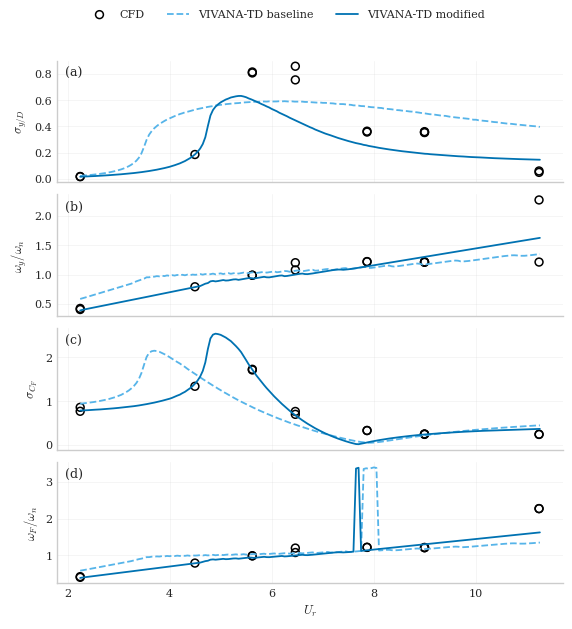

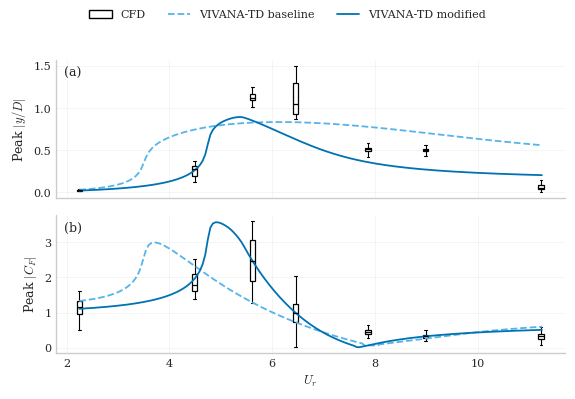

In [29]:
# Block 7: generate reduced-velocity summary metrics and compare CFD, Vivana-TD, SIMA, and RK4 references.
# Summary metrics vs reduced velocity
# Vivana-TD summary sweeps use a common synthetic dt from the CFD data.
# The first generated case gets a long settle time, then later cases reuse the
# previous final state and run on a shorter continuation window.
VIVANA_FINE_UR_STEP = 0.05
VIVANA_SUMMARY_MASS_SOURCE = 'dry'
VIVANA_TRANSIENT_SECONDS = 100.0
VIVANA_FIRST_CASE_EXTRA_SECONDS = 300.0
VIVANA_CONTINUATION_TRANSIENT_SECONDS = 100.0
VIVANA_CONTINUATION_KEPT_SECONDS = 200.0
VIVANA_TD_MEMORY_TAU_SECONDS = 'tau_over_tref:4'
VIVANA_TD_SWEEP_SPECS = [
    {
        'label': 'VIVANA-TD baseline',
        'color': '#56B4E9',
        'linestyle': '--',
        'linewidth': 1.3,
        'fmax': 0.26,
        'f0': 0.18,
        'fmin': 0.11,
        'cv': 1.2,
        'cd': 1.1,
        'ca': 1.0,
    },
    {
       'label': 'VIVANA-TD modified',
       'color': '#0072B2',
       'linestyle': '-',
       'linewidth': 1.3,
       'fmax':  0.173,
       'f0': 0.142,
       'fmin': 0.142,
       'cv': 1.03,
       'cd': 1.02,
       'ca': 1.95
    },
]


dominant_frequency_from_signal = spectral_helpers.dominant_frequency_from_signal
displacement_peak_amplitudes = spectral_helpers.displacement_peak_amplitudes
instantaneous_phase_lag_deg_samples = spectral_helpers.instantaneous_phase_lag_deg_samples
compute_summary_metrics = spectral_helpers.compute_summary_metrics
global_generation_grid = spectral_helpers.global_generation_grid
resolve_td_params_for_dt = spectral_helpers.resolve_td_params_for_dt
generate_vivana_summary_rollout = spectral_helpers.generate_vivana_summary_rollout
series_force_coefficient = spectral_helpers.series_force_coefficient
sorted_group_stats = spectral_helpers.sorted_group_stats
plot_scalar_metric = spectral_helpers.plot_scalar_metric
plot_scalar_metric_grid = spectral_helpers.plot_scalar_metric_grid
boxplot_width = spectral_helpers.boxplot_width
plot_peak_boxplot = spectral_helpers.plot_peak_boxplot
plot_peak_amplitude_boxplot_grid = spectral_helpers.plot_peak_amplitude_boxplot_grid
plot_phase_lag_summary = spectral_helpers.plot_phase_lag_summary


TD_SWEEP_KEY_MAP = {
    'cv': 'td_cv',
    'cd': 'td_cd',
    'ca': 'td_ca',
    'f0': 'td_fhat0',
    'fmin': 'td_fhat_min',
    'fmax': 'td_fhat_max',
}


def td_sweep_overrides(spec):
    overrides = {}
    for short_key, td_key in TD_SWEEP_KEY_MAP.items():
        value = spec.get(short_key)
        if value is not None:
            overrides[td_key] = float(value)
    return overrides



def td_sweep_label(spec, idx):
    explicit_label = spec.get('label')
    if explicit_label:
        return str(explicit_label)
    parts = []
    for key in ('fmin', 'f0', 'fmax', 'ca', 'cv', 'cd'):
        value = spec.get(key)
        if value is not None:
            parts.append(f"{key}={float(value):.3g}")
    if parts:
        return 'Vivana-TD (' + ', '.join(parts) + ')'
    return f'Vivana-TD case {idx + 1}'


VIVANA_TD_BASELINE_SPEC = dict(VIVANA_TD_SWEEP_SPECS[0])
VIVANA_TD_BASELINE_PARAM_OVERRIDES = dict(TD_PARAM_OVERRIDES)
VIVANA_TD_BASELINE_PARAM_OVERRIDES.update(td_sweep_overrides(VIVANA_TD_BASELINE_SPEC))
VIVANA_TD_BASELINE_PARAMS = resolve_td_params(VIVANA_TD_BASELINE_PARAM_OVERRIDES)



def build_vivana_plot_specs(runs, metric_key):
    specs = []
    for run in runs:
        plot_spec = {
            'grouped': run[metric_key],
            'label': run['label'],
            'show_points': False,
        }
        for style_key in ('color', 'linestyle', 'linewidth', 'alpha', 'size', 'marker'):
            style_value = run.get(style_key)
            if style_value is not None:
                plot_spec[style_key] = style_value
        specs.append(plot_spec)
    return specs


def build_vivana_response_plot_specs(runs, metric_key, *, baseline_color, modified_color):
    specs = build_vivana_plot_specs(runs, metric_key)
    for spec in specs:
        label = str(spec.get('label', '')).lower()
        if 'baseline' in label:
            spec['color'] = baseline_color
            spec['linestyle'] = '--'
        elif 'modified' in label:
            spec['color'] = modified_color
            spec['linestyle'] = '-'
        spec['linewidth'] = 1.3
        spec['use_anchor_urs'] = False
    return specs


all_summary_series = [load_series(path) for path in iter_all_npz_files(DATASET_ROOT)]
all_summary_series = [series for series in all_summary_series if np.isfinite(series['ur_effective'])]
summary_generation_dt, summary_generation_duration_s, summary_time_full, summary_keep_mask = global_generation_grid(
    all_summary_series,
    transient_seconds=VIVANA_TRANSIENT_SECONDS,
)
first_case_duration_s = summary_generation_duration_s + VIVANA_FIRST_CASE_EXTRA_SECONDS
first_case_transient_s = VIVANA_TRANSIENT_SECONDS + VIVANA_FIRST_CASE_EXTRA_SECONDS
continuation_duration_s = VIVANA_CONTINUATION_TRANSIENT_SECONDS + VIVANA_CONTINUATION_KEPT_SECONDS
print(
    f"Vivana-TD summary generation grid: dt={summary_generation_dt:.6g} s, "
    f"first case total duration={first_case_duration_s:.3f} s, first case transient trimmed={first_case_transient_s:.1f} s, "
    f"later cases total duration={continuation_duration_s:.1f} s, later-case transient trimmed={VIVANA_CONTINUATION_TRANSIENT_SECONDS:.1f} s"
)

template_series_list = list(all_summary_series)
series_list = list(all_summary_series)
if not series_list:
    raise ValueError('No finite U_r values found, skipping summary-vs-U_r plots.')
if not template_series_list:
    raise ValueError('No finite U_r NPZ templates found, skipping Vivana summary generation.')

cfd_disp_std = {}
cfd_force_std = {}
cfd_dom_freq = {}
cfd_force_dom_freq = {}
cfd_peak_amp = {}
cfd_force_peak_amp = {}
cfd_phase_force_disp = {}
cfd_phase_force_vel = {}
rk4_disp_std = {}
rk4_force_std = {}
rk4_dom_freq = {}
rk4_force_dom_freq = {}
rk4_peak_amp = {}
rk4_force_peak_amp = {}
rk4_phase_force_disp = {}
rk4_phase_force_vel = {}
sima_disp_std = {}
sima_force_std = {}
sima_dom_freq = {}
sima_force_dom_freq = {}
sima_peak_amp = {}
sima_force_peak_amp = {}
sima_phase_force_disp = {}
sima_phase_force_vel = {}

for series in tqdm(series_list, desc='Block 7: CFD/SIMA summaries'):
    key = float(round(float(series['ur_effective']), 6))
    series_force_coeff = series_force_coefficient(series, series['force_per_m'])
    metrics = compute_summary_metrics(
        series['time'],
        series['displacement'],
        series['velocity'],
        series_force_coeff,
        stiffness=series['stiffness'],
        effective_mass=series['effective_mass'],
    )
    cfd_disp_std.setdefault(key, []).append(metrics['disp_std'])
    cfd_force_std.setdefault(key, []).append(metrics['force_std'])
    cfd_dom_freq.setdefault(key, []).append(metrics['dominant_frequency_ratio'])
    cfd_force_dom_freq.setdefault(key, []).append(metrics['force_dominant_frequency_ratio'])
    cfd_peak_amp.setdefault(key, []).extend(metrics['peak_amplitudes'].tolist())
    cfd_force_peak_amp.setdefault(key, []).extend(metrics['force_peak_amplitudes'].tolist())
    phase_force_disp_samples = np.asarray(metrics['phase_force_displacement_deg_samples'], dtype=float)
    phase_force_vel_samples = np.asarray(metrics['phase_force_velocity_deg_samples'], dtype=float)
    if phase_force_disp_samples.size:
        cfd_phase_force_disp.setdefault(key, []).extend(phase_force_disp_samples.tolist())
    if phase_force_vel_samples.size:
        cfd_phase_force_vel.setdefault(key, []).extend(phase_force_vel_samples.tolist())

    rk4_truth = simulate_structural_response_with_force_rk4(
        series,
        series['force_per_m'],
        mass_source=VIVANA_SUMMARY_MASS_SOURCE,
    )
    rk4_metrics = compute_summary_metrics(
        series['time'],
        rk4_truth['displacement'],
        rk4_truth['velocity'],
        series_force_coeff,
        stiffness=series['stiffness'],
        effective_mass=series['effective_mass'],
    )
    rk4_disp_std.setdefault(key, []).append(rk4_metrics['disp_std'])
    rk4_force_std.setdefault(key, []).append(rk4_metrics['force_std'])
    rk4_dom_freq.setdefault(key, []).append(rk4_metrics['dominant_frequency_ratio'])
    rk4_force_dom_freq.setdefault(key, []).append(rk4_metrics['force_dominant_frequency_ratio'])
    rk4_peak_amp.setdefault(key, []).extend(rk4_metrics['peak_amplitudes'].tolist())
    rk4_force_peak_amp.setdefault(key, []).extend(rk4_metrics['force_peak_amplitudes'].tolist())
    rk4_phase_force_disp_samples = np.asarray(rk4_metrics['phase_force_displacement_deg_samples'], dtype=float)
    rk4_phase_force_vel_samples = np.asarray(rk4_metrics['phase_force_velocity_deg_samples'], dtype=float)
    if rk4_phase_force_disp_samples.size:
        rk4_phase_force_disp.setdefault(key, []).extend(rk4_phase_force_disp_samples.tolist())
    if rk4_phase_force_vel_samples.size:
        rk4_phase_force_vel.setdefault(key, []).extend(rk4_phase_force_vel_samples.tolist())

    sima_series = load_sima_series_for_npz(series)
    if sima_series is not None:
        sima_force_coeff = series_force_coefficient(sima_series, sima_series['force_per_m'])
        sima_metrics = compute_summary_metrics(
            sima_series['time'],
            sima_series['displacement'],
            sima_series['velocity'],
            sima_force_coeff,
            stiffness=series['stiffness'],
            effective_mass=series['effective_mass'],
        )
        sima_disp_std.setdefault(key, []).append(sima_metrics['disp_std'])
        sima_force_std.setdefault(key, []).append(sima_metrics['force_std'])
        sima_dom_freq.setdefault(key, []).append(sima_metrics['dominant_frequency_ratio'])
        sima_force_dom_freq.setdefault(key, []).append(sima_metrics['force_dominant_frequency_ratio'])
        sima_peak_amp.setdefault(key, []).extend(sima_metrics['peak_amplitudes'].tolist())
        sima_force_peak_amp.setdefault(key, []).extend(sima_metrics['force_peak_amplitudes'].tolist())
        sima_phase_force_disp_samples = np.asarray(sima_metrics['phase_force_displacement_deg_samples'], dtype=float)
        sima_phase_force_vel_samples = np.asarray(sima_metrics['phase_force_velocity_deg_samples'], dtype=float)
        if sima_phase_force_disp_samples.size:
            sima_phase_force_disp.setdefault(key, []).extend(sima_phase_force_disp_samples.tolist())
        if sima_phase_force_vel_samples.size:
            sima_phase_force_vel.setdefault(key, []).extend(sima_phase_force_vel_samples.tolist())

actual_urs = np.asarray(sorted({float(series['ur_effective']) for series in series_list}), dtype=float)
ur_min = float(np.min(actual_urs))
ur_max = float(np.max(actual_urs))
viv_target_urs = np.arange(ur_min, ur_max + 0.5 * VIVANA_FINE_UR_STEP, VIVANA_FINE_UR_STEP)

viv_runs = []
for sweep_idx, raw_spec in enumerate(VIVANA_TD_SWEEP_SPECS):
    sweep_spec = dict(raw_spec)
    sweep_label = td_sweep_label(sweep_spec, sweep_idx)
    sweep_override_cfg = dict(TD_PARAM_OVERRIDES)
    sweep_override_cfg.update(td_sweep_overrides(sweep_spec))
    sweep_td_params = resolve_td_params(sweep_override_cfg)
    print(f"Block 7 sweep {sweep_idx + 1}/{len(VIVANA_TD_SWEEP_SPECS)}: {sweep_label} -> {sweep_td_params}")

    run = {
        'label': sweep_label,
        'color': sweep_spec.get('color'),
        'linestyle': sweep_spec.get('linestyle', '-'),
        'linewidth': float(sweep_spec.get('linewidth', 1.8)),
        'alpha': float(sweep_spec.get('alpha', 0.20)),
        'size': float(sweep_spec.get('size', 12.0)),
        'marker': sweep_spec.get('marker'),
        'disp_std': {},
        'force_std': {},
        'dom_freq': {},
        'force_dom_freq': {},
        'peak_amp': {},
        'force_peak_amp': {},
        'phase_force_disp': {},
        'phase_force_vel': {},
        'generated_cases': [],
    }

    viv_continuation_state = None
    for target_idx, target_ur in enumerate(tqdm(viv_target_urs, desc=f'Block 7: {sweep_label}')):
        template = min(template_series_list, key=lambda series: abs(float(series['ur_effective']) - float(target_ur)))
        if target_idx == 0:
            rollout_duration_s = first_case_duration_s
            rollout_transient_seconds = first_case_transient_s
        else:
            rollout_duration_s = continuation_duration_s
            rollout_transient_seconds = VIVANA_CONTINUATION_TRANSIENT_SECONDS
        viv_rollout = generate_vivana_summary_rollout(
            template,
            float(target_ur),
            generation_dt=summary_generation_dt,
            generation_duration_s=rollout_duration_s,
            transient_seconds=rollout_transient_seconds,
            td_params=sweep_td_params,
            mass_source=VIVANA_SUMMARY_MASS_SOURCE,
            initial_state=viv_continuation_state,
            td_memory_tau_s=VIVANA_TD_MEMORY_TAU_SECONDS,
        )
        viv_continuation_state = dict(viv_rollout['final_state'])
        viv_force_coeff = series_force_coefficient(viv_rollout, viv_rollout['force'])
        metrics = compute_summary_metrics(
            viv_rollout['time'],
            viv_rollout['displacement'],
            viv_rollout['velocity'],
            viv_force_coeff,
            stiffness=viv_rollout['stiffness'],
            effective_mass=viv_rollout['effective_mass'],
        )
        key = float(round(float(target_ur), 6))
        run['disp_std'].setdefault(key, []).append(metrics['disp_std'])
        run['force_std'].setdefault(key, []).append(metrics['force_std'])
        run['dom_freq'].setdefault(key, []).append(metrics['dominant_frequency_ratio'])
        run['force_dom_freq'].setdefault(key, []).append(metrics['force_dominant_frequency_ratio'])
        run['peak_amp'].setdefault(key, []).extend(metrics['peak_amplitudes'].tolist())
        run['force_peak_amp'].setdefault(key, []).extend(metrics['force_peak_amplitudes'].tolist())
        phase_force_disp_samples = np.asarray(metrics['phase_force_displacement_deg_samples'], dtype=float)
        phase_force_vel_samples = np.asarray(metrics['phase_force_velocity_deg_samples'], dtype=float)
        if phase_force_disp_samples.size:
            run['phase_force_disp'].setdefault(key, []).extend(phase_force_disp_samples.tolist())
        if phase_force_vel_samples.size:
            run['phase_force_vel'].setdefault(key, []).extend(phase_force_vel_samples.tolist())
        run['generated_cases'].append(
            {
                'ur': key,
                'template_series': template,
                'rollout': viv_rollout,
            }
        )

    viv_runs.append(run)

viv_disp_std_specs = build_vivana_response_plot_specs(viv_runs, 'disp_std', baseline_color='#56B4E9', modified_color='#0072B2')
viv_force_std_specs = build_vivana_response_plot_specs(viv_runs, 'force_std', baseline_color='#56B4E9', modified_color='#0072B2')
viv_dom_freq_specs = build_vivana_response_plot_specs(viv_runs, 'dom_freq', baseline_color='#56B4E9', modified_color='#0072B2')
viv_force_dom_freq_specs = build_vivana_response_plot_specs(viv_runs, 'force_dom_freq', baseline_color='#56B4E9', modified_color='#0072B2')
viv_peak_amp_specs = build_vivana_response_plot_specs(viv_runs, 'peak_amp', baseline_color='#56B4E9', modified_color='#0072B2')
viv_force_peak_amp_specs = build_vivana_response_plot_specs(viv_runs, 'force_peak_amp', baseline_color='#56B4E9', modified_color='#0072B2')
for _spec in [*viv_peak_amp_specs, *viv_force_peak_amp_specs]:
    _spec['plot_box'] = False
    _spec['show_box_mean'] = True
    _spec['marker'] = None

block_7_scalar_metric_specs = [
    {
        'metric_name': 'Displacement standard deviation',
        'ylabel': r'$\sigma_{y/D}$',
        'cfd_grouped': cfd_disp_std,
        'viv_grouped': viv_disp_std_specs,
        'sima_grouped': sima_disp_std,
        'panel_label': '(a)',
    },
    {
        'metric_name': 'Dominant displacement frequency ratio',
        'ylabel': r'$\omega_y/\omega_n$',
        'cfd_grouped': cfd_dom_freq,
        'viv_grouped': viv_dom_freq_specs,
        'sima_grouped': sima_dom_freq,
        'panel_label': '(b)',
    },
    {
        'metric_name': 'Force-coefficient standard deviation',
        'ylabel': r'$\sigma_{C_F}$',
        'cfd_grouped': cfd_force_std,
        'viv_grouped': viv_force_std_specs,
        'sima_grouped': sima_force_std,
        'panel_label': '(c)',
    },
    {
        'metric_name': 'Dominant force-coefficient frequency ratio',
        'ylabel': r'$\omega_F/\omega_n$',
        'cfd_grouped': cfd_force_dom_freq,
        'viv_grouped': viv_force_dom_freq_specs,
        'sima_grouped': sima_force_dom_freq,
        'panel_label': '(d)',
    },
]

BLOCK_7_SUMMARY_FIGURE_PATH = REPO_ROOT / 'figures' / 'spectral_block_7_summary_vs_ur.pdf'
BLOCK_7_PEAK_BOX_FIGURE_PATH = REPO_ROOT / 'figures' / 'spectral_block_7_peak_amplitude_boxplots.pdf'
BLOCK_7_SUMMARY_FIGURE_DPI = 300

plot_scalar_metric_grid(
    'All files',
    block_7_scalar_metric_specs,
    vivana_fine_ur_step=VIVANA_FINE_UR_STEP,
    vivana_summary_mass_source=VIVANA_SUMMARY_MASS_SOURCE,
    save_path=BLOCK_7_SUMMARY_FIGURE_PATH,
    save_dpi=BLOCK_7_SUMMARY_FIGURE_DPI,
)

block_7_peak_displacement_specs = [
    {'grouped': cfd_peak_amp, 'label': 'CFD', 'color': 'black', 'facecolor': 'none', 'box_alpha': 1.0, 'marker': 'o', 'markerfacecolor': 'none', 'markeredgecolor': 'black', 'linestyle': 'none', 'linewidth': 0.0, 'show_box_mean': False},
    {'grouped': sima_peak_amp, 'label': 'SIMA', 'color': '#009E73', 'marker': 's'},
    *viv_peak_amp_specs,
]
block_7_peak_force_specs = [
    {'grouped': cfd_force_peak_amp, 'label': 'CFD', 'color': 'black', 'facecolor': 'none', 'box_alpha': 1.0, 'marker': 'o', 'markerfacecolor': 'none', 'markeredgecolor': 'black', 'linestyle': 'none', 'linewidth': 0.0, 'show_box_mean': False},
    {'grouped': sima_force_peak_amp, 'label': 'SIMA', 'color': '#009E73', 'marker': 's'},
    *viv_force_peak_amp_specs,
]

plot_peak_amplitude_boxplot_grid(
    block_7_peak_displacement_specs,
    block_7_peak_force_specs,
    anchor_urs=actual_urs,
    save_path=BLOCK_7_PEAK_BOX_FIGURE_PATH,
    save_dpi=BLOCK_7_SUMMARY_FIGURE_DPI,
)


Saved: /Users/kasperslagstad/Desktop/Masterproject/figures/spectral_block_7_force_term_phases.png


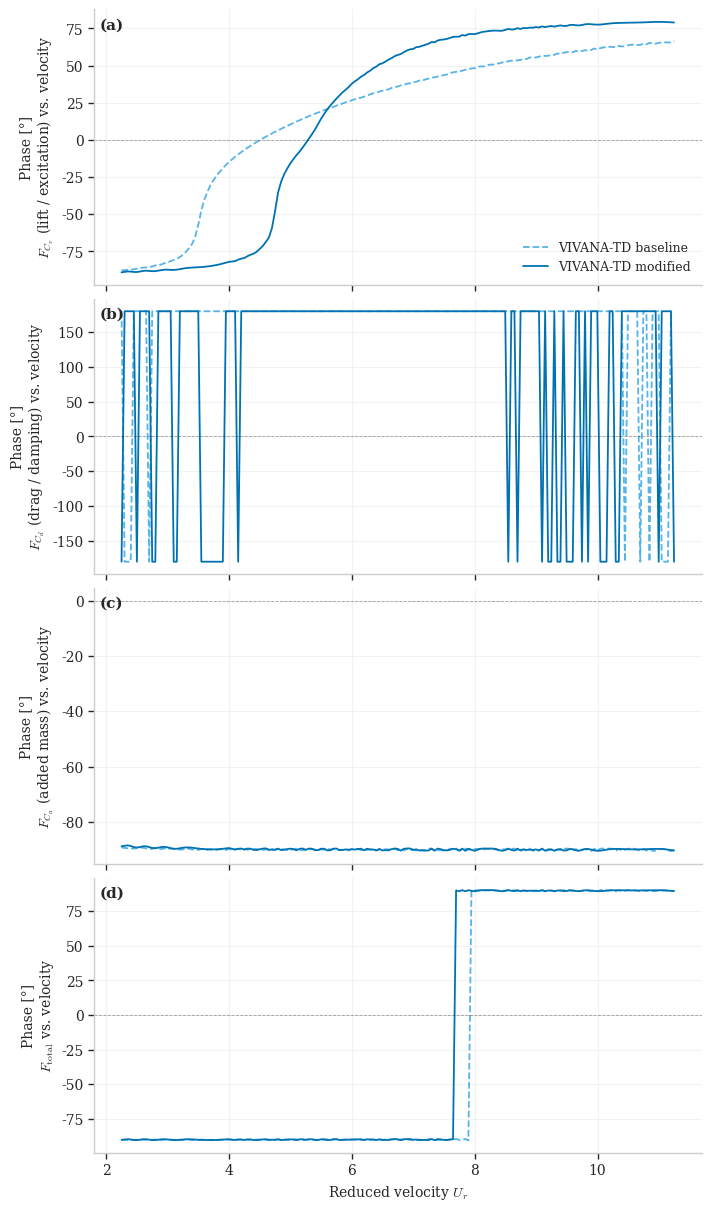

In [30]:
# Block 7 (phase): Phase of individual VIVANA-TD force terms and total force vs structural velocity.
# Reconstructs the three hydrodynamic force components (lift Fcv, drag Fdy, added-mass Fca)
# plus the total force from saved rollout kinematics and computes their instantaneous phase relative to
# structural velocity for each VIVANA-TD sweep spec.  No CFD data is used.

# Re-derive Cd, Ca, Cv for each sweep (resolve_td_params_for_dt only changes n_memory,
# so the force-coefficient values are identical to what block 7 used internally).
_b7ph_sweep_params = []
for _s in VIVANA_TD_SWEEP_SPECS:
    _cfg = dict(TD_PARAM_OVERRIDES)
    _cfg.update(td_sweep_overrides(dict(_s)))
    _b7ph_sweep_params.append(resolve_td_params(_cfg))


def _circular_mean_deg(values):
    """Circular mean of a list of phase angles in degrees."""
    angles = np.deg2rad(np.asarray(values, dtype=float))
    return float(np.degrees(np.angle(np.mean(np.exp(1j * angles)))))


# phase_groups[run_idx][term_idx]  ->  {ur: [instantaneous phase samples in degrees]}
# term order: 0 = Fcv (lift), 1 = Fdy (drag), 2 = Fca (added mass), 3 = Ftotal
_b7ph_groups = [[dict() for _ in range(4)] for _ in viv_runs]

for _ri, _run in enumerate(viv_runs):
    _Cd = float(_b7ph_sweep_params[_ri]['Cd'])
    _Ca = float(_b7ph_sweep_params[_ri]['Ca'])

    for _gc in _run['generated_cases']:
        _ur   = float(_gc['ur'])
        _ro   = _gc['rollout']
        _tmpl = _gc['template_series']

        _t   = np.asarray(_ro['time'],        dtype=float)
        _y   = np.asarray(_ro['displacement'], dtype=float)
        _v   = np.asarray(_ro['velocity'],     dtype=float)
        _f   = np.asarray(_ro['force'],        dtype=float)
        _U   = np.asarray(_ro['flow_speed'],   dtype=float)
        _rho = float(_ro['rho'])
        _D   = float(_ro['diameter'])
        _k   = float(_ro['stiffness'])
        _m   = float(_ro['reference_mass'])
        _c   = float(_tmpl.get('damping', 0.0))

        _spd = np.sqrt(_U**2 + _v**2)
        _a   = (_f - _c * _v - _k * _y) / _m             # structural acceleration from EOM
        _fdy = -0.5  * _rho * _D * _Cd * _spd * _v       # drag
        _fca = -0.25 * _rho * _Ca * np.pi * _D**2 * _a   # added mass
        _fcv = _f - _fca - _fdy                            # lift (residual)

        _freq = dominant_frequency_from_signal(_t, _v)
        if not (np.isfinite(_freq) and _freq > 0.0):
            _freq = dominant_frequency_from_signal(_t, _y)
        if not (np.isfinite(_freq) and _freq > 0.0):
            continue

        for _ti, _ft in enumerate([_fcv, _fdy, _fca, _f]):
            _ph = instantaneous_phase_lag_deg_samples(_t, _v, _ft, _freq)
            if _ph.size > 0:
                _b7ph_groups[_ri][_ti].setdefault(_ur, []).extend(_ph.tolist())

_B7PH_TERM_LABELS = [
    r'$F_{C_v}$ (lift / excitation)',
    r'$F_{C_d}$ (drag / damping)',
    r'$F_{C_a}$ (added mass)',
    r'$F_{\mathrm{total}}$',
]
_B7PH_PANELS = ['(a)', '(b)', '(c)', '(d)']
_B7PH_FIGURE_PATH = REPO_ROOT / 'figures' / 'spectral_block_7_force_term_phases.png'
_B7PH_DPI = 600

fig_ph, axes_ph = plt.subplots(4, 1, figsize=(7, 12), sharex=True, constrained_layout=True)

for _ti, (_ax, _lbl, _panel) in enumerate(zip(axes_ph, _B7PH_TERM_LABELS, _B7PH_PANELS)):
    _ax.text(0.01, 0.97, _panel, transform=_ax.transAxes,
             va='top', ha='left', fontsize=11, fontweight='bold')

    for _ri, _run in enumerate(viv_runs):
        _grp = _b7ph_groups[_ri][_ti]
        if not _grp:
            continue
        _urs   = np.asarray(sorted(_grp.keys()), dtype=float)
        _means = np.asarray([_circular_mean_deg(_grp[_u]) for _u in _urs], dtype=float)
        _fin   = np.isfinite(_means)
        _ax.plot(
            _urs[_fin], _means[_fin],
            color=_run.get('color') or '#1f77b4',
            linestyle=_run.get('linestyle', '-'),
            linewidth=float(_run.get('linewidth', 1.8)),
            label=_run['label'],
        )

    _ax.set_ylabel(f'Phase [°]\n{_lbl} vs. velocity')
    _ax.axhline(0, color='k', linewidth=0.6, alpha=0.35, linestyle='--')
    _ax.grid(True, alpha=0.25)
    _ax.spines['top'].set_visible(False)
    _ax.spines['right'].set_visible(False)
    _ax.tick_params(direction='out', length=4, width=1)
    if _ti == 0:
        _ax.legend(frameon=False, fontsize=9, loc='best')

axes_ph[-1].set_xlabel('Reduced velocity $U_r$')

_B7PH_FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
fig_ph.savefig(_B7PH_FIGURE_PATH, dpi=_B7PH_DPI, bbox_inches='tight')
print(f"Saved: {_B7PH_FIGURE_PATH}")
plt.show()
plt.close(fig_ph)

Block 8 comparing against 14 CFD reference run(s).
Block 8 CFD effective U_r keys: [2.246552, 4.493104, 5.616439, 6.458662, 7.862351, 8.987725, 11.229915]
Block 8 sweep 1/2: VIVANA-TD baseline -> {'Cv': 1.2, 'Cd': 1.1, 'Ca': 1.0, 'fhat0': 0.18, 'fhat_min': 0.11, 'fhat_max': 0.26, 'n_memory': 500.0}


Block 8: VIVANA-TD baseline: 100%|██████████| 14/14 [00:03<00:00,  4.47it/s]


Block 8 sweep 2/2: VIVANA-TD modified -> {'Cv': 1.03, 'Cd': 1.02, 'Ca': 1.95, 'fhat0': 0.142, 'fhat_min': 0.142, 'fhat_max': 0.173, 'n_memory': 500.0}


Block 8: VIVANA-TD modified: 100%|██████████| 14/14 [00:03<00:00,  4.59it/s]


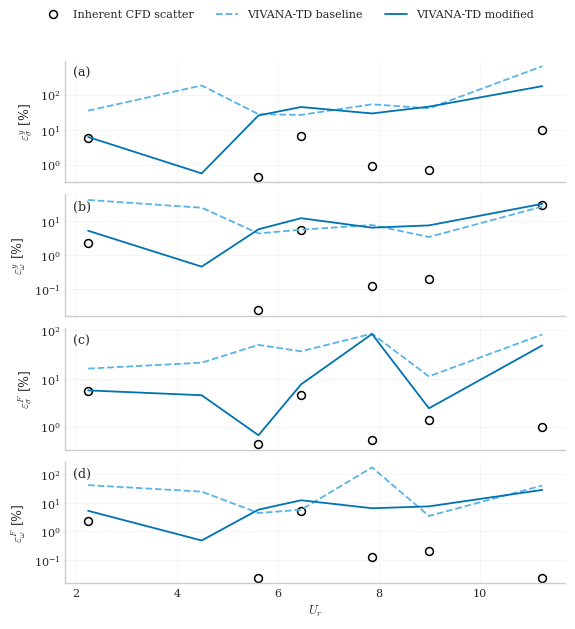

Block 8 validation summary table (includes inherent CFD scatter, metric rows plus aggregate validation error, aggregated from the mean error at each effective reduced velocity):


,Sweep,Metric,Effective U_r count,Case count,Mean error over effective U_r,Max error over effective U_r,Worst effective U_r
0,Inherent CFD scatter,$\varepsilon^y_{\sigma}$,6,13,0.040371,0.099378,11.229915
1,Inherent CFD scatter,$\varepsilon^y_{\omega}$,6,13,0.063897,0.303709,11.229915
2,Inherent CFD scatter,$\varepsilon^F_{\omega}$,6,13,0.013146,0.053122,6.458662
3,Inherent CFD scatter,$\varepsilon^F_{\sigma}$,6,13,0.022383,0.055780,2.246552
4,Inherent CFD scatter,Aggregate validation error,6,52,0.034949,0.103249,11.229915
5,VIVANA-TD baseline,$\varepsilon^y_{\sigma}$,7,14,1.472246,6.604301,11.229915
6,VIVANA-TD baseline,$\varepsilon^y_{\omega}$,7,14,0.163731,0.419551,2.246552
7,VIVANA-TD baseline,$\varepsilon^F_{\omega}$,7,14,0.425071,1.766270,7.862351
8,VIVANA-TD baseline,$\varepsilon^F_{\sigma}$,7,14,0.433997,0.856758,7.862351
9,VIVANA-TD baseline,Aggregate validation error,7,56,0.623761,2.025791,11.229915


In [31]:
# Block 8: compute final-validation-style rollout errors versus reduced velocity for the configured Vivana-TD sweeps.
# Final validation-style errors vs reduced velocity for the Vivana-TD sweeps from block 7.
FORCE_MAPPING_NRMSE_KEY = spectral_helpers.FORCE_MAPPING_NRMSE_KEY
DISP_STD_REL_ERROR_KEY = spectral_helpers.DISP_STD_REL_ERROR_KEY
DOMINANT_FREQ_REL_ERROR_KEY = spectral_helpers.DOMINANT_FREQ_REL_ERROR_KEY
FORCE_DOMINANT_FREQ_REL_ERROR_KEY = spectral_helpers.FORCE_DOMINANT_FREQ_REL_ERROR_KEY
FORCE_STD_REL_ERROR_KEY = spectral_helpers.FORCE_STD_REL_ERROR_KEY
VALIDATION_ERROR_KEYS = spectral_helpers.VALIDATION_ERROR_KEYS
ACTIVE_VALIDATION_ERROR_KEYS = [
    (metric_key, metric_label)
    for metric_key, metric_label in VALIDATION_ERROR_KEYS
    if metric_key != FORCE_MAPPING_NRMSE_KEY
]
VALIDATION_ERROR_SYMBOLS = {
    DISP_STD_REL_ERROR_KEY: r'$\varepsilon^y_{\sigma}$',
    DOMINANT_FREQ_REL_ERROR_KEY: r'$\varepsilon^y_{\omega}$',
    FORCE_STD_REL_ERROR_KEY: r'$\varepsilon^F_{\sigma}$',
    FORCE_DOMINANT_FREQ_REL_ERROR_KEY: r'$\varepsilon^F_{\omega}$',
}
compute_validation_style_error_metrics = spectral_helpers.compute_validation_style_error_metrics
dominant_frequency, relative_error = spectral_helpers._get_hnn_metric_helpers()
plot_validation_error_band = spectral_helpers.plot_validation_error_band
plot_validation_error_band_grid = spectral_helpers.plot_validation_error_band_grid
series_force_coefficient = spectral_helpers.series_force_coefficient

def _percent_grouped_errors(grouped_errors):
    return {
        float(ur): [100.0 * float(value) for value in values if np.isfinite(float(value))]
        for ur, values in dict(grouped_errors).items()
    }


def build_validation_error_plot_specs(runs, metric_label):
    specs = []
    for run in runs:
        grouped_errors = _percent_grouped_errors(run['errors_by_metric'].get(metric_label, {}))
        if not grouped_errors:
            continue
        label = str(run['label'])
        plot_spec = {
            'grouped': grouped_errors,
            'label': label,
        }
        for style_key in ('color', 'linestyle', 'linewidth', 'alpha', 'size', 'marker'):
            style_value = run.get(style_key)
            if style_value is not None:
                plot_spec[style_key] = style_value
        label_lower = label.lower()
        if label_lower.startswith('inherent cfd scatter'):
            plot_spec.update({
                'label': 'Inherent CFD scatter',
                'color': 'black',
                'linestyle': 'none',
                'linewidth': 0.0,
                'marker': 'o',
                'markerfacecolor': 'none',
                'markeredgecolor': 'black',
                'markeredgewidth': 1.1,
                'size': 32.0,
                'alpha': 1.0,
                'plot_band': False,
                'plot_mean': True,
                'show_points': False,
            })
        elif 'baseline' in label_lower:
            plot_spec.update({'color': '#56B4E9', 'linestyle': '--', 'linewidth': 1.3, 'marker': None, 'plot_band': False, 'plot_mean': True, 'show_points': False})
        elif 'modified' in label_lower:
            plot_spec.update({'color': '#0072B2', 'linestyle': '-', 'linewidth': 1.3, 'marker': None, 'plot_band': False, 'plot_mean': True, 'show_points': False})
        specs.append(plot_spec)
    return specs

def cfd_validation_characteristics(series):
    time_arr = np.asarray(series['time'], dtype=float).reshape(-1)
    displacement_arr = np.asarray(series['displacement'], dtype=float).reshape(-1)
    force_coeff_arr = series_force_coefficient(series, series['force_per_m'])
    dt = float(np.median(np.diff(time_arr))) if time_arr.size >= 2 else float('nan')
    characteristics = {
        DISP_STD_REL_ERROR_KEY: float(np.std(displacement_arr)),
        FORCE_STD_REL_ERROR_KEY: float(np.std(force_coeff_arr)),
        DOMINANT_FREQ_REL_ERROR_KEY: float('nan'),
        FORCE_DOMINANT_FREQ_REL_ERROR_KEY: float('nan'),
    }
    if np.isfinite(dt) and dt > 0.0 and displacement_arr.size > 1:
        characteristics[DOMINANT_FREQ_REL_ERROR_KEY] = float(dominant_frequency(displacement_arr, dt))
    if np.isfinite(dt) and dt > 0.0 and force_coeff_arr.size > 1:
        characteristics[FORCE_DOMINANT_FREQ_REL_ERROR_KEY] = float(dominant_frequency(force_coeff_arr, dt))
    return characteristics

def build_inherent_dataset_error_run(series_list):
    values_by_ur = {}
    for series in series_list:
        ur_key = float(round(reference_ur_value(series), 6))
        grouped = values_by_ur.setdefault(ur_key, {label: [] for _, label in ACTIVE_VALIDATION_ERROR_KEYS})
        characteristics = cfd_validation_characteristics(series)
        for _, metric_label in ACTIVE_VALIDATION_ERROR_KEYS:
            value = float(characteristics.get(metric_label, float('nan')))
            if np.isfinite(value):
                grouped[metric_label].append(value)

    errors_by_metric = {label: {} for _, label in ACTIVE_VALIDATION_ERROR_KEYS}
    for ur_key, metrics_by_name in values_by_ur.items():
        for _, metric_label in ACTIVE_VALIDATION_ERROR_KEYS:
            values = np.asarray(metrics_by_name.get(metric_label, []), dtype=float).reshape(-1)
            values = values[np.isfinite(values)]
            if values.size < 2:
                continue
            group_mean = float(np.mean(values))
            for value in values:
                error = abs(float(relative_error(float(value), group_mean)))
                if np.isfinite(error):
                    errors_by_metric[metric_label].setdefault(float(ur_key), []).append(error)
    return {
        'label': 'Inherent CFD scatter',
        'errors_by_metric': errors_by_metric,
    }

def build_validation_error_summary_rows(runs):
    rows = []
    for run in runs:
        metric_ur_mean_errors = {}
        aggregate_case_count = 0
        for _, metric_label in ACTIVE_VALIDATION_ERROR_KEYS:
            grouped_errors = run['errors_by_metric'].get(metric_label, {})
            if not grouped_errors:
                continue
            ur_keys = []
            ur_mean_errors = []
            case_count = 0
            for ur_key in sorted(grouped_errors.keys()):
                values = np.asarray(grouped_errors[float(ur_key)], dtype=float).reshape(-1)
                values = values[np.isfinite(values)]
                if values.size == 0:
                    continue
                ur_keys.append(float(ur_key))
                ur_mean_errors.append(float(np.mean(values)))
                case_count += int(values.size)
                aggregate_case_count += int(values.size)
            if not ur_mean_errors:
                continue
            metric_ur_mean_errors[metric_label] = dict(zip(ur_keys, ur_mean_errors))
            ur_mean_errors_arr = np.asarray(ur_mean_errors, dtype=float)
            max_idx = int(np.argmax(ur_mean_errors_arr))
            rows.append(
                {
                    'Sweep': str(run['label']),
                    'Metric': str(VALIDATION_ERROR_SYMBOLS.get(metric_label, metric_label)),
                    'Effective U_r count': int(len(ur_keys)),
                    'Case count': int(case_count),
                    'Mean error over effective U_r': float(np.mean(ur_mean_errors_arr)),
                    'Max error over effective U_r': float(np.max(ur_mean_errors_arr)),
                    'Worst effective U_r': float(ur_keys[max_idx]),
                }
            )
        aggregate_ur_keys = sorted(
            {
                ur_key
                for per_metric_errors in metric_ur_mean_errors.values()
                for ur_key in per_metric_errors.keys()
            }
        )
        aggregate_ur_mean_errors = []
        aggregate_valid_ur_keys = []
        for ur_key in aggregate_ur_keys:
            values = [
                per_metric_errors[ur_key]
                for per_metric_errors in metric_ur_mean_errors.values()
                if ur_key in per_metric_errors
            ]
            if not values:
                continue
            aggregate_valid_ur_keys.append(float(ur_key))
            aggregate_ur_mean_errors.append(float(np.mean(values)))
        if aggregate_ur_mean_errors:
            aggregate_errors_arr = np.asarray(aggregate_ur_mean_errors, dtype=float)
            aggregate_max_idx = int(np.argmax(aggregate_errors_arr))
            rows.append(
                {
                    'Sweep': str(run['label']),
                    'Metric': 'Aggregate validation error',
                    'Effective U_r count': int(len(aggregate_valid_ur_keys)),
                    'Case count': int(aggregate_case_count),
                    'Mean error over effective U_r': float(np.mean(aggregate_errors_arr)),
                    'Max error over effective U_r': float(np.max(aggregate_errors_arr)),
                    'Worst effective U_r': float(aggregate_valid_ur_keys[aggregate_max_idx]),
                }
            )
    return rows

def display_validation_error_summary_table(runs):
    rows = build_validation_error_summary_rows(runs)
    if not rows:
        print('No finite validation-error summary rows available.')
        return None
    print('Block 8 validation summary table (includes inherent CFD scatter, metric rows plus aggregate validation error, aggregated from the mean error at each effective reduced velocity):')
    try:
        import pandas as pd
        from IPython.display import display
        df = pd.DataFrame(rows)
        display(df)
        return df
    except Exception:
        headers = list(rows[0].keys())
        formatters = {
            'Mean error over effective U_r': lambda value: f'{float(value):.6g}',
            'Max error over effective U_r': lambda value: f'{float(value):.6g}',
            'Worst effective U_r': lambda value: f'{float(value):.6g}',
        }
        widths = {}
        for header in headers:
            rendered = [formatters.get(header, str)(row[header]) for row in rows]
            widths[header] = max(len(header), *(len(text) for text in rendered))
        header_line = ' | '.join(header.ljust(widths[header]) for header in headers)
        separator_line = '-+-'.join('-' * widths[header] for header in headers)
        print(header_line)
        print(separator_line)
        for row in rows:
            print(' | '.join(formatters.get(header, str)(row[header]).ljust(widths[header]) for header in headers))
        return rows

def align_reference_series_to_rollout(reference_series, rollout):
    reference_time = np.asarray(reference_series['time'], dtype=float).reshape(-1)
    rollout_time = np.asarray(rollout['time'], dtype=float).reshape(-1)
    if reference_time.size < 4 or rollout_time.size < 4:
        return None
    # CFD exports can keep their original absolute time offset, while the
    # generated rollout is trimmed back to start at t=0. Align both series on
    # a shared zeroed time axis before interpolation so each U_r case uses the
    # varying CFD signal instead of a flat extrapolated endpoint.
    reference_time_zeroed = reference_time - float(reference_time[0])
    rollout_time_zeroed = rollout_time - float(rollout_time[0])
    overlap_end = min(float(reference_time_zeroed[-1]), float(rollout_time_zeroed[-1]))
    if not np.isfinite(overlap_end) or overlap_end <= 0.0:
        return None
    rollout_mask = rollout_time_zeroed <= overlap_end
    if np.count_nonzero(rollout_mask) < 4:
        return None
    aligned_time = rollout_time_zeroed[rollout_mask]
    reference_force_coeff = series_force_coefficient(reference_series, reference_series['force_per_m'])
    rollout_force_coeff = series_force_coefficient(rollout, rollout['force'])
    return {
        'time': aligned_time,
        'y_true': np.interp(aligned_time, reference_time_zeroed, np.asarray(reference_series['displacement'], dtype=float).reshape(-1)),
        'y_pred': np.asarray(rollout['displacement'], dtype=float).reshape(-1)[rollout_mask],
        'force_true': np.interp(aligned_time, reference_time_zeroed, reference_force_coeff),
        'force_pred': rollout_force_coeff[rollout_mask],
    }

def reference_ur_value(series):
    ur_effective = float(series.get('ur_effective', float('nan')))
    if np.isfinite(ur_effective):
        return ur_effective
    ur_value = float(series.get('ur', float('nan')))
    if np.isfinite(ur_value):
        return ur_value
    return float('nan')

if 'TD_SWEEP_KEY_MAP' not in globals():
    TD_SWEEP_KEY_MAP = {
        'cv': 'td_cv',
        'cd': 'td_cd',
        'ca': 'td_ca',
        'f0': 'td_fhat0',
        'fmin': 'td_fhat_min',
        'fmax': 'td_fhat_max',
    }
if 'td_sweep_overrides' not in globals():
    def td_sweep_overrides(spec):
        overrides = {}
        for short_key, td_key in TD_SWEEP_KEY_MAP.items():
            value = spec.get(short_key)
            if value is not None:
                overrides[td_key] = float(value)
        return overrides
if 'td_sweep_label' not in globals():
    def td_sweep_label(spec, idx):
        explicit_label = spec.get('label')
        if explicit_label:
            return str(explicit_label)
        parts = []
        for key in ('fmin', 'f0', 'fmax', 'ca', 'cv', 'cd'):
            value = spec.get(key)
            if value is not None:
                parts.append(f"{key}={float(value):.3g}")
        if parts:
            return 'Vivana-TD (' + ', '.join(parts) + ')'
        return f'Vivana-TD case {idx + 1}'
if 'global_generation_grid' not in globals():
    global_generation_grid = spectral_helpers.global_generation_grid
if 'generate_vivana_summary_rollout' not in globals():
    generate_vivana_summary_rollout = spectral_helpers.generate_vivana_summary_rollout
if 'VIVANA_SUMMARY_MASS_SOURCE' not in globals():
    VIVANA_SUMMARY_MASS_SOURCE = 'dry'
if 'VIVANA_TRANSIENT_SECONDS' not in globals():
    VIVANA_TRANSIENT_SECONDS = 100.0
if 'VIVANA_FIRST_CASE_EXTRA_SECONDS' not in globals():
    VIVANA_FIRST_CASE_EXTRA_SECONDS = 300.0
if 'VIVANA_CONTINUATION_TRANSIENT_SECONDS' not in globals():
    VIVANA_CONTINUATION_TRANSIENT_SECONDS = 100.0
if 'VIVANA_CONTINUATION_KEPT_SECONDS' not in globals():
    VIVANA_CONTINUATION_KEPT_SECONDS = 200.0
if 'VIVANA_TD_MEMORY_TAU_SECONDS' not in globals():
    VIVANA_TD_MEMORY_TAU_SECONDS = 'tau_over_tref:4'
if 'VIVANA_TD_SWEEP_SPECS' not in globals():
    VIVANA_TD_SWEEP_SPECS = [
        {
            'label': 'Vivana-TD baseline',
            'color': '#56B4E9',
            'linestyle': '--',
            'linewidth': 1.3,
            'fmax': 0.26,
            'f0': 0.18,
            'fmin': 0.11,
            'cv': 1.2,
            'cd': 1.1,
            'ca': 1.0,
        },
    ]

cfd_reference_series = [load_series(path) for path in iter_all_npz_files(DATASET_ROOT)]
cfd_reference_series = [series for series in cfd_reference_series if np.isfinite(reference_ur_value(series))]
if not cfd_reference_series:
    raise ValueError('No finite-U_r CFD reference runs available for block 8.')

cfd_reference_series = sorted(cfd_reference_series, key=lambda series: reference_ur_value(series))
cfd_reference_ur_keys = sorted({float(round(reference_ur_value(series), 6)) for series in cfd_reference_series})
inherent_dataset_error_run = build_inherent_dataset_error_run(cfd_reference_series)
summary_generation_dt, summary_generation_duration_s, _, _ = global_generation_grid(
    cfd_reference_series,
    transient_seconds=VIVANA_TRANSIENT_SECONDS,
)
first_case_duration_s = summary_generation_duration_s + VIVANA_FIRST_CASE_EXTRA_SECONDS
first_case_transient_s = VIVANA_TRANSIENT_SECONDS + VIVANA_FIRST_CASE_EXTRA_SECONDS
continuation_duration_s = VIVANA_CONTINUATION_TRANSIENT_SECONDS + VIVANA_CONTINUATION_KEPT_SECONDS

print(f"Block 8 comparing against {len(cfd_reference_series)} CFD reference run(s).")
print(f"Block 8 CFD effective U_r keys: {cfd_reference_ur_keys}")

sweep_error_runs = []
for sweep_idx, raw_spec in enumerate(VIVANA_TD_SWEEP_SPECS):
    sweep_spec = dict(raw_spec)
    sweep_label = td_sweep_label(sweep_spec, sweep_idx)
    sweep_override_cfg = dict(TD_PARAM_OVERRIDES)
    sweep_override_cfg.update(td_sweep_overrides(sweep_spec))
    sweep_td_params = resolve_td_params(sweep_override_cfg)
    print(f"Block 8 sweep {sweep_idx + 1}/{len(VIVANA_TD_SWEEP_SPECS)}: {sweep_label} -> {sweep_td_params}")
    errors_by_metric = {label: {} for _, label in ACTIVE_VALIDATION_ERROR_KEYS}
    viv_continuation_state = None
    for reference_idx, reference_series in enumerate(tqdm(cfd_reference_series, desc=f'Block 8: {sweep_label}')):
        target_ur = reference_ur_value(reference_series)
        ur_key = float(round(target_ur, 6))
        if reference_idx == 0:
            rollout_duration_s = first_case_duration_s
            rollout_transient_seconds = first_case_transient_s
        else:
            rollout_duration_s = continuation_duration_s
            rollout_transient_seconds = VIVANA_CONTINUATION_TRANSIENT_SECONDS
        viv_rollout = generate_vivana_summary_rollout(
            reference_series,
            target_ur,
            generation_dt=summary_generation_dt,
            generation_duration_s=rollout_duration_s,
            transient_seconds=rollout_transient_seconds,
            td_params=sweep_td_params,
            mass_source=VIVANA_SUMMARY_MASS_SOURCE,
            initial_state=viv_continuation_state,
            td_memory_tau_s=VIVANA_TD_MEMORY_TAU_SECONDS,
        )
        viv_continuation_state = dict(viv_rollout['final_state'])
        aligned = align_reference_series_to_rollout(reference_series, viv_rollout)
        if aligned is None:
            continue
        error_metrics = compute_validation_style_error_metrics(
            time=aligned['time'],
            y_true=aligned['y_true'],
            y_pred=aligned['y_pred'],
            force_true=aligned['force_true'],
            force_pred=aligned['force_pred'],
        )
        for metric_key, metric_label in ACTIVE_VALIDATION_ERROR_KEYS:
            value = float(error_metrics.get(metric_key, float('nan')))
            if np.isfinite(value):
                errors_by_metric[metric_label].setdefault(ur_key, []).append(value)

    sweep_error_runs.append(
        {
            'label': sweep_label,
            'color': sweep_spec.get('color'),
            'linestyle': sweep_spec.get('linestyle', '-'),
            'linewidth': float(sweep_spec.get('linewidth', 2.0)),
            'alpha': float(sweep_spec.get('alpha', 0.20)),
            'size': float(sweep_spec.get('size', 12.0)),
            'marker': sweep_spec.get('marker'),
            'errors_by_metric': errors_by_metric,
        }
    )

block_8_metric_plot_specs = [
    {
        'metric_label': DISP_STD_REL_ERROR_KEY,
        'ylabel': VALIDATION_ERROR_SYMBOLS[DISP_STD_REL_ERROR_KEY] + ' [%]',
        'grouped_errors': build_validation_error_plot_specs([inherent_dataset_error_run] + sweep_error_runs, DISP_STD_REL_ERROR_KEY),
        'panel_label': '(a)',
    },
    {
        'metric_label': DOMINANT_FREQ_REL_ERROR_KEY,
        'ylabel': VALIDATION_ERROR_SYMBOLS[DOMINANT_FREQ_REL_ERROR_KEY] + ' [%]',
        'grouped_errors': build_validation_error_plot_specs([inherent_dataset_error_run] + sweep_error_runs, DOMINANT_FREQ_REL_ERROR_KEY),
        'panel_label': '(b)',
    },
    {
        'metric_label': FORCE_STD_REL_ERROR_KEY,
        'ylabel': VALIDATION_ERROR_SYMBOLS[FORCE_STD_REL_ERROR_KEY] + ' [%]',
        'grouped_errors': build_validation_error_plot_specs([inherent_dataset_error_run] + sweep_error_runs, FORCE_STD_REL_ERROR_KEY),
        'panel_label': '(c)',
    },
    {
        'metric_label': FORCE_DOMINANT_FREQ_REL_ERROR_KEY,
        'ylabel': VALIDATION_ERROR_SYMBOLS[FORCE_DOMINANT_FREQ_REL_ERROR_KEY] + ' [%]',
        'grouped_errors': build_validation_error_plot_specs([inherent_dataset_error_run] + sweep_error_runs, FORCE_DOMINANT_FREQ_REL_ERROR_KEY),
        'panel_label': '(d)',
    },
]

BLOCK_8_VALIDATION_FIGURE_PATH = REPO_ROOT / 'figures' / 'spectral_block_8_validation_vs_ur.pdf'
BLOCK_8_VALIDATION_FIGURE_DPI = 300

plot_validation_error_band_grid(
    'All files',
    block_8_metric_plot_specs,
    save_path=BLOCK_8_VALIDATION_FIGURE_PATH,
    save_dpi=BLOCK_8_VALIDATION_FIGURE_DPI,
)

BLOCK_8_VALIDATION_SUMMARY = display_validation_error_summary_table([inherent_dataset_error_run] + sweep_error_runs)


In [53]:
# Block 9a: define trained-model checkpoint paths and display labels.
# Rerun this block only when model paths or labels change.
import importlib
from vivana_cfd_data_pipeline.helpers import model_rollouts as model_rollouts_module

model_rollouts_module = importlib.reload(model_rollouts_module)
run_trained_model_analysis = model_rollouts_module.run_trained_model_analysis
load_trained_model_sources = model_rollouts_module.load_trained_model_sources

MODEL_SPEC_LIBRARY = {
    'best_fhat': {
        'path': REPO_ROOT / 'models/fhat/multi_seed/best_seed.pt',
        'label': 'Frequency correction',
    },
    'best_mean': {
        'path': REPO_ROOT / 'models/mean/multi_seed/best_seed.pt',
        'label': 'Force correction',
    },
    'best_shared': {
        'path': REPO_ROOT / 'models/combined/multi_seed/best_seed.pt',
        'label': 'Combined correction',
    },
    'best_latentrnn': {
        'path': REPO_ROOT / 'models/latentrnn/best_seed.pt',
        'label': 'Standalone model',
    },
    'loo_ur8_mean': {
        'path': REPO_ROOT / 'models/mean/loo/meanFINAL_LOOur8_0512-225340_best_val.pt',
        'label': 'Force correction',
    },
    'loo_ur8_frequency': {
        'path': REPO_ROOT / 'models/fhat/loo/fhatFINAL_LOOur8_0512-075256_best_val.pt',
        'label': 'Frequency correction',
    },
    'loo_ur8_combined': {
        'path': REPO_ROOT / 'models/combined/loo/comboFINAL_LOOur8_0513-010124_best_val.pt',
        'label': 'Combined correction',
    },
    'loo_ur8_latentrnn': {
        'path': REPO_ROOT / 'models/latentrnn/loo/nomfFINAL_LOOur8_0513-212741_best_val.pt',
        'label': 'Standalone model',
    },
}


def _model_specs_from_keys(model_keys_or_specs):
    """Resolve model-library keys, spec dicts, or mixed lists into checkpoint specs."""
    if model_keys_or_specs is None:
        return []
    if isinstance(model_keys_or_specs, (str, dict)):
        model_keys_or_specs = [model_keys_or_specs]
    specs = []
    for item in model_keys_or_specs:
        if isinstance(item, str):
            if item not in MODEL_SPEC_LIBRARY:
                raise KeyError(f"Unknown model key {item!r}. Available keys: {sorted(MODEL_SPEC_LIBRARY)}")
            item = MODEL_SPEC_LIBRARY[item]
        specs.append(dict(item))
    return specs


def _load_model_sources_for_block(model_keys_or_specs, *, reuse_loaded=True, device='cpu'):
    """Load a block-specific source list, reusing already-loaded Block-9 sources by label when possible."""
    specs = _model_specs_from_keys(model_keys_or_specs)
    if not specs:
        return []
    existing_sources = list(MODEL_ANALYSIS_RESULTS.get('sources', [])) if reuse_loaded and 'MODEL_ANALYSIS_RESULTS' in globals() else []
    if existing_sources:
        selected = []
        for spec in specs:
            label = str(spec.get('label', ''))
            source = next((src for src in existing_sources if src.label == label), None)
            if source is None:
                selected = []
                break
            selected.append(source)
        if selected:
            return selected
    return load_trained_model_sources(specs, repo_root=REPO_ROOT, device=device)


Loaded trained models:
  - Force correction: /Users/kasperslagstad/Desktop/Masterproject/models/mean/multi_seed/best_seed.pt (PHNN correction)
  - Frequency correction: /Users/kasperslagstad/Desktop/Masterproject/models/fhat/multi_seed/best_seed.pt (PHNN correction)
  - Combined correction: /Users/kasperslagstad/Desktop/Masterproject/models/combined/multi_seed/best_seed.pt (PHNN correction)
  - Standalone model: /Users/kasperslagstad/Desktop/Masterproject/models/latentrnn/best_seed.pt (latent RNN force model (latent_dim=3))
Using TD memory tau override: tau='tau_over_tref:4', with n_memory=tau/dt per rollout
Validation metrics use reduced time grid: reduction_factor=20, cut_start_seconds=0


Model summary generation dt uses dataset raw dt times reduction factor: reduction_factor=20


'created' timestamp seems very low; regarding as unix timestamp           
'modified' timestamp seems very low; regarding as unix timestamp


Model summary generation grid: dt from reduction factor=20 (range 0.12-0.24), total duration=200.000 s, transient trimmed=0.0 s, kept duration=200.000 s, exact dataset U_r points=7


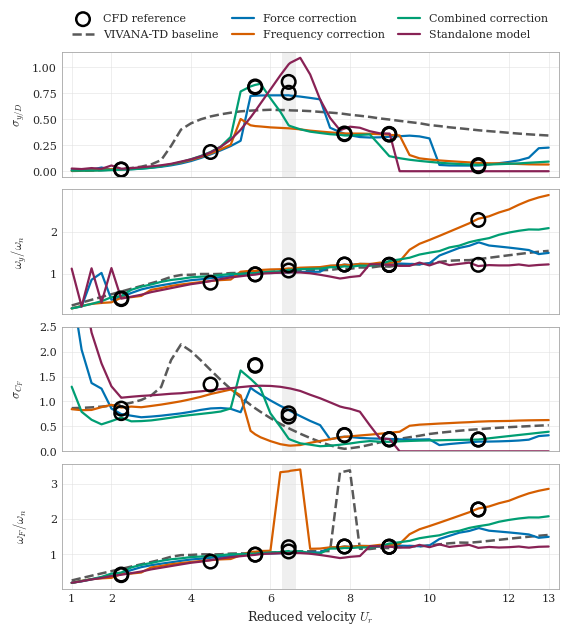

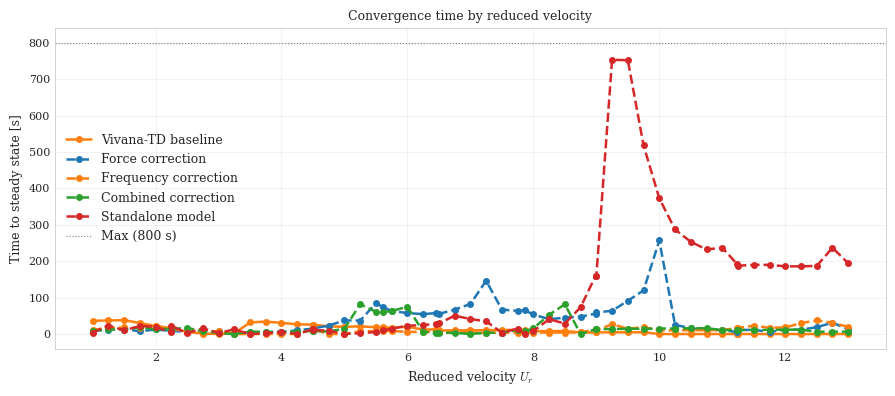

In [65]:
# Block 9b: run the trained-model rollout analysis and overlay it on the same reduced-velocity summaries.
# Trained model rollouts overlaid on the same analyses as the Vivana-TD baseline.
if 'MODEL_SPEC_LIBRARY' not in globals():
    raise NameError('Run Block 9a before Block 9b so model paths and labels are available.')

model_rollouts_module = importlib.reload(model_rollouts_module)
run_trained_model_analysis = model_rollouts_module.run_trained_model_analysis

# Select the models to include in this Block 9 sweep.
BLOCK_9_MODEL_KEYS = ['best_mean', 'best_fhat', 'best_shared', 'best_latentrnn']
#BLOCK_9_MODEL_KEYS = ['best_mean', 'best_shared']
#BLOCK_9_MODEL_KEYS = ['best_mean']

# Toggle PSD/spectral overlay figures for this trained-model comparison block.
SHOW_TRAINED_MODEL_SPECTRAL_PLOTS = False

# Toggle the VIVANA-TD baseline curve in the Block 9b PSD and summary plots.
# When shown, it is drawn as a gray dashed line.
TRAINED_MODEL_SHOW_VIVANA_TD_BASELINE = True

# Reduced-velocity spacing for the Vivana/neural-network comparison in this block.
TRAINED_MODEL_FINE_UR_STEP = 0.25

# U_r range used for the generated Vivana/model sweeps and saved generated timeseries plots.
# This can extend beyond the CFD case range.
TRAINED_MODEL_SUMMARY_UR_RANGE = (1.0, 13.0)

# --- Perturbed-start / steady-state detection ---
# When True, each U_r point starts from a small perturbation (no continuation from the previous U_r).
# The simulation runs until the amplitude is detected as steady/pseudo-steady, then the last
# TRAINED_MODEL_KEPT_SECONDS of the converged signal is used for metrics.
TRAINED_MODEL_USE_PERTURBED_START = True
# Initial displacement as a fraction of the cylinder diameter (e.g. 0.1 = 0.1 D).
TRAINED_MODEL_PERTURBATION_FRACTION = 0.1

# Steady-state check: compare std(displacement) over two consecutive windows of n_cycles periods.
# Convergence is declared when the two windows agree within amp_rel_tol (relative tolerance).
TRAINED_MODEL_STEADY_STATE_N_CYCLES = 5
TRAINED_MODEL_STEADY_STATE_AMP_REL_TOL = 0.05

# Maximum simulation time per U_r point before giving up on convergence and using the last window.
TRAINED_MODEL_STEADY_STATE_MAX_SECONDS = 800.0

# How much of the converged signal to keep for metrics (seconds).
TRAINED_MODEL_KEPT_SECONDS = 200.0

# When True, the predicted sigma is sampled as process noise at each rollout step.
# Only has an effect for models that predict sigma (use_stochastic_process_noise=True).
TRAINED_MODEL_STOCHASTIC_ROLLOUT = False
# Trained-model TD force phase convention: 'current' matches the dt-sweep scripts; 'next' is the legacy stepwise default.
TRAINED_MODEL_FORCE_PHASE_CONVENTION = 'next'  # 'current' | 'next'
# When True, put the Vivana-TD added-mass coefficient on the LHS of the rollout integrator.
TRAINED_MODEL_USE_VIVANA_ADDED_MASS_LHS = False

# Legacy continuation-mode timing (only used when TRAINED_MODEL_USE_PERTURBED_START = False).
TRAINED_MODEL_TRANSIENT_SECONDS = 0.0
TRAINED_MODEL_FIRST_CASE_EXTRA_SECONDS = 300.0

# Optional hysteresis continuation sweeps inside Block 9.
# When enabled, every trained model is swept from low->high U_r and high->low U_r.
# In this mode, the normal model sweep curves are replaced by those two hysteresis curves per model.
# Each direction settles the endpoint, then passes the final state from each U_r to the next.
TRAINED_MODEL_RUN_HYSTERESIS = False
TRAINED_MODEL_HYSTERESIS_INCLUDE_VIVANA = False
TRAINED_MODEL_HYSTERESIS_STEP_TRANSIENT_SECONDS = TRAINED_MODEL_KEPT_SECONDS
TRAINED_MODEL_HYSTERESIS_KEPT_SECONDS = TRAINED_MODEL_KEPT_SECONDS
TRAINED_MODEL_HYSTERESIS_RANDOM_SEED = 1234

# Summary-plot dt variants for the Vivana/model U_r sweeps.
# Use the same colors with different line styles for each dt entry.
SHOW_TRAINED_MODEL_TD_FREQUENCY_GUIDES = True

TRAINED_MODEL_SUMMARY_DT_SPECS = [
    {
        'dt': 0.05,
        'label': 'dt=0.1',
        'linestyle': '--',
    },
]

# Optional: derive the generated sweep dt from each dataset anchor raw dt times a reduction factor.
# Between CFD-anchor U_r values, dt is linearly interpolated with the same template interpolation as the sweep parameters.
# When True, TRAINED_MODEL_SUMMARY_DT_SPECS is ignored for the block-9 generated sweep.
TRAINED_MODEL_SUMMARY_DT_FROM_REDUCTION_FACTOR = True

# Optional TD memory-timescale override for the final block.
# When set, both Vivana-TD and the model-internal TD baseline use n_memory = tau / dt.
# Use 'tau_over_tref:4' for tau = 4 / (fhat0 * U / D), i.e. about four reference periods.
# Set to None to keep the stored fixed n_memory instead.
TRAINED_MODEL_TD_MEMORY_TAU_SECONDS = 'tau_over_tref:4'

# Match trainer final-validation preprocessing for the block-9 validation metrics.
TRAINED_MODEL_VALIDATION_REDUCE_TIME = True
TRAINED_MODEL_VALIDATION_REDUCTION_FACTOR = 20
TRAINED_MODEL_SUMMARY_DT_REDUCTION_FACTOR = TRAINED_MODEL_VALIDATION_REDUCTION_FACTOR
TRAINED_MODEL_VALIDATION_CUT_START_SECONDS = 0.0

# Resolve Block 9's model-selection keys into checkpoint specs.
TRAINED_MODEL_SWEEP_SPECS = _model_specs_from_keys(BLOCK_9_MODEL_KEYS)



if 'VIVANA_TD_BASELINE_PARAMS' not in globals():
    VIVANA_TD_BASELINE_PARAMS = TD_PARAMS

MODEL_ANALYSIS_RESULTS = run_trained_model_analysis(
    dataset_root=CFD_DATA_DIR / "npz_exports_td_burnin_trimmed_alltimeseries",
    repo_root=REPO_ROOT,
    model_specs=TRAINED_MODEL_SWEEP_SPECS,
    td_mass_source=TD_MASS_SOURCE,
    baseline_td_params=VIVANA_TD_BASELINE_PARAMS,
    summary_mass_source=VIVANA_SUMMARY_MASS_SOURCE,
    fine_ur_step=TRAINED_MODEL_FINE_UR_STEP,
    transient_seconds=TRAINED_MODEL_TRANSIENT_SECONDS,
    figsize=FIGSIZE,
    max_files_per_split=MAX_FILES_PER_SPLIT,
    ordered_split_dirs=ORDERED_SPLIT_DIRS,
    load_sima_series_for_npz=load_sima_series_for_npz,
    summary_generation_dt_specs=TRAINED_MODEL_SUMMARY_DT_SPECS,
    summary_generation_dt_from_reduction_factor=TRAINED_MODEL_SUMMARY_DT_FROM_REDUCTION_FACTOR,
    summary_generation_dt_reduction_factor=TRAINED_MODEL_SUMMARY_DT_REDUCTION_FACTOR,
    summary_kept_duration_s=TRAINED_MODEL_KEPT_SECONDS,
    summary_ur_range=TRAINED_MODEL_SUMMARY_UR_RANGE,
    summary_first_case_extra_duration_s=TRAINED_MODEL_FIRST_CASE_EXTRA_SECONDS,
    td_memory_tau_s=TRAINED_MODEL_TD_MEMORY_TAU_SECONDS,
    summary_output_dir=REPO_ROOT / 'figs' / 'block9',
    show_td_frequency_guides=SHOW_TRAINED_MODEL_TD_FREQUENCY_GUIDES,
    show_spectral_plots=SHOW_TRAINED_MODEL_SPECTRAL_PLOTS,
    show_vivana_td_baseline=TRAINED_MODEL_SHOW_VIVANA_TD_BASELINE,
    show_validation_plots=False,
    validation_reduce_time=TRAINED_MODEL_VALIDATION_REDUCE_TIME,
    validation_reduction_factor=TRAINED_MODEL_VALIDATION_REDUCTION_FACTOR,
    validation_cut_start_seconds=TRAINED_MODEL_VALIDATION_CUT_START_SECONDS,
    use_perturbed_start=TRAINED_MODEL_USE_PERTURBED_START,
    perturbation_fraction=TRAINED_MODEL_PERTURBATION_FRACTION,
    steady_state_n_cycles=TRAINED_MODEL_STEADY_STATE_N_CYCLES,
    steady_state_amp_rel_tol=TRAINED_MODEL_STEADY_STATE_AMP_REL_TOL,
    steady_state_max_seconds=TRAINED_MODEL_STEADY_STATE_MAX_SECONDS,
    stochastic_rollout=TRAINED_MODEL_STOCHASTIC_ROLLOUT,
    force_phase_convention=TRAINED_MODEL_FORCE_PHASE_CONVENTION,
    use_vivana_added_mass_lhs=TRAINED_MODEL_USE_VIVANA_ADDED_MASS_LHS,
    summary_hysteresis=TRAINED_MODEL_RUN_HYSTERESIS,
    summary_hysteresis_include_vivana=TRAINED_MODEL_HYSTERESIS_INCLUDE_VIVANA,
    summary_hysteresis_step_transient_seconds=TRAINED_MODEL_HYSTERESIS_STEP_TRANSIENT_SECONDS,
    summary_hysteresis_kept_seconds=TRAINED_MODEL_HYSTERESIS_KEPT_SECONDS,
    summary_hysteresis_random_seed=TRAINED_MODEL_HYSTERESIS_RANDOM_SEED,
)



Block 10 rollout settings: phase='next', td_memory_tau_s='tau_over_tref:4', reduction_factor=20, use_vivana_added_mass_lhs=False


'created' timestamp seems very low; regarding as unix timestamp    
'modified' timestamp seems very low; regarding as unix timestamp


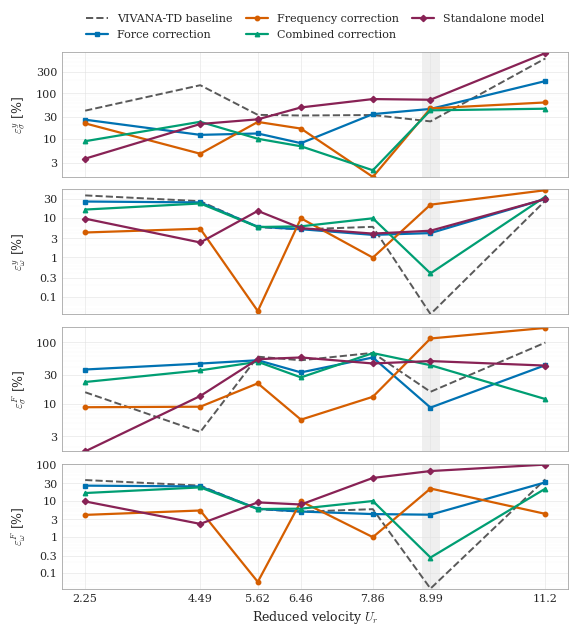

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


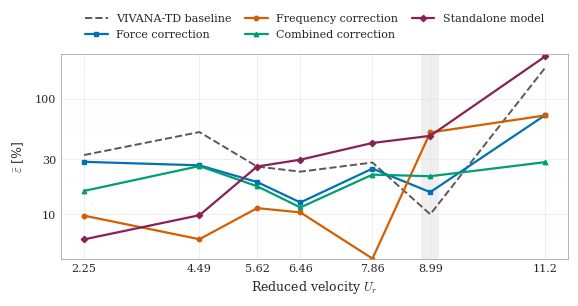

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


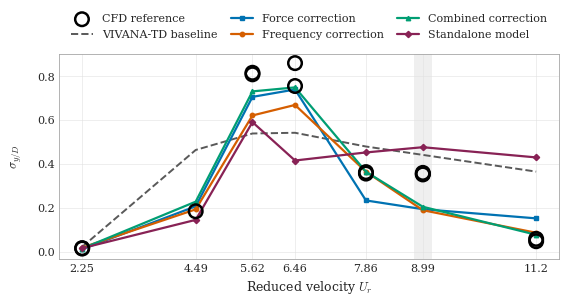

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


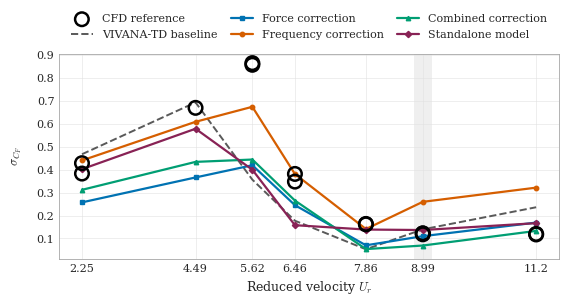

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


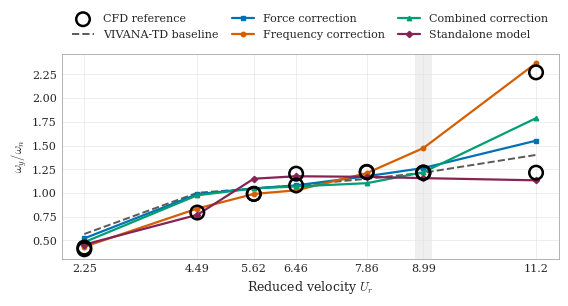

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


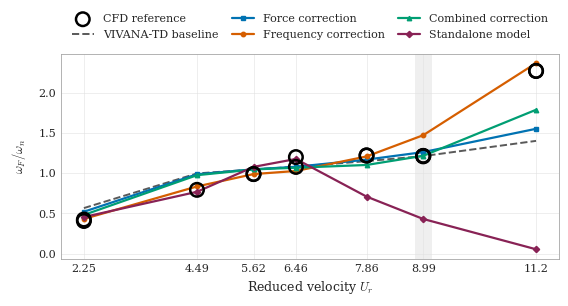

Block 10 validation summary table (four trainer-style rollout validation errors, aggregated from the mean metric value at each effective reduced velocity; aggregate = mean of the four errors; U_r-specific aggregate column filters to that raw reduced-velocity label before averaging the four errors; inherent CFD scatter compares each CFD case with the CFD mean at the same U_r, and uses the raw-U_r subset mean for the U_r-specific column):


,Method,Dominant frequency relative error,Displacement std relative error,Force dominant frequency relative error,Force std relative error,Aggregate validation error,Aggregate validation error (U_r=8 only),Effective U_r count,Case count
0,Inherent CFD scatter (U_r mean),0.063853,0.040213,0.013182,0.022528,0.034944,0.006221,6,13
1,VIVANA-TD baseline,0.152731,1.288022,0.167523,0.444612,0.513222,0.100141,7,14
2,VIVANA-TD modified,0.105402,0.513305,0.102493,0.225665,0.236716,0.152955,7,14
3,Force correction,0.141226,0.465845,0.144312,0.391201,0.285646,0.155742,7,14
4,Frequency correction,0.130526,0.254220,0.065129,0.492588,0.235616,0.511997,7,14
5,Combined correction,0.135923,0.199373,0.117260,0.364488,0.204261,0.213954,7,14
6,Standalone model,0.100737,1.450704,0.332543,0.375296,0.564820,0.478873,7,14


In [56]:
# Block 10: plot trained-model validation metrics and summary table.
model_rollouts_module = importlib.reload(model_rollouts_module)
plot_trained_model_validation_analysis = model_rollouts_module.plot_trained_model_validation_analysis
load_trained_model_sources = model_rollouts_module.load_trained_model_sources

if 'MODEL_ANALYSIS_RESULTS' not in globals():
    raise NameError('Run block 9 before block 10 so MODEL_ANALYSIS_RESULTS is available for storing results.')

# This list is intentionally independent of Block 9's model list.
# Add many checkpoints here for case-matched validation without increasing the U_r sweep cost.
TRAINED_MODEL_VALIDATION_UNSEEN_RAW_UR = 8.0
TRAINED_MODEL_VALIDATION_HELDOUT_UR = 8.99
TRAINED_MODEL_VALIDATION_DATASET_ROOT = CFD_DATA_DIR / "npz_exports_td_burnin_trimmed_alltimeseries"
if not TRAINED_MODEL_VALIDATION_DATASET_ROOT.exists():
    raise FileNotFoundError(f"Missing Block 10 validation dataset: {TRAINED_MODEL_VALIDATION_DATASET_ROOT}")

# Select the models to include in this Block 10 validation plot.
BLOCK_10_VALIDATION_MODEL_KEYS = ['loo_ur8_mean', 'loo_ur8_frequency', 'loo_ur8_combined', 'loo_ur8_latentrnn']

# Block 10 uses an explicit validation convention so stale Block-9 notebook state cannot override it.
TRAINED_MODEL_VALIDATION_FORCE_PHASE_CONVENTION = 'next'  # 'current' | 'next'
TRAINED_MODEL_VALIDATION_TD_MEMORY_TAU_SECONDS = 'tau_over_tref:4'
# When True, put the Vivana-TD added-mass coefficient on the LHS of the validation integrator.
TRAINED_MODEL_VALIDATION_USE_VIVANA_ADDED_MASS_LHS = False
print(
    'Block 10 rollout settings: '
    f'phase={TRAINED_MODEL_VALIDATION_FORCE_PHASE_CONVENTION!r}, '
    f'td_memory_tau_s={TRAINED_MODEL_VALIDATION_TD_MEMORY_TAU_SECONDS!r}, '
    f'reduction_factor={TRAINED_MODEL_VALIDATION_REDUCTION_FACTOR}, '
    f'use_vivana_added_mass_lhs={TRAINED_MODEL_VALIDATION_USE_VIVANA_ADDED_MASS_LHS}'
)

TRAINED_MODEL_VALIDATION_SPECS = _model_specs_from_keys(BLOCK_10_VALIDATION_MODEL_KEYS)

TRAINED_MODEL_VALIDATION_SOURCES = _load_model_sources_for_block(TRAINED_MODEL_VALIDATION_SPECS, reuse_loaded=False)
TRAINED_MODEL_VALIDATION_CASE_DATA = model_rollouts_module._build_case_rollouts(
    dataset_root=TRAINED_MODEL_VALIDATION_DATASET_ROOT,
    sources=TRAINED_MODEL_VALIDATION_SOURCES,
    baseline_td_params=VIVANA_TD_BASELINE_PARAMS,
    td_mass_source=TD_MASS_SOURCE,
    td_memory_tau_s=TRAINED_MODEL_VALIDATION_TD_MEMORY_TAU_SECONDS,
    max_files_per_split=MAX_FILES_PER_SPLIT,
    ordered_split_dirs=ORDERED_SPLIT_DIRS,
    load_sima_series_for_npz=None,
    include_rollouts=False,
    validation_reduce_time=TRAINED_MODEL_VALIDATION_REDUCE_TIME,
    validation_reduction_factor=TRAINED_MODEL_VALIDATION_REDUCTION_FACTOR,
    validation_cut_start_seconds=TRAINED_MODEL_VALIDATION_CUT_START_SECONDS,
    force_phase_convention=TRAINED_MODEL_VALIDATION_FORCE_PHASE_CONVENTION,
    use_vivana_added_mass_lhs=TRAINED_MODEL_VALIDATION_USE_VIVANA_ADDED_MASS_LHS,
)

_modified_overrides = dict(TD_PARAM_OVERRIDES)
_modified_overrides.update(td_sweep_overrides(VIVANA_TD_SWEEP_SPECS[1]))
VIVANA_TD_MODIFIED_PARAMS = resolve_td_params(_modified_overrides)

MODEL_ANALYSIS_RESULTS['validation_dataset_root'] = TRAINED_MODEL_VALIDATION_DATASET_ROOT
MODEL_ANALYSIS_RESULTS['validation_sources'] = TRAINED_MODEL_VALIDATION_SOURCES
MODEL_ANALYSIS_RESULTS['validation_case_data'] = TRAINED_MODEL_VALIDATION_CASE_DATA
MODEL_ANALYSIS_RESULTS['validation'] = plot_trained_model_validation_analysis(
    case_data=TRAINED_MODEL_VALIDATION_CASE_DATA,
    td_mass_source=TD_MASS_SOURCE,
    baseline_td_params=VIVANA_TD_BASELINE_PARAMS,
    sources=TRAINED_MODEL_VALIDATION_SOURCES,
    td_memory_tau_s=TRAINED_MODEL_VALIDATION_TD_MEMORY_TAU_SECONDS,
    unseen_raw_ur=TRAINED_MODEL_VALIDATION_UNSEEN_RAW_UR,
    heldout_ur=TRAINED_MODEL_VALIDATION_HELDOUT_UR,
    modified_td_params=VIVANA_TD_MODIFIED_PARAMS,
    force_phase_convention=TRAINED_MODEL_VALIDATION_FORCE_PHASE_CONVENTION,
    use_vivana_added_mass_lhs=TRAINED_MODEL_VALIDATION_USE_VIVANA_ADDED_MASS_LHS,
)



Block 12 rollout settings: phase='current', td_memory_tau_s='tau_over_tref:4', dt_reduction_factor=20, use_vivana_added_mass_lhs=False
Block 12 IC sweep: 56 generated U_r value(s) (Delta U_r=0.25, 7 CFD anchor(s)), 3 IC(s), 4 model(s).
Block 12 generated U_r values: 1, 1.25, 1.5, 1.75, 2, 2.24655, 2.25, 2.5, 2.75, 3, 3.25, 3.5, 3.75, 4, 4.25, 4.4931, 4.5, 4.75, 5, 5.25, 5.5, 5.61644, 5.75, 6, 6.25, 6.45866, 6.5, 6.75, 7, 7.25, 7.5, 7.75, 7.86235, 8, 8.25, 8.5, 8.75, 8.98772, 9, 9.25, 9.5, 9.75, 10, 10.25, 10.5, 10.75, 11, 11.2299, 11.25, 11.5, 11.75, 12, 12.25, 12.5, 12.75, 13


Block 12 ICs: 100%|██████████| 3/3 [37:05<00:00, 741.69s/IC]
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved: /Users/kasperslagstad/Desktop/Masterproject/figures/spectral_block_12_ic_sensitivity_sigma_y.pdf and /Users/kasperslagstad/Desktop/Masterproject/figures/spectral_block_12_ic_sensitivity_sigma_y.png


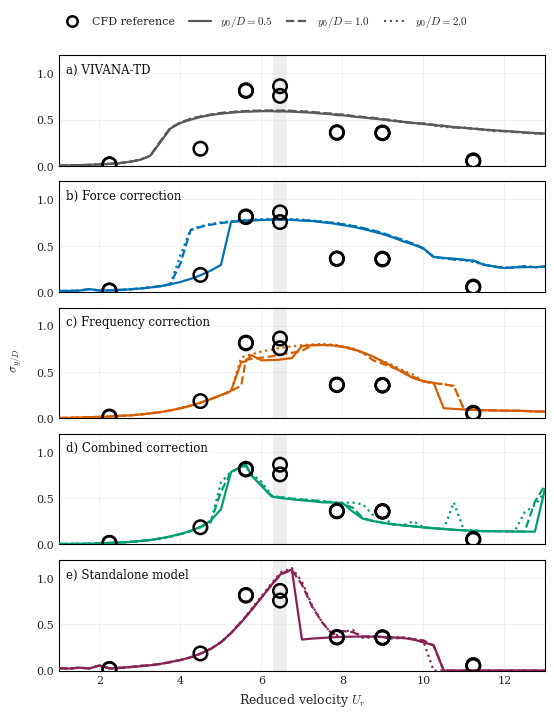

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


Saved: /Users/kasperslagstad/Desktop/Masterproject/figures/spectral_block_12_ic_convergence_periods.pdf and /Users/kasperslagstad/Desktop/Masterproject/figures/spectral_block_12_ic_convergence_periods.png


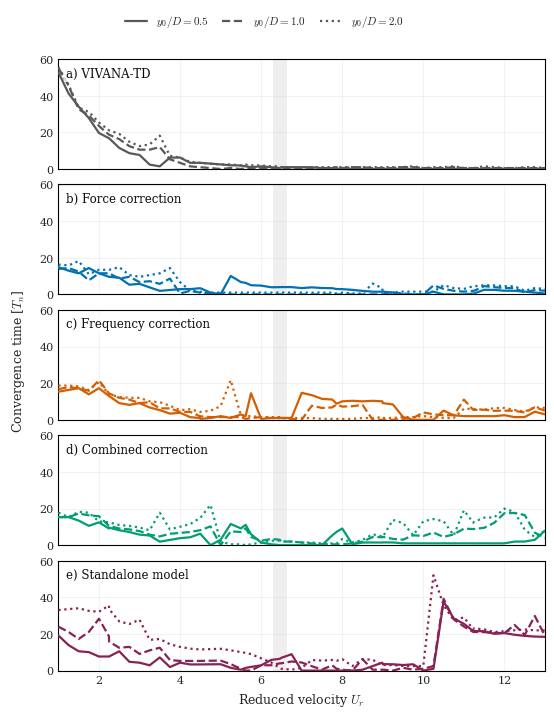

,Model,Mean convergence [$T_n$],Max convergence [$T_n$],$U_r$ at max
0,VIVANA-TD,5.856183,55.680000,1.00
1,Force correction,3.916668,18.240000,1.50
2,Frequency correction,5.899410,21.664886,5.25
3,Combined correction,6.711728,22.023068,4.75
4,Standalone model,11.512084,52.120976,10.25



% LaTeX table for thesis main text
\begin{tabular}{lrrr}
\toprule
Model & Mean convergence [$T_n$] & Max convergence [$T_n$] & $U_r$ at max \\
\midrule
VIVANA-TD & 5.86 & 55.68 & 1.00 \\
Force correction & 3.92 & 18.24 & 1.50 \\
Frequency correction & 5.90 & 21.66 & 5.25 \\
Combined correction & 6.71 & 22.02 & 4.75 \\
Standalone model & 11.51 & 52.12 & 10.25 \\
\bottomrule
\end{tabular}



,Model,Mean S,Max S,Ur at max S
0,VIVANA-TD,0.015054,0.103135,1.500000
1,Force correction,0.153584,2.855639,4.493104
2,Frequency correction,0.074536,0.934942,10.750000
3,Combined correction,0.110814,1.152646,10.750000
4,Standalone model,0.115233,1.525093,10.250000


In [66]:
# Block 12: initial-condition sensitivity analysis of VIV model rollouts.
# Runs real Vivana-TD and trained-model rollouts on the same U_r sweep-grid method as Block 9b.

from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from tqdm.auto import tqdm

if 'MODEL_SPEC_LIBRARY' not in globals():
    raise NameError('Run Block 9a before Block 12 so model paths and labels are available.')
if 'model_rollouts_module' not in globals():
    from vivana_cfd_data_pipeline.helpers import model_rollouts as model_rollouts_module

rollout_helpers = model_rollouts_module

# --- Block 12 settings ---
BLOCK_12_MODEL_KEYS = ['best_mean', 'best_fhat', 'best_shared', 'best_latentrnn']
BLOCK_12_IC_FRACTIONS = [0.5, 1.0, 2.0]
BLOCK_12_DATASET_ROOT = CFD_DATA_DIR / 'npz_exports_td_burnin_trimmed_alltimeseries'
BLOCK_12_SAVE_PATH = REPO_ROOT / 'figures' / 'spectral_block_12_ic_sensitivity_sigma_y'
BLOCK_12_CONVERGENCE_SAVE_PATH = REPO_ROOT / 'figures' / 'spectral_block_12_ic_convergence_periods'
BLOCK_12_REUSE_BLOCK9_CASE_DATA = True
# Match Block 9b's reduced-velocity sweep method: a uniform grid plus CFD anchors in range.
BLOCK_12_UR_RANGE = (1.0, 13.0)
BLOCK_12_UR_STEP = 0.25

BLOCK_12_MASS_SOURCE = globals().get('VIVANA_SUMMARY_MASS_SOURCE', 'dry')
# Block 12 uses explicit rollout settings so stale Block-9 notebook state cannot override them.
BLOCK_12_TD_MEMORY_TAU_SECONDS = 'tau_over_tref:4'
BLOCK_12_DT_REDUCTION_FACTOR = globals().get('TRAINED_MODEL_VALIDATION_REDUCTION_FACTOR', 20)
BLOCK_12_KEPT_SECONDS = globals().get('TRAINED_MODEL_KEPT_SECONDS', 200.0)
BLOCK_12_STEADY_STATE_MAX_SECONDS = globals().get('TRAINED_MODEL_STEADY_STATE_MAX_SECONDS', 800.0)
BLOCK_12_STEADY_STATE_N_CYCLES = globals().get('TRAINED_MODEL_STEADY_STATE_N_CYCLES', 5)
BLOCK_12_STEADY_STATE_AMP_REL_TOL = globals().get('TRAINED_MODEL_STEADY_STATE_AMP_REL_TOL', 0.05)
BLOCK_12_STOCHASTIC_ROLLOUT = bool(globals().get('TRAINED_MODEL_STOCHASTIC_ROLLOUT', False))
# Trained-model rollout phase convention: 'current' matches the dt-sweep scripts; 'next' is the legacy stepwise default.
BLOCK_12_FORCE_PHASE_CONVENTION = 'current'  # 'current' | 'next'
# When True, put the Vivana-TD added-mass coefficient on the LHS of the rollout integrator.
BLOCK_12_USE_VIVANA_ADDED_MASS_LHS = False
print(
    'Block 12 rollout settings: '
    f'phase={BLOCK_12_FORCE_PHASE_CONVENTION!r}, '
    f'td_memory_tau_s={BLOCK_12_TD_MEMORY_TAU_SECONDS!r}, '
    f'dt_reduction_factor={BLOCK_12_DT_REDUCTION_FACTOR}, '
    f'use_vivana_added_mass_lhs={BLOCK_12_USE_VIVANA_ADDED_MASS_LHS}'
)

FORCE_COLOR = '#1f77b4'
FREQUENCY_COLOR = '#ff7f0e'
COMBINED_COLOR = '#2ca02c'
VIVANA_COLOR = '0.35'

_IC_STYLES = [
    dict(linestyle='-'),
    dict(linestyle='--'),
    dict(linestyle=':'),
]
BLOCK_12_HELDOUT_UR = 6.46


def _block12_add_heldout_marker(ax, *, ur_value=BLOCK_12_HELDOUT_UR):
    marker_fn = getattr(rollout_helpers, '_add_section7_heldout_marker', None)
    if callable(marker_fn):
        marker_fn(ax, ur_value=float(ur_value))
    else:
        half_width = 0.175
        ax.axvspan(
            float(ur_value) - half_width,
            float(ur_value) + half_width,
            facecolor='0.4',
            alpha=0.10,
            edgecolor='none',
            zorder=0,
        )


def _block12_panel_label(ax, label, title):
    ax.text(
        0.015,
        0.93,
        f'{label} {title}',
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=8.5,
        color='0.05',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.78, pad=1.5),
        zorder=8,
    )


def _block12_regular_ur_ticks(xlo, xhi):
    xlo = float(xlo)
    xhi = float(xhi)
    if not (np.isfinite(xlo) and np.isfinite(xhi) and xhi > xlo):
        return np.asarray([], dtype=float)
    step = 2.0 if (xhi - xlo) > 6.0 else 1.0
    start = step * np.ceil(xlo / step)
    stop = step * np.floor(xhi / step)
    if stop < start:
        return np.asarray([xlo, xhi], dtype=float)
    return np.arange(start, stop + 0.5 * step, step, dtype=float)


def _block12_range_tuple():
    if BLOCK_12_UR_RANGE is None:
        return None
    lo, hi = (float(v) for v in BLOCK_12_UR_RANGE)
    if not (np.isfinite(lo) and np.isfinite(hi) and hi >= lo):
        raise ValueError('BLOCK_12_UR_RANGE must be None or a finite (min, max) tuple.')
    return lo, hi


def _block12_case_data(sources):
    if (
        BLOCK_12_REUSE_BLOCK9_CASE_DATA
        and 'MODEL_ANALYSIS_RESULTS' in globals()
        and MODEL_ANALYSIS_RESULTS.get('case_data')
    ):
        return MODEL_ANALYSIS_RESULTS['case_data']
    return rollout_helpers._build_case_rollouts(
        dataset_root=BLOCK_12_DATASET_ROOT,
        sources=list(sources),
        baseline_td_params=dict(VIVANA_TD_BASELINE_PARAMS if 'VIVANA_TD_BASELINE_PARAMS' in globals() else TD_PARAMS),
        td_mass_source=TD_MASS_SOURCE,
        td_memory_tau_s=BLOCK_12_TD_MEMORY_TAU_SECONDS,
        max_files_per_split=MAX_FILES_PER_SPLIT,
        ordered_split_dirs=ORDERED_SPLIT_DIRS,
        load_sima_series_for_npz=None,
        include_rollouts=False,
        validation_reduce_time=globals().get('TRAINED_MODEL_VALIDATION_REDUCE_TIME', False),
        validation_reduction_factor=globals().get('TRAINED_MODEL_VALIDATION_REDUCTION_FACTOR', 1),
        validation_cut_start_seconds=globals().get('TRAINED_MODEL_VALIDATION_CUT_START_SECONDS', 0.0),
        force_phase_convention=BLOCK_12_FORCE_PHASE_CONVENTION,
        use_vivana_added_mass_lhs=BLOCK_12_USE_VIVANA_ADDED_MASS_LHS,
    )


def _block12_cfd_dataframe(cfd_grouped):
    rows = []
    for ur, values in sorted(cfd_grouped['disp_std_over_D'].items()):
        for value in np.asarray(values, dtype=float).reshape(-1):
            if np.isfinite(value):
                rows.append({'Ur': float(ur), 'sigma_y_ref': float(value)})
    return pd.DataFrame(rows)


def _block12_grouped_to_df(grouped, ic_label):
    rows = []
    for ur, values in sorted(grouped['disp_std_over_D'].items()):
        vals = np.asarray(values, dtype=float).reshape(-1)
        vals = vals[np.isfinite(vals)]
        if vals.size == 0:
            continue
        rows.append(
            {
                'Ur': float(ur),
                'ic_label': str(ic_label),
                'sigma_y_conv': float(np.mean(vals)),
            }
        )
    return pd.DataFrame(rows)


def _block12_ic_label(ic_fraction):
    value = float(ic_fraction)
    text = f'{value:.2f}' if value < 0.1 else f'{value:.1f}'
    return rf'$y_0/D={text}$'


def build_block12_ic_sensitivity_data():
    specs = _model_specs_from_keys(BLOCK_12_MODEL_KEYS)
    sources = _load_model_sources_for_block(specs)
    if not sources:
        raise ValueError('Block 12 needs at least one trained model source.')

    case_data = _block12_case_data(sources)
    series_list = [entry['series'] for entry in case_data if np.isfinite(float(entry['series']['ur_effective']))]
    if not series_list:
        raise ValueError('No finite-U_r CFD cases are available for Block 12.')

    target_urs, exact_urs = rollout_helpers._summary_target_urs(
        series_list,
        fine_ur_step=float(BLOCK_12_UR_STEP),
        summary_ur_range=BLOCK_12_UR_RANGE,
    )
    block12_range = _block12_range_tuple()
    if block12_range is not None:
        ur_min, ur_max = block12_range
        target_urs = target_urs[(target_urs >= ur_min - 1.0e-9) & (target_urs <= ur_max + 1.0e-9)]
        exact_urs = exact_urs[(exact_urs >= ur_min - 1.0e-9) & (exact_urs <= ur_max + 1.0e-9)]
    baseline_params = dict(VIVANA_TD_BASELINE_PARAMS if 'VIVANA_TD_BASELINE_PARAMS' in globals() else TD_PARAMS)
    style_map = rollout_helpers._model_style_map([source.label for source in sources])

    cfd_rows = []
    for series in series_list:
        diameter = float(series['diameter'])
        if not (np.isfinite(diameter) and diameter > 0.0):
            continue
        ur_key = float(round(float(series['ur_effective']), 6))
        sigma_y_ref = float(np.std(np.asarray(series['displacement'], dtype=float).reshape(-1)) / diameter)
        if np.isfinite(sigma_y_ref):
            cfd_rows.append({'Ur': ur_key, 'sigma_y_ref': sigma_y_ref})
    cfd_df = pd.DataFrame(cfd_rows)

    model_rows = {'Vivana-TD': []}
    model_rows.update({source.label: [] for source in sources})
    convergence_by_ic = {}

    print(
        f'Block 12 IC sweep: {target_urs.size} generated U_r value(s) '
        f'(Delta U_r={float(BLOCK_12_UR_STEP):.6g}, {exact_urs.size} CFD anchor(s)), '
        f'{len(BLOCK_12_IC_FRACTIONS)} IC(s), {len(sources)} model(s).'
    )
    print('Block 12 generated U_r values: ' + ', '.join(f'{ur:.6g}' for ur in target_urs))

    def _append_rollout_row(rows, *, rollout, ur, ic_label, diameter):
        disp = np.asarray(rollout['displacement'], dtype=float).reshape(-1)
        sigma_y = float(np.std(disp) / float(diameter))
        if np.isfinite(sigma_y):
            rows.append({'Ur': float(ur), 'ic_label': str(ic_label), 'sigma_y_conv': sigma_y})

    def _trim_to_steady(rollout, generation_dt):
        # Natural period based on the same effective mass used by the rollout dynamics.
        fn_hz = math.sqrt(float(rollout['stiffness']) / float(rollout['effective_mass'])) / (2.0 * math.pi)
        period_s = 1.0 / max(fn_hz, 1.0e-6)
        onset_idx = rollout_helpers._find_steady_state_onset(
            rollout['displacement'],
            float(generation_dt),
            period_s,
            n_cycles=int(BLOCK_12_STEADY_STATE_N_CYCLES),
            amp_rel_tol=float(BLOCK_12_STEADY_STATE_AMP_REL_TOL),
        )
        trimmed = rollout_helpers._trim_rollout_to_onset(
            rollout,
            onset_idx,
            float(BLOCK_12_KEPT_SECONDS),
        )
        convergence_time_s = float(onset_idx) * float(generation_dt)
        convergence_periods = convergence_time_s / period_s if period_s > 0.0 else float('nan')
        return trimmed, float(convergence_periods)

    for ic_fraction in tqdm(BLOCK_12_IC_FRACTIONS, total=len(BLOCK_12_IC_FRACTIONS), desc='Block 12 ICs', unit='IC'):
        ic_fraction = float(ic_fraction)
        ic_label = _block12_ic_label(ic_fraction)
        convergence_by_ic[ic_label] = {'Vivana-TD baseline': {}, **{source.label: {} for source in sources}}

        for target_ur in tqdm(target_urs, total=int(target_urs.size), desc=f'Block 12 U_r {ic_label}', unit='U_r', leave=False):
            target_ur = float(target_ur)
            template = rollout_helpers._build_summary_sweep_template(series_list, target_ur)
            generation_dt = float(template['raw_dt']) * float(BLOCK_12_DT_REDUCTION_FACTOR)
            if not np.isfinite(generation_dt) or generation_dt <= 0.0:
                raise ValueError(f'Invalid Block 12 generation dt at U_r={target_ur:.6g}: {generation_dt}')
            diameter = float(template['diameter'])

            baseline_init = rollout_helpers._perturbed_initial_state(template, ic_fraction)
            baseline_rollout = rollout_helpers.generate_vivana_summary_rollout(
                template,
                target_ur,
                generation_dt=generation_dt,
                generation_duration_s=float(BLOCK_12_STEADY_STATE_MAX_SECONDS),
                transient_seconds=0.0,
                td_params=baseline_params,
                mass_source=BLOCK_12_MASS_SOURCE,
                initial_state=baseline_init,
                td_memory_tau_s=BLOCK_12_TD_MEMORY_TAU_SECONDS,
            )
            baseline_rollout, baseline_conv_periods = _trim_to_steady(baseline_rollout, generation_dt)
            convergence_by_ic[ic_label]['Vivana-TD baseline'][float(round(target_ur, 6))] = baseline_conv_periods
            _append_rollout_row(model_rows['Vivana-TD'], rollout=baseline_rollout, ur=target_ur, ic_label=ic_label, diameter=diameter)

            for source in sources:
                model_init = rollout_helpers._perturbed_initial_state(template, ic_fraction)
                if source.kind == 'latent_rnn':
                    model_init['latent'] = rollout_helpers.latent_reference_initial_state(
                        source,
                        series_list,
                        target_ur,
                        mass_source=BLOCK_12_MASS_SOURCE,
                    )
                model_rollout = rollout_helpers.generate_checkpoint_summary_rollout(
                    source,
                    template,
                    target_ur,
                    generation_dt=generation_dt,
                    generation_duration_s=float(BLOCK_12_STEADY_STATE_MAX_SECONDS),
                    transient_seconds=0.0,
                    mass_source=BLOCK_12_MASS_SOURCE,
                    initial_state=model_init,
                    td_memory_tau_s=BLOCK_12_TD_MEMORY_TAU_SECONDS,
                    stochastic=bool(BLOCK_12_STOCHASTIC_ROLLOUT),
                    force_phase_convention=BLOCK_12_FORCE_PHASE_CONVENTION,
                    use_vivana_added_mass_lhs=BLOCK_12_USE_VIVANA_ADDED_MASS_LHS,
                )
                model_rollout, model_conv_periods = _trim_to_steady(model_rollout, generation_dt)
                convergence_by_ic[ic_label][source.label][float(round(target_ur, 6))] = model_conv_periods
                _append_rollout_row(model_rows[source.label], rollout=model_rollout, ur=target_ur, ic_label=ic_label, diameter=diameter)

    models = {
        'vivana_td': {
            'label': 'VIVANA-TD',
            'color': VIVANA_COLOR,
            'data': pd.DataFrame(model_rows['Vivana-TD']),
        }
    }
    for source in sources:
        style = style_map.get(source.label, {})
        models[source.label] = {
            'label': source.label,
            'color': style.get('color', 'black'),
            'data': pd.DataFrame(model_rows[source.label]),
        }

    return {
        'models': models,
        'cfd_df': cfd_df,
        'target_urs': target_urs,
        'exact_urs': exact_urs,
        'sources': sources,
        'case_data': case_data,
        'convergence_by_ic': convergence_by_ic,
    }

def plot_ic_sensitivity_sigma_y(
    models: dict,
    cfd_df: pd.DataFrame | None = None,
    *,
    exact_urs: np.ndarray | None = None,
    target_urs: np.ndarray | None = None,
    figsize: tuple = (5.85, 7.2),
    linewidth: float = 1.6,
    markersize: float = 6.5,
    shared_ylim: tuple | None = None,
    xlim: tuple | None = None,
    save_path: str | Path | None = BLOCK_12_SAVE_PATH,
    dpi: int = 300,
) -> tuple[plt.Figure, list[plt.Axes]]:
    model_keys = list(models.keys())
    n = len(model_keys)

    fig, axes = plt.subplots(n, 1, figsize=figsize, sharex=True)
    axes = list(np.atleast_1d(axes))
    panel_labels = [f'{chr(97 + i)})' for i in range(n)]

    all_ic_labels = []
    for key in model_keys:
        df = models[key].get('data')
        if df is None or df.empty:
            continue
        for lbl in df['ic_label'].unique():
            if lbl not in all_ic_labels:
                all_ic_labels.append(lbl)
    ic_style_map = {lbl: _IC_STYLES[i % len(_IC_STYLES)] for i, lbl in enumerate(all_ic_labels)}

    if shared_ylim is None:
        all_vals = []
        for key in model_keys:
            df = models[key].get('data')
            if df is not None and not df.empty:
                all_vals.extend(df['sigma_y_conv'].dropna().tolist())
        if cfd_df is not None and not cfd_df.empty:
            all_vals.extend(cfd_df['sigma_y_ref'].dropna().tolist())
        if all_vals:
            ylo = float(np.nanmin(all_vals))
            yhi = float(np.nanmax(all_vals))
            pad = 0.08 * (yhi - ylo) if yhi > ylo else 0.05
            shared_ylim = (max(0.0, ylo - pad), yhi + pad)
        else:
            shared_ylim = (0.0, 1.0)

    ur_values = []
    for key in model_keys:
        df = models[key].get('data')
        if df is not None and not df.empty:
            ur_values.extend(df['Ur'].dropna().tolist())
    if cfd_df is not None and not cfd_df.empty:
        ur_values.extend(cfd_df['Ur'].dropna().tolist())
    if target_urs is not None and np.asarray(target_urs).size:
        ur_values.extend(np.asarray(target_urs, dtype=float).reshape(-1).tolist())

    if exact_urs is None or np.asarray(exact_urs).size == 0:
        exact_urs = np.asarray(sorted({round(float(v), 6) for v in ur_values}), dtype=float)
    else:
        exact_urs = np.asarray(exact_urs, dtype=float).reshape(-1)
    plot_urs = np.asarray(sorted({round(float(v), 6) for v in ur_values}), dtype=float)

    for ax_idx, key in enumerate(model_keys):
        ax = axes[ax_idx]
        spec = models[key]
        model_color = spec.get('color', 'black')
        model_label = spec.get('label', key)
        df = spec.get('data')
        _block12_add_heldout_marker(ax)

        if cfd_df is not None and not cfd_df.empty:
            cfd_sorted = cfd_df.sort_values('Ur')
            ax.scatter(
                cfd_sorted['Ur'].values,
                cfd_sorted['sigma_y_ref'].values,
                facecolors='none',
                edgecolors='black',
                linewidths=1.8,
                s=95,
                marker='o',
                zorder=5,
                label='CFD reference' if ax_idx == 0 else '_nolegend_',
            )

        if df is not None and not df.empty:
            for ic_lbl in all_ic_labels:
                sub = df[df['ic_label'] == ic_lbl].sort_values('Ur')
                if sub.empty:
                    continue
                ax.plot(
                    sub['Ur'].values,
                    sub['sigma_y_conv'].values,
                    color=model_color,
                    linewidth=linewidth,
                    label=ic_lbl if ax_idx == 0 else '_nolegend_',
                    zorder=3,
                    **ic_style_map[ic_lbl],
                )

        _block12_panel_label(ax, panel_labels[ax_idx], str(model_label))
        ax.set_ylim(shared_ylim)
        ax.grid(True, alpha=0.25)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
            spine.set_edgecolor('black')
        ax.tick_params(labelsize=8.0)
        if ax_idx < n - 1:
            ax.tick_params(labelbottom=False)

    if plot_urs.size:
        xlo = float(np.min(plot_urs))
        xhi = float(np.max(plot_urs))
        block12_range = _block12_range_tuple()
        if xlim is None and block12_range is not None:
            xlo, xhi = block12_range
        tick_urs = _block12_regular_ur_ticks(xlo, xhi)
        for ax in axes:
            if xlim is not None:
                ax.set_xlim(xlim)
            elif block12_range is not None:
                ax.set_xlim(xlo, xhi)
            else:
                ax.set_xlim(xlo - 0.25, xhi + 0.25)
            ax.set_xticks(tick_urs)
            ax.set_xticklabels([f'{v:.3g}' for v in tick_urs], fontsize=8.0)
    axes[-1].set_xlabel(r'Reduced velocity $U_r$', fontsize=9.0)
    fig.supylabel(r'$\sigma_{y/D}$', fontsize=9.0, x=0.065)

    handles = [
        Line2D([0], [0], color='none', marker='o', markerfacecolor='none', markeredgecolor='black', markeredgewidth=1.8, markersize=7.5, label='CFD reference')
    ]
    for ic_lbl in all_ic_labels:
        handles.append(Line2D([0], [0], color='0.35', linewidth=linewidth, label=ic_lbl, **ic_style_map[ic_lbl]))
    fig.legend(
        handles=handles,
        loc='upper center',
        bbox_to_anchor=(0.5, 0.995),
        ncol=len(handles),
        frameon=False,
        handlelength=2.0,
        fontsize=8.0,
        columnspacing=1.2,
    )

    fig.tight_layout(rect=(0.045, 0.0, 1.0, 0.94))
    fig.subplots_adjust(hspace=0.14)

    if save_path:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path.with_suffix('.pdf'), bbox_inches='tight')
        fig.savefig(save_path.with_suffix('.png'), dpi=dpi, bbox_inches='tight')
        print(f'Saved: {save_path.with_suffix(".pdf")} and {save_path.with_suffix(".png")}')

    return fig, axes



def plot_ic_convergence_time(
    models: dict,
    convergence_by_ic: dict,
    *,
    exact_urs: np.ndarray | None = None,
    target_urs: np.ndarray | None = None,
    figsize: tuple = (5.85, 7.2),
    linewidth: float = 1.6,
    shared_ylim: tuple | None = None,
    xlim: tuple | None = None,
    save_path: str | Path | None = BLOCK_12_CONVERGENCE_SAVE_PATH,
    dpi: int = 300,
) -> tuple[plt.Figure, list[plt.Axes]]:
    model_keys = list(models.keys())
    n = len(model_keys)

    fig, axes = plt.subplots(n, 1, figsize=figsize, sharex=True)
    axes = list(np.atleast_1d(axes))
    panel_labels = [f'{chr(97 + i)})' for i in range(n)]

    all_ic_labels = list(convergence_by_ic.keys())
    ic_style_map = {lbl: _IC_STYLES[i % len(_IC_STYLES)] for i, lbl in enumerate(all_ic_labels)}

    method_key_by_model_key = {
        key: ('Vivana-TD baseline' if str(spec.get('label', key)) == 'VIVANA-TD' else str(spec.get('label', key)))
        for key, spec in models.items()
    }

    rows_by_model = {key: [] for key in model_keys}
    all_vals = []
    all_ur = []
    for ic_label, by_method in convergence_by_ic.items():
        for model_key in model_keys:
            method_key = method_key_by_model_key[model_key]
            time_by_ur = by_method.get(method_key, {})
            for ur, conv_periods in sorted(time_by_ur.items()):
                ur_value = float(ur)
                conv_value = float(conv_periods)
                if not (np.isfinite(ur_value) and np.isfinite(conv_value)):
                    continue
                rows_by_model[model_key].append(
                    {'Ur': ur_value, 'ic_label': ic_label, 'convergence_periods': conv_value}
                )
                all_vals.append(conv_value)
                all_ur.append(ur_value)

    if shared_ylim is None:
        if all_vals:
            ylo = float(np.nanmin(all_vals))
            yhi = float(np.nanmax(all_vals))
            pad = 0.08 * (yhi - ylo) if yhi > ylo else max(1.0, 0.05 * yhi)
            shared_ylim = (max(0.0, ylo - pad), yhi + pad)
        else:
            shared_ylim = (0.0, 1.0)

    plot_ur_values = list(all_ur)
    if target_urs is not None and np.asarray(target_urs).size:
        plot_ur_values.extend(np.asarray(target_urs, dtype=float).reshape(-1).tolist())
    if exact_urs is None or np.asarray(exact_urs).size == 0:
        exact_urs = np.asarray(sorted({round(float(v), 6) for v in plot_ur_values}), dtype=float)
    else:
        exact_urs = np.asarray(exact_urs, dtype=float).reshape(-1)
    plot_urs = np.asarray(sorted({round(float(v), 6) for v in plot_ur_values}), dtype=float)

    for ax_idx, model_key in enumerate(model_keys):
        ax = axes[ax_idx]
        spec = models[model_key]
        model_color = spec.get('color', 'black')
        model_label = spec.get('label', model_key)
        df = pd.DataFrame(rows_by_model[model_key])
        _block12_add_heldout_marker(ax)

        if not df.empty:
            for ic_lbl in all_ic_labels:
                sub = df[df['ic_label'] == ic_lbl].sort_values('Ur')
                if sub.empty:
                    continue
                ax.plot(
                    sub['Ur'].values,
                    sub['convergence_periods'].values,
                    color=model_color,
                    linewidth=linewidth,
                    label=ic_lbl if ax_idx == 0 else '_nolegend_',
                    zorder=3,
                    **ic_style_map[ic_lbl],
                )

        _block12_panel_label(ax, panel_labels[ax_idx], str(model_label))
        ax.set_ylim(shared_ylim)
        ax.grid(True, alpha=0.25)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
            spine.set_edgecolor('black')
        ax.tick_params(labelsize=8.0)
        if ax_idx < n - 1:
            ax.tick_params(labelbottom=False)

    if plot_urs.size:
        xlo = float(np.min(plot_urs))
        xhi = float(np.max(plot_urs))
        block12_range = _block12_range_tuple()
        if xlim is None and block12_range is not None:
            xlo, xhi = block12_range
        tick_urs = _block12_regular_ur_ticks(xlo, xhi)
        for ax in axes:
            if xlim is not None:
                ax.set_xlim(xlim)
            elif block12_range is not None:
                ax.set_xlim(xlo, xhi)
            else:
                ax.set_xlim(xlo - 0.25, xhi + 0.25)
            ax.set_xticks(tick_urs)
            ax.set_xticklabels([f'{v:.3g}' for v in tick_urs], fontsize=8.0)
    axes[-1].set_xlabel(r'Reduced velocity $U_r$', fontsize=9.0)
    fig.supylabel(r'Convergence time [$T_n$]', fontsize=9.0, x=0.065)

    handles = [
        Line2D([0], [0], color='0.35', linewidth=linewidth, label=ic_lbl, **ic_style_map[ic_lbl])
        for ic_lbl in all_ic_labels
    ]
    fig.legend(
        handles=handles,
        loc='upper center',
        bbox_to_anchor=(0.5, 0.995),
        ncol=len(handles),
        frameon=False,
        handlelength=2.0,
        fontsize=8.0,
        columnspacing=1.2,
    )

    fig.tight_layout(rect=(0.045, 0.0, 1.0, 0.94))
    fig.subplots_adjust(hspace=0.14)

    if save_path:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path.with_suffix('.pdf'), bbox_inches='tight')
        fig.savefig(save_path.with_suffix('.png'), dpi=dpi, bbox_inches='tight')
        print(f'Saved: {save_path.with_suffix(".pdf")} and {save_path.with_suffix(".png")}')

    return fig, axes


def compute_ic_convergence_table(models: dict, convergence_by_ic: dict) -> pd.DataFrame:
    """Summarize convergence over all Block-12 ICs and U_r anchors in natural periods."""
    rows = []
    method_key_by_model_key = {
        key: ('Vivana-TD baseline' if str(spec.get('label', key)) == 'VIVANA-TD' else str(spec.get('label', key)))
        for key, spec in models.items()
    }
    for model_key, spec in models.items():
        method_key = method_key_by_model_key[model_key]
        records = []
        for ic_label, by_method in convergence_by_ic.items():
            for ur, value in by_method.get(method_key, {}).items():
                ur_value = float(ur)
                conv_periods = float(value)
                if np.isfinite(ur_value) and np.isfinite(conv_periods):
                    records.append((ur_value, conv_periods))
        if not records:
            rows.append(
                {
                    'Model': spec.get('label', model_key),
                    r'Mean convergence [$T_n$]': float('nan'),
                    r'Max convergence [$T_n$]': float('nan'),
                    r'$U_r$ at max': float('nan'),
                }
            )
            continue
        conv_values = np.asarray([record[1] for record in records], dtype=float)
        max_idx = int(np.argmax(conv_values))
        rows.append(
            {
                'Model': spec.get('label', model_key),
                r'Mean convergence [$T_n$]': float(np.mean(conv_values)),
                r'Max convergence [$T_n$]': float(conv_values[max_idx]),
                r'$U_r$ at max': float(records[max_idx][0]),
            }
        )

    result = pd.DataFrame(rows)
    if not result.empty:
        try:
            display(result)
        except NameError:
            print(result.to_string(index=False))
        print()
        print('% LaTeX table for thesis main text')
        print(result.to_latex(index=False, float_format=lambda value: f'{value:.2f}', escape=False))
    return result

def compute_ic_sensitivity_table(models: dict, cfd_df: pd.DataFrame | None = None) -> pd.DataFrame:
    cfd_lookup = None
    if cfd_df is not None and not cfd_df.empty:
        cfd_lookup = cfd_df.groupby('Ur')['sigma_y_ref'].mean()
    rows = []
    for key, spec in models.items():
        df = spec.get('data')
        if df is None or df.empty:
            continue
        spread = df.groupby('Ur')['sigma_y_conv'].agg(lambda s: float(np.max(s) - np.min(s))).rename('spread')
        mean_ic = df.groupby('Ur')['sigma_y_conv'].mean().rename('mean_ic')
        tab = pd.concat([spread, mean_ic], axis=1).reset_index()
        if cfd_lookup is not None:
            tab['denom'] = tab['Ur'].map(cfd_lookup)
        else:
            tab['denom'] = tab['mean_ic']
        missing = (~np.isfinite(tab['denom'])) | (tab['denom'] == 0.0)
        tab.loc[missing, 'denom'] = tab.loc[missing, 'mean_ic']
        tab['S'] = tab['spread'] / tab['denom'].replace(0.0, np.nan)
        max_idx = tab['S'].idxmax()
        rows.append(
            {
                'Model': spec.get('label', key),
                'Mean S': float(tab['S'].mean()),
                'Max S': float(tab['S'].max()),
                'Ur at max S': float(tab.loc[max_idx, 'Ur']),
            }
        )
    result = pd.DataFrame(rows)
    if not result.empty:
        try:
            display(result)
        except NameError:
            print(result.to_string(index=False))
    return result


BLOCK_12_RESULTS = build_block12_ic_sensitivity_data()
fig_ic, axes_ic = plot_ic_sensitivity_sigma_y(
    BLOCK_12_RESULTS['models'],
    BLOCK_12_RESULTS['cfd_df'],
    exact_urs=BLOCK_12_RESULTS['exact_urs'],
    target_urs=BLOCK_12_RESULTS['target_urs'],
)
plt.show()

fig_ic_conv, axes_ic_conv = plot_ic_convergence_time(
    BLOCK_12_RESULTS['models'],
    BLOCK_12_RESULTS['convergence_by_ic'],
    exact_urs=BLOCK_12_RESULTS['exact_urs'],
    target_urs=BLOCK_12_RESULTS['target_urs'],
)
plt.show()

BLOCK_12_IC_CONVERGENCE_TABLE = compute_ic_convergence_table(
    BLOCK_12_RESULTS['models'],
    BLOCK_12_RESULTS['convergence_by_ic'],
)

BLOCK_12_IC_SENSITIVITY_TABLE = compute_ic_sensitivity_table(
    BLOCK_12_RESULTS['models'],
    BLOCK_12_RESULTS['cfd_df'],
)

In [ ]:
# Block 12b: full-rollout phase portraits for Block-12 initial-condition rollouts.
# Plots the complete generated y/D versus v/(omega_n D) trajectory at one configurable reduced velocity.

import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

if 'MODEL_SPEC_LIBRARY' not in globals():
    raise NameError('Run Block 9a before Block 12b so model paths and labels are available.')
if 'BLOCK_12_IC_FRACTIONS' not in globals() or '_IC_STYLES' not in globals():
    raise NameError('Run Block 12 before Block 12b so Block-12 IC settings and styles are available.')
if 'model_rollouts_module' not in globals():
    from vivana_cfd_data_pipeline.helpers import model_rollouts as model_rollouts_module

rollout_helpers = model_rollouts_module

# --- Block 12b settings ---
BLOCK_12_PHASE_UR = 7.86
BLOCK_12_PHASE_MODEL_KEYS = ['best_mean', 'best_fhat', 'best_shared']
BLOCK_12_PHASE_SAVE_PATH = REPO_ROOT / 'figures' / 'spectral_block_12_phase_portraits'


def _block12_phase_convergence_info(rollout, generation_dt):
    fn_hz = math.sqrt(float(rollout['stiffness']) / float(rollout['effective_mass'])) / (2.0 * math.pi)
    period_s = 1.0 / max(fn_hz, 1.0e-6)
    onset_idx = rollout_helpers._find_steady_state_onset(
        rollout['displacement'],
        float(generation_dt),
        period_s,
        n_cycles=int(BLOCK_12_STEADY_STATE_N_CYCLES),
        amp_rel_tol=float(BLOCK_12_STEADY_STATE_AMP_REL_TOL),
    )
    convergence_time_s = float(onset_idx) * float(generation_dt)
    convergence_periods = convergence_time_s / period_s if period_s > 0.0 else float('nan')
    return {
        'onset_idx': int(onset_idx),
        'convergence_time_s': float(convergence_time_s),
        'convergence_periods': float(convergence_periods),
    }


def build_block12_phase_portrait_data(target_ur: float = BLOCK_12_PHASE_UR):
    specs = _model_specs_from_keys(BLOCK_12_PHASE_MODEL_KEYS)
    sources = _load_model_sources_for_block(specs)
    if not sources:
        raise ValueError('Block 12b needs at least one trained model source.')

    if 'BLOCK_12_RESULTS' in globals() and BLOCK_12_RESULTS.get('case_data'):
        case_data = BLOCK_12_RESULTS['case_data']
    else:
        case_data = _block12_case_data(sources)
    series_list = [entry['series'] for entry in case_data if np.isfinite(float(entry['series']['ur_effective']))]
    if not series_list:
        raise ValueError('No finite-U_r CFD cases are available for Block 12b.')

    target_ur = float(target_ur)
    template = rollout_helpers._build_summary_sweep_template(series_list, target_ur)
    generation_dt = float(template['raw_dt']) * float(BLOCK_12_DT_REDUCTION_FACTOR)
    if not np.isfinite(generation_dt) or generation_dt <= 0.0:
        raise ValueError(f'Invalid Block 12b generation dt at U_r={target_ur:.6g}: {generation_dt}')

    baseline_params = dict(VIVANA_TD_BASELINE_PARAMS if 'VIVANA_TD_BASELINE_PARAMS' in globals() else TD_PARAMS)
    style_map = rollout_helpers._model_style_map([source.label for source in sources])
    block12_models = BLOCK_12_RESULTS.get('models', {}) if 'BLOCK_12_RESULTS' in globals() else {}
    phase_models = {
        'vivana_td': {
            'label': 'VIVANA-TD',
            'color': block12_models.get('vivana_td', {}).get('color', VIVANA_COLOR),
            'rollouts': {},
            'convergence_periods': {},
            'convergence_info': {},
        }
    }
    for source in sources:
        style = style_map.get(source.label, {})
        phase_models[source.label] = {
            'label': source.label,
            'color': block12_models.get(source.label, {}).get('color', style.get('color', 'black')),
            'rollouts': {},
            'convergence_periods': {},
            'convergence_info': {},
        }

    print(
        f'Block 12b phase portraits: U_r={target_ur:.6g}, '
        f'{len(BLOCK_12_IC_FRACTIONS)} IC(s), {len(phase_models)} model subplot(s).'
    )

    for ic_fraction in BLOCK_12_IC_FRACTIONS:
        ic_fraction = float(ic_fraction)
        ic_label = _block12_ic_label(ic_fraction)

        baseline_init = rollout_helpers._perturbed_initial_state(template, ic_fraction)
        baseline_rollout = rollout_helpers.generate_vivana_summary_rollout(
            template,
            target_ur,
            generation_dt=generation_dt,
            generation_duration_s=float(BLOCK_12_STEADY_STATE_MAX_SECONDS),
            transient_seconds=0.0,
            td_params=baseline_params,
            mass_source=BLOCK_12_MASS_SOURCE,
            initial_state=baseline_init,
            td_memory_tau_s=BLOCK_12_TD_MEMORY_TAU_SECONDS,
        )
        baseline_conv_info = _block12_phase_convergence_info(baseline_rollout, generation_dt)
        phase_models['vivana_td']['rollouts'][ic_label] = baseline_rollout
        phase_models['vivana_td']['convergence_periods'][ic_label] = baseline_conv_info['convergence_periods']
        phase_models['vivana_td']['convergence_info'][ic_label] = baseline_conv_info

        for source in sources:
            model_init = rollout_helpers._perturbed_initial_state(template, ic_fraction)
            if source.kind == 'latent_rnn':
                model_init['latent'] = rollout_helpers.latent_reference_initial_state(
                    source,
                    series_list,
                    target_ur,
                    mass_source=BLOCK_12_MASS_SOURCE,
                )
            model_rollout = rollout_helpers.generate_checkpoint_summary_rollout(
                source,
                template,
                target_ur,
                generation_dt=generation_dt,
                generation_duration_s=float(BLOCK_12_STEADY_STATE_MAX_SECONDS),
                transient_seconds=0.0,
                mass_source=BLOCK_12_MASS_SOURCE,
                initial_state=model_init,
                td_memory_tau_s=BLOCK_12_TD_MEMORY_TAU_SECONDS,
                stochastic=bool(BLOCK_12_STOCHASTIC_ROLLOUT),
                force_phase_convention=BLOCK_12_FORCE_PHASE_CONVENTION,
            )
            model_conv_info = _block12_phase_convergence_info(model_rollout, generation_dt)
            phase_models[source.label]['rollouts'][ic_label] = model_rollout
            phase_models[source.label]['convergence_periods'][ic_label] = model_conv_info['convergence_periods']
            phase_models[source.label]['convergence_info'][ic_label] = model_conv_info

    return {
        'target_ur': target_ur,
        'generation_dt': generation_dt,
        'template': template,
        'models': phase_models,
        'sources': sources,
        'case_data': case_data,
    }


def plot_block12_phase_portraits(
    phase_results: dict,
    *,
    figsize_per_row: tuple[float, float] = (9.6, 4.4),
    linewidth: float = 1.55,
    save_path: str | Path | None = BLOCK_12_PHASE_SAVE_PATH,
    dpi: int = 300,
) -> tuple[plt.Figure, list[plt.Axes]]:
    models = phase_results['models']
    model_keys = list(models.keys())
    n_models = len(model_keys)
    ncols = 2
    nrows = int(math.ceil(n_models / ncols))
    fig, axes_arr = plt.subplots(
        nrows,
        ncols,
        figsize=(float(figsize_per_row[0]), float(figsize_per_row[1]) * nrows),
        sharex=True,
        sharey=True,
    )
    axes = list(np.atleast_1d(axes_arr).ravel())

    ic_labels = []
    for key in model_keys:
        for ic_label in models[key].get('rollouts', {}).keys():
            if ic_label not in ic_labels:
                ic_labels.append(ic_label)
    ic_style_map = {lbl: _IC_STYLES[i % len(_IC_STYLES)] for i, lbl in enumerate(ic_labels)}

    all_q = []
    all_p = []
    normalized = {}
    for key in model_keys:
        normalized[key] = {}
        for ic_label, rollout in models[key].get('rollouts', {}).items():
            diameter = float(rollout.get('diameter', phase_results['template']['diameter']))
            omega_n = math.sqrt(float(rollout['stiffness']) / float(rollout['effective_mass']))
            q = np.asarray(rollout['displacement'], dtype=float).reshape(-1) / diameter
            p = np.asarray(rollout['velocity'], dtype=float).reshape(-1) / (omega_n * diameter)
            mask = np.isfinite(q) & np.isfinite(p)
            q = q[mask]
            p = p[mask]
            normalized[key][ic_label] = (q, p)
            if q.size:
                all_q.extend(q.tolist())
                all_p.extend(p.tolist())

    if all_q and all_p:
        qlo, qhi = float(np.nanmin(all_q)), float(np.nanmax(all_q))
        plo, phi = float(np.nanmin(all_p)), float(np.nanmax(all_p))
        qpad = 0.08 * (qhi - qlo) if qhi > qlo else 0.05
        ppad = 0.08 * (phi - plo) if phi > plo else 0.05
        xlim = (qlo - qpad, qhi + qpad)
        ylim = (plo - ppad, phi + ppad)
    else:
        xlim = (-1.0, 1.0)
        ylim = (-1.0, 1.0)

    for ax_idx, key in enumerate(model_keys):
        ax = axes[ax_idx]
        spec = models[key]
        model_color = spec.get('color', 'black')
        for ic_label in ic_labels:
            q, p = normalized.get(key, {}).get(ic_label, (np.asarray([]), np.asarray([])))
            if q.size == 0:
                continue
            ax.plot(
                q,
                p,
                color=model_color,
                linewidth=linewidth,
                zorder=3,
                **ic_style_map[ic_label],
            )
            ax.plot(q[0], p[0], marker='o', color=model_color, markersize=3.2, zorder=4)
        ax.set_title(str(spec.get('label', key)), loc='left', fontsize=13.2, pad=6)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(True, alpha=0.25)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
            spine.set_edgecolor('black')
        ax.tick_params(labelsize=9.6)

    for ax in axes[n_models:]:
        ax.axis('off')

    for row in range(nrows):
        axes[row * ncols].set_ylabel(r'$v/(\omega_n D)$', fontsize=12)
    for ax in axes[max(0, (nrows - 1) * ncols): nrows * ncols]:
        if ax.axison:
            ax.set_xlabel(r'$y/D$', fontsize=12)

    handles = [
        Line2D([0], [0], color='0.35', linewidth=linewidth, label=ic_label, **ic_style_map[ic_label])
        for ic_label in ic_labels
    ]
    if handles:
        fig.legend(
            handles=handles,
            loc='upper center',
            bbox_to_anchor=(0.5, 1.0),
            ncol=len(handles),
            frameon=False,
            handlelength=2.0,
            fontsize=11,
            columnspacing=1.6,
        )
    fig.suptitle(rf'Full-rollout phase portraits at $U_r={phase_results["target_ur"]:.3g}$', y=1.04, fontsize=13.5)
    fig.tight_layout()
    fig.subplots_adjust(top=0.88 if nrows == 1 else 0.92, hspace=0.24, wspace=0.16)

    if save_path:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path.with_suffix('.pdf'), bbox_inches='tight')
        fig.savefig(save_path.with_suffix('.png'), dpi=dpi, bbox_inches='tight')
        print(f'Saved: {save_path.with_suffix(".pdf")} and {save_path.with_suffix(".png")}')

    return fig, axes[:n_models]


BLOCK_12_PHASE_RESULTS = build_block12_phase_portrait_data(BLOCK_12_PHASE_UR)
fig_phase, axes_phase = plot_block12_phase_portraits(BLOCK_12_PHASE_RESULTS)
plt.show()


In [ ]:
# Block 13: long-rollout stability diagnostics for one VIV correction model.
# Pass one model's closed-loop rollouts as:
# LONG_ROLLOUT_ROLLOUTS = {
#     2.00: {"t": t_array, "y": y_over_D_array},
#     2.25: {"t": t_array, "y": y_over_D_array},
# }
# The y signal is assumed to be y/D unless LONG_ROLLOUT_Y_SCALE is set.

import pandas as pd

if 'model_rollouts_module' not in globals():
    from vivana_cfd_data_pipeline.helpers import model_rollouts as model_rollouts_module

rollout_helpers = model_rollouts_module

# --- Block 13 settings: edit these first ---
# Select exactly one trained model for this block.
LONG_ROLLOUT_MODEL_KEY = 'best_mean'
LONG_ROLLOUT_MODEL_SPEC = _model_specs_from_keys(LONG_ROLLOUT_MODEL_KEY)[0]
LONG_ROLLOUT_MODEL_LABEL = LONG_ROLLOUT_MODEL_SPEC['label']

# Main sweep controls.
# If LONG_ROLLOUT_TARGET_OSCILLATIONS is set, each U_r rollout duration is
# chosen from the interpolated structural natural period. Set it to None to use
# LONG_ROLLOUT_TOTAL_SECONDS as a fixed wall-clock duration instead.
LONG_ROLLOUT_TARGET_OSCILLATIONS = 200.0
LONG_ROLLOUT_TOTAL_SECONDS = 1000.0
LONG_ROLLOUT_UR_RANGE = (1.0, 13.0)
LONG_ROLLOUT_UR_STEP = 0.25

# Optional non-uniform/refined sweep controls.
# Example: LONG_ROLLOUT_REFINE_RANGES = [(4.5, 7.0, 0.1)]
# If LONG_ROLLOUT_MANUAL_UR_VALUES is not None, it replaces the uniform base grid.
LONG_ROLLOUT_REFINE_RANGES = None
LONG_ROLLOUT_MANUAL_UR_VALUES = None

# Time-step and rollout settings.
# Keep LONG_ROLLOUT_GENERATION_DT=None to use each interpolated template raw dt
# multiplied by LONG_ROLLOUT_DT_REDUCTION_FACTOR.
LONG_ROLLOUT_GENERATION_DT = None
LONG_ROLLOUT_DT_FROM_REDUCTION_FACTOR = True
LONG_ROLLOUT_DT_REDUCTION_FACTOR = 20
LONG_ROLLOUT_MASS_SOURCE = globals().get("VIVANA_SUMMARY_MASS_SOURCE", "dry")
LONG_ROLLOUT_TD_MEMORY_TAU_SECONDS = globals().get("TRAINED_MODEL_TD_MEMORY_TAU_SECONDS", None)
LONG_ROLLOUT_STOCHASTIC = bool(globals().get("TRAINED_MODEL_STOCHASTIC_ROLLOUT", False))
LONG_ROLLOUT_AUTORUN = True
LONG_ROLLOUT_INCLUDE_VIVANA_TD_BASELINE = True
LONG_ROLLOUT_BASELINE_LABEL = "Vivana-TD baseline"
LONG_ROLLOUT_BASELINE_TD_PARAMS = dict(VIVANA_TD_BASELINE_PARAMS if "VIVANA_TD_BASELINE_PARAMS" in globals() else TD_PARAMS)


# Optional manual override. Leave as None for automatic model rollouts.
# Expected format: {U_r: {"t": t_array, "y": y_over_D_array}}
LONG_ROLLOUT_ROLLOUTS = None
LONG_ROLLOUT_Y_SCALE = None  # Automatic rollouts are already converted to y/D.

# Convergence-diagnostic settings.
LONG_ROLLOUT_WINDOW_LENGTH_CYCLES = 5
LONG_ROLLOUT_REFERENCE_FINAL_FRACTION = 0.20
LONG_ROLLOUT_THRESHOLD = 0.05
LONG_ROLLOUT_PERSISTENCE_CYCLES = 5
LONG_ROLLOUT_COLOR_CAP = 0.30
LONG_ROLLOUT_HEATMAP_PATH = REPO_ROOT / "figures" / "spectral_block_13_long_rollout_stability.png"
LONG_ROLLOUT_NCONV_PATH = REPO_ROOT / "figures" / "spectral_block_13_convergence_cycle_vs_ur.png"
LONG_ROLLOUT_SAVE_NCONV_PLOT = True


def make_ur_grid(ur_min=2.0, ur_max=12.0, ur_step=0.25, refine_ranges=None, ur_values=None):
    """Return a sorted reduced-velocity grid, optionally with local refinement.

    Parameters
    ----------
    ur_min, ur_max, ur_step : float
        Uniform base grid controls. The default gives Delta U_r = 0.25.
    refine_ranges : sequence, optional
        Optional local refinement ranges. Each item can be a tuple
        ``(lo, hi, step)`` or a dict with keys ``min``, ``max``, and ``step``.
    ur_values : array-like, optional
        Manual non-uniform U_r values. If supplied, the base grid is skipped and
        only these values plus any refinement ranges are returned.
    """
    grids = []
    if ur_values is None:
        ur_min = float(ur_min)
        ur_max = float(ur_max)
        ur_step = float(ur_step)
        if not np.isfinite(ur_step) or ur_step <= 0.0:
            raise ValueError("ur_step must be positive and finite.")
        grids.append(np.arange(ur_min, ur_max + 0.5 * ur_step, ur_step, dtype=float))
    else:
        grids.append(np.asarray(ur_values, dtype=float).reshape(-1))

    for refine in refine_ranges or []:
        if isinstance(refine, dict):
            lo = float(refine["min"])
            hi = float(refine["max"])
            step = float(refine["step"])
        else:
            lo, hi, step = (float(v) for v in refine)
        if not np.isfinite(step) or step <= 0.0:
            raise ValueError("Each refinement step must be positive and finite.")
        grids.append(np.arange(lo, hi + 0.5 * step, step, dtype=float))

    values = np.concatenate(grids) if grids else np.empty((0,), dtype=float)
    values = values[np.isfinite(values)]
    return np.unique(np.round(values, decimals=10))


def _finite_sorted_time_signal(t, y):
    """Return finite, time-sorted one-dimensional time and signal arrays."""
    t_arr = np.asarray(t, dtype=float).reshape(-1)
    y_arr = np.asarray(y, dtype=float).reshape(-1)
    n = min(t_arr.size, y_arr.size)
    if n < 2:
        raise ValueError("Need at least two samples.")
    t_arr = t_arr[:n]
    y_arr = y_arr[:n]
    mask = np.isfinite(t_arr) & np.isfinite(y_arr)
    t_arr = t_arr[mask]
    y_arr = y_arr[mask]
    if t_arr.size < 2:
        raise ValueError("Need at least two finite samples.")
    order = np.argsort(t_arr)
    t_arr = t_arr[order]
    y_arr = y_arr[order]
    keep = np.concatenate([[True], np.diff(t_arr) > 0.0])
    t_arr = t_arr[keep]
    y_arr = y_arr[keep]
    if t_arr.size < 2:
        raise ValueError("Need at least two strictly increasing time samples.")
    return t_arr, y_arr


def _median_positive_dt(t):
    """Estimate a representative positive sample spacing."""
    dt_values = np.diff(np.asarray(t, dtype=float).reshape(-1))
    dt_values = dt_values[np.isfinite(dt_values) & (dt_values > 0.0)]
    if dt_values.size == 0:
        raise ValueError("Time array must contain positive increments.")
    dt = float(np.median(dt_values))
    if not np.isfinite(dt) or dt <= 0.0:
        raise ValueError("Could not estimate a positive finite dt.")
    return dt


def compute_dominant_period(t, y, final_fraction=0.5):
    """Estimate the dominant oscillation period from the final signal segment.

    The displacement is mean-centered before the FFT. If the retained segment is
    mildly non-uniform in time, it is interpolated onto a uniform grid using the
    median sample spacing before the FFT is taken.
    """
    t_arr, y_arr = _finite_sorted_time_signal(t, y)
    final_fraction = float(final_fraction)
    if not (0.0 < final_fraction <= 1.0):
        raise ValueError("final_fraction must be in (0, 1].")

    start_idx = int(np.floor((1.0 - final_fraction) * t_arr.size))
    start_idx = max(0, min(start_idx, t_arr.size - 4))
    t_seg = t_arr[start_idx:]
    y_seg = y_arr[start_idx:]
    if t_seg.size < 4:
        raise ValueError("Need at least four samples to estimate dominant period.")

    dt = _median_positive_dt(t_seg)
    t_uniform = np.arange(float(t_seg[0]), float(t_seg[-1]) + 0.5 * dt, dt, dtype=float)
    if t_uniform.size < 4:
        raise ValueError("FFT segment is too short after uniform-grid construction.")
    y_uniform = np.interp(t_uniform, t_seg, y_seg)
    y_centered = y_uniform - float(np.mean(y_uniform))
    if not np.any(np.abs(y_centered) > 0.0):
        raise ValueError("Cannot estimate a dominant period from a constant signal.")

    window = signal.windows.hann(y_centered.size, sym=False) if y_centered.size >= 8 else np.ones_like(y_centered)
    spectrum = np.abs(np.fft.rfft(y_centered * window))
    freqs = np.fft.rfftfreq(y_centered.size, d=dt)
    if spectrum.size <= 1:
        raise ValueError("FFT did not produce positive-frequency bins.")
    spectrum[0] = 0.0
    peak_idx = int(np.argmax(spectrum))
    dominant_frequency_hz = float(freqs[peak_idx])
    if not np.isfinite(dominant_frequency_hz) or dominant_frequency_hz <= 0.0:
        raise ValueError("Could not find a positive dominant frequency.")
    return float(1.0 / dominant_frequency_hz)


def compute_rolling_std_convergence(
    t,
    y,
    T_osc,
    window_length_cycles=5,
    final_fraction=0.2,
    threshold=0.05,
    persistence_cycles=5,
    eps=1.0e-12,
):
    """Compute rolling displacement-std convergence for one U_r rollout.

    Returns a dict containing the cycle coordinate, rolling standard deviation,
    relative rolling-std error, reference standard deviation, and the first
    persistent convergence cycle.
    """
    t_arr, y_arr = _finite_sorted_time_signal(t, y)
    T_osc = float(T_osc)
    if not np.isfinite(T_osc) or T_osc <= 0.0:
        raise ValueError("T_osc must be positive and finite.")
    dt = _median_positive_dt(t_arr)
    t_rel = t_arr - float(t_arr[0])
    n_cycles = t_rel / T_osc

    window_samples = int(np.ceil(float(window_length_cycles) * T_osc / dt))
    window_samples = max(2, min(window_samples, y_arr.size))
    sigma_roll = (
        pd.Series(y_arr)
        .rolling(window=window_samples, min_periods=window_samples)
        .std(ddof=0)
        .to_numpy(dtype=float)
    )

    final_fraction = float(final_fraction)
    if not (0.0 < final_fraction <= 1.0):
        raise ValueError("final_fraction must be in (0, 1].")
    final_start_time = float(t_rel[-1]) * (1.0 - final_fraction)
    ref_mask = (t_rel >= final_start_time) & np.isfinite(sigma_roll)
    if not np.any(ref_mask):
        sigma_ref = float("nan")
    else:
        sigma_ref = float(np.nanmedian(sigma_roll[ref_mask]))

    e_sigma = np.abs((sigma_roll - sigma_ref) / (sigma_ref + float(eps)))
    finite_error = np.isfinite(e_sigma)
    final_e_sigma = float(e_sigma[np.flatnonzero(finite_error)[-1]]) if np.any(finite_error) else float("nan")

    persistence_samples = int(np.ceil(float(persistence_cycles) * T_osc / dt))
    persistence_samples = max(1, min(persistence_samples, e_sigma.size))
    below = finite_error & (e_sigma < float(threshold))
    n_conv = float("nan")
    converged = False
    conv_idx = None
    if below.size >= persistence_samples:
        run_lengths = np.convolve(below.astype(int), np.ones(persistence_samples, dtype=int), mode="valid")
        hit = np.flatnonzero(run_lengths >= persistence_samples)
        if hit.size:
            conv_idx = int(hit[0])
            n_conv = float(n_cycles[conv_idx])
            converged = True

    if converged and conv_idx is not None:
        after = e_sigma[conv_idx:]
        after = after[np.isfinite(after)]
        max_e_after_convergence = float(np.max(after)) if after.size else float("nan")
    else:
        max_e_after_convergence = float("nan")

    return {
        "time": t_arr,
        "y_over_D": y_arr,
        "dt": float(dt),
        "T_osc": float(T_osc),
        "n_cycles": n_cycles,
        "sigma_roll": sigma_roll,
        "sigma_ref": sigma_ref,
        "e_sigma": e_sigma,
        "n_conv": n_conv,
        "converged": bool(converged),
        "final_e_sigma": final_e_sigma,
        "max_e_after_convergence": max_e_after_convergence,
        "window_samples": int(window_samples),
        "persistence_samples": int(persistence_samples),
    }


def _first_present(mapping, keys):
    """Fetch the first available key from a rollout dictionary."""
    for key in keys:
        if key in mapping:
            return mapping[key]
    raise KeyError(f"None of these keys were found: {keys}")


def _period_from_rollout_metadata(ur, rollout, dominant_periods=None, dominant_frequencies=None):
    """Resolve a supplied period/frequency from dictionaries or rollout metadata."""
    if dominant_periods is not None and ur in dominant_periods:
        period = float(dominant_periods[ur])
        if np.isfinite(period) and period > 0.0:
            return period
    for key in ("T_osc", "Tosc", "period", "dominant_period"):
        if key in rollout:
            period = float(rollout[key])
            if np.isfinite(period) and period > 0.0:
                return period

    if dominant_frequencies is not None and ur in dominant_frequencies:
        freq = float(dominant_frequencies[ur])
        if np.isfinite(freq) and freq > 0.0:
            return float(1.0 / freq)
    for key in ("dominant_frequency", "dominant_frequency_hz", "frequency_hz", "freq_hz"):
        if key in rollout:
            freq = float(rollout[key])
            if np.isfinite(freq) and freq > 0.0:
                return float(1.0 / freq)
    return None


def analyze_long_rollout_stability(
    rollouts,
    *,
    dominant_periods=None,
    dominant_frequencies=None,
    y_scale=None,
    period_final_fraction=0.5,
    window_length_cycles=5,
    final_fraction=0.2,
    threshold=0.05,
    persistence_cycles=5,
):
    """Analyze long-rollout rolling-std convergence for one model.

    ``rollouts`` should map each U_r to a dict containing time and displacement.
    Accepted time keys are ``t`` or ``time``. Accepted displacement keys are
    ``y``, ``y_over_D``, ``y_D``, or ``displacement``. If ``y_scale`` is given,
    the displacement is divided by it before analysis.
    """
    if not rollouts:
        raise ValueError("rollouts must contain at least one U_r case.")

    results = {}
    for ur_raw, rollout in sorted(rollouts.items(), key=lambda item: float(item[0])):
        ur = float(ur_raw)
        if not isinstance(rollout, dict):
            raise TypeError("Each rollout entry must be a dictionary with time and displacement arrays.")
        t = _first_present(rollout, ("t", "time"))
        y = _first_present(rollout, ("y", "y_over_D", "y_D", "displacement"))
        y_arr = np.asarray(y, dtype=float).reshape(-1)
        if y_scale is not None:
            y_arr = y_arr / float(y_scale)

        T_osc = _period_from_rollout_metadata(
            ur_raw,
            rollout,
            dominant_periods=dominant_periods,
            dominant_frequencies=dominant_frequencies,
        )
        if T_osc is None:
            T_osc = compute_dominant_period(t, y_arr, final_fraction=period_final_fraction)

        result = compute_rolling_std_convergence(
            t,
            y_arr,
            T_osc,
            window_length_cycles=window_length_cycles,
            final_fraction=final_fraction,
            threshold=threshold,
            persistence_cycles=persistence_cycles,
        )
        result["U_r"] = ur
        results[ur] = result
    return results


def build_rollout_sweep(rollout_fn, ur_values=None, **grid_kwargs):
    """Generate one model's rollout dictionary from a callable over U_r.

    ``rollout_fn(float(U_r))`` must return a dict with ``t``/``time`` and
    ``y``/``displacement`` arrays. This keeps the stability diagnostic independent
    of any specific checkpoint or file format.
    """
    if ur_values is None:
        ur_values = make_ur_grid(**grid_kwargs)
    else:
        ur_values = np.asarray(ur_values, dtype=float).reshape(-1)
    return {float(ur): rollout_fn(float(ur)) for ur in ur_values}



def select_long_rollout_model_source(model_spec=None, model_label=None, *, repo_root=None, device="cpu"):
    """Select exactly one checkpoint source for the automatic Block-13 rollout."""
    if model_spec is None:
        if model_label is None:
            model_spec = LONG_ROLLOUT_MODEL_SPEC
        else:
            model_spec = {'path': LONG_ROLLOUT_MODEL_SPEC['path'], 'label': model_label}
    sources = _load_model_sources_for_block(model_spec, device=device)
    if len(sources) != 1:
        raise ValueError(f"Expected exactly one loaded source, got {len(sources)}.")
    return sources[0]


def _long_rollout_case_data(source):
    """Return case data for template interpolation, reusing Block 9 if available."""
    if "MODEL_ANALYSIS_RESULTS" in globals() and MODEL_ANALYSIS_RESULTS.get("case_data"):
        return MODEL_ANALYSIS_RESULTS["case_data"]
    baseline_params = dict(VIVANA_TD_BASELINE_PARAMS if "VIVANA_TD_BASELINE_PARAMS" in globals() else TD_PARAMS)
    sources = [] if source is None else [source]
    return rollout_helpers._build_case_rollouts(
        dataset_root=DATASET_ROOT,
        sources=sources,
        baseline_td_params=baseline_params,
        td_mass_source=TD_MASS_SOURCE,
        td_memory_tau_s=globals().get("TRAINED_MODEL_TD_MEMORY_TAU_SECONDS", None),
        max_files_per_split=MAX_FILES_PER_SPLIT,
        ordered_split_dirs=ORDERED_SPLIT_DIRS,
        load_sima_series_for_npz=globals().get("load_sima_series_for_npz", None),
        include_rollouts=False,
        validation_reduce_time=globals().get("TRAINED_MODEL_VALIDATION_REDUCE_TIME", False),
        validation_reduction_factor=globals().get("TRAINED_MODEL_VALIDATION_REDUCTION_FACTOR", 1),
        validation_cut_start_seconds=globals().get("TRAINED_MODEL_VALIDATION_CUT_START_SECONDS", 0.0),
    )


def _template_natural_period_s(template):
    """Estimate one oscillation period from the interpolated template."""
    stiffness = float(template["stiffness"])
    effective_mass = float(template["effective_mass"])
    if not (np.isfinite(stiffness) and stiffness > 0.0 and np.isfinite(effective_mass) and effective_mass > 0.0):
        raise ValueError("Template must contain positive finite stiffness and effective_mass.")
    return float(2.0 * math.pi * math.sqrt(effective_mass / stiffness))


def build_single_model_long_rollouts(
    source,
    *,
    total_length_s,
    ur_values=None,
    ur_min=2.0,
    ur_max=12.0,
    ur_step=0.25,
    refine_ranges=None,
    case_data=None,
    generation_dt=None,
    dt_from_reduction_factor=True,
    dt_reduction_factor=20,
    mass_source="dry",
    td_memory_tau_s=None,
    stochastic=False,
    target_oscillations=None,
):
    """Generate one checkpoint model's long closed-loop rollouts over a U_r sweep.

    The returned dictionary is directly consumable by
    ``analyze_long_rollout_stability``. Displacement is converted to y/D here,
    so the stability diagnostic always sees non-dimensional displacement.
    """
    if target_oscillations is None:
        total_length_s = float(total_length_s)
        if not np.isfinite(total_length_s) or total_length_s <= 0.0:
            raise ValueError("total_length_s must be positive and finite when target_oscillations is None.")
    else:
        target_oscillations = float(target_oscillations)
        if not np.isfinite(target_oscillations) or target_oscillations <= 0.0:
            raise ValueError("target_oscillations must be positive and finite when provided.")
    if ur_values is None:
        ur_values = make_ur_grid(ur_min=ur_min, ur_max=ur_max, ur_step=ur_step, refine_ranges=refine_ranges)
    else:
        ur_values = make_ur_grid(ur_values=ur_values, refine_ranges=refine_ranges)
    if ur_values.size == 0:
        raise ValueError("The U_r sweep is empty.")

    if case_data is None:
        case_data = _long_rollout_case_data(source)
    series_list = [entry["series"] for entry in case_data if np.isfinite(float(entry["series"]["ur_effective"]))]
    if not series_list:
        raise ValueError("No finite-U_r cases are available for summary-template interpolation.")

    rollouts = {}
    for target_ur in tqdm(ur_values, total=int(ur_values.size), desc=f"Block 13 rollout: {source.label}"):
        target_ur = float(target_ur)
        template = rollout_helpers._build_summary_sweep_template(series_list, target_ur)
        if generation_dt is None:
            if dt_from_reduction_factor:
                dt = float(template["raw_dt"]) * float(dt_reduction_factor)
            else:
                dt_values = [float(np.median(np.diff(np.asarray(series["time"], dtype=float)))) for series in series_list]
                dt = float(np.nanmean(dt_values))
        else:
            dt = float(generation_dt)
        if not np.isfinite(dt) or dt <= 0.0:
            raise ValueError(f"Invalid generation dt at U_r={target_ur:.6g}: {dt}")
        natural_period_s = _template_natural_period_s(template)
        duration_s = float(total_length_s) if target_oscillations is None else float(target_oscillations) * natural_period_s
        if not np.isfinite(duration_s) or duration_s <= 0.0:
            raise ValueError(f"Invalid rollout duration at U_r={target_ur:.6g}: {duration_s}")

        initial_state = None
        if getattr(source, "kind", None) == "latent_rnn":
            initial_state = {
                "displacement": float(np.asarray(template["displacement"], dtype=float).reshape(-1)[0]),
                "velocity": float(np.asarray(template["velocity"], dtype=float).reshape(-1)[0]),
                "td_context": np.asarray(template["td_context"], dtype=float).reshape(-1)[:5].copy(),
                "latent": rollout_helpers.latent_reference_initial_state(
                    source,
                    series_list,
                    target_ur,
                    mass_source=mass_source,
                ),
            }

        rollout = rollout_helpers.generate_checkpoint_summary_rollout(
            source,
            template,
            target_ur,
            generation_dt=dt,
            generation_duration_s=duration_s,
            transient_seconds=0.0,
            mass_source=mass_source,
            initial_state=initial_state,
            td_memory_tau_s=td_memory_tau_s,
            stochastic=bool(stochastic),
        )
        diameter = float(template["diameter"])
        rollouts[float(round(target_ur, 10))] = {
            "t": np.asarray(rollout["time"], dtype=float),
            "y": np.asarray(rollout["displacement"], dtype=float) / diameter,
            "displacement": np.asarray(rollout["displacement"], dtype=float),
            "diameter": diameter,
            "generation_dt": float(dt),
            "generation_duration_s": float(duration_s),
            "T_osc": float(natural_period_s),
            "dominant_period": float(natural_period_s),
            "target_oscillations": None if target_oscillations is None else float(target_oscillations),
            "raw_rollout": rollout,
        }
    return rollouts

def build_vivana_td_long_rollouts(
    *,
    total_length_s,
    ur_values=None,
    ur_min=2.0,
    ur_max=12.0,
    ur_step=0.25,
    refine_ranges=None,
    case_data=None,
    generation_dt=None,
    dt_from_reduction_factor=True,
    dt_reduction_factor=20,
    mass_source="dry",
    td_params=None,
    td_memory_tau_s=None,
    target_oscillations=None,
):
    """Generate Vivana-TD baseline long rollouts over the same U_r sweep."""
    if target_oscillations is None:
        total_length_s = float(total_length_s)
        if not np.isfinite(total_length_s) or total_length_s <= 0.0:
            raise ValueError("total_length_s must be positive and finite when target_oscillations is None.")
    else:
        target_oscillations = float(target_oscillations)
        if not np.isfinite(target_oscillations) or target_oscillations <= 0.0:
            raise ValueError("target_oscillations must be positive and finite when provided.")
    if ur_values is None:
        ur_values = make_ur_grid(ur_min=ur_min, ur_max=ur_max, ur_step=ur_step, refine_ranges=refine_ranges)
    else:
        ur_values = make_ur_grid(ur_values=ur_values, refine_ranges=refine_ranges)
    if ur_values.size == 0:
        raise ValueError("The U_r sweep is empty.")

    if case_data is None:
        case_data = _long_rollout_case_data(None)
    series_list = [entry["series"] for entry in case_data if np.isfinite(float(entry["series"]["ur_effective"]))]
    if not series_list:
        raise ValueError("No finite-U_r cases are available for summary-template interpolation.")

    if td_params is None:
        td_params = dict(VIVANA_TD_BASELINE_PARAMS if "VIVANA_TD_BASELINE_PARAMS" in globals() else TD_PARAMS)

    rollouts = {}
    for target_ur in tqdm(ur_values, total=int(ur_values.size), desc="Block 13 rollout: Vivana-TD baseline"):
        target_ur = float(target_ur)
        template = rollout_helpers._build_summary_sweep_template(series_list, target_ur)
        if generation_dt is None:
            if dt_from_reduction_factor:
                dt = float(template["raw_dt"]) * float(dt_reduction_factor)
            else:
                dt_values = [float(np.median(np.diff(np.asarray(series["time"], dtype=float)))) for series in series_list]
                dt = float(np.nanmean(dt_values))
        else:
            dt = float(generation_dt)
        if not np.isfinite(dt) or dt <= 0.0:
            raise ValueError(f"Invalid Vivana-TD baseline generation dt at U_r={target_ur:.6g}: {dt}")
        natural_period_s = _template_natural_period_s(template)
        duration_s = float(total_length_s) if target_oscillations is None else float(target_oscillations) * natural_period_s
        if not np.isfinite(duration_s) or duration_s <= 0.0:
            raise ValueError(f"Invalid Vivana-TD baseline rollout duration at U_r={target_ur:.6g}: {duration_s}")

        rollout = rollout_helpers.generate_vivana_summary_rollout(
            template,
            target_ur,
            generation_dt=dt,
            generation_duration_s=duration_s,
            transient_seconds=0.0,
            td_params=td_params,
            mass_source=mass_source,
            initial_state=None,
            td_memory_tau_s=td_memory_tau_s,
        )
        diameter = float(template["diameter"])
        rollouts[float(round(target_ur, 10))] = {
            "t": np.asarray(rollout["time"], dtype=float),
            "y": np.asarray(rollout["displacement"], dtype=float) / diameter,
            "displacement": np.asarray(rollout["displacement"], dtype=float),
            "diameter": diameter,
            "generation_dt": float(dt),
            "generation_duration_s": float(duration_s),
            "T_osc": float(natural_period_s),
            "dominant_period": float(natural_period_s),
            "target_oscillations": None if target_oscillations is None else float(target_oscillations),
            "raw_rollout": rollout,
        }
    return rollouts


def build_heatmap_grid(results, n_grid=None):
    """Interpolate per-U_r rolling-error curves onto a common cycle grid."""
    if not results:
        raise ValueError("results must contain at least one U_r case.")
    ur_values = np.asarray(sorted(float(ur) for ur in results.keys()), dtype=float)

    max_cycle = 0.0
    dn_candidates = []
    for ur in ur_values:
        n_cycles = np.asarray(results[float(ur)]["n_cycles"], dtype=float).reshape(-1)
        e_sigma = np.asarray(results[float(ur)]["e_sigma"], dtype=float).reshape(-1)
        valid = np.isfinite(n_cycles) & np.isfinite(e_sigma)
        if np.any(valid):
            max_cycle = max(max_cycle, float(np.nanmax(n_cycles[valid])))
            diffs = np.diff(n_cycles[valid])
            diffs = diffs[np.isfinite(diffs) & (diffs > 0.0)]
            if diffs.size:
                dn_candidates.append(float(np.nanmedian(diffs)))

    if max_cycle <= 0.0:
        raise ValueError("No finite rolling-error cycle coordinates were found.")
    if n_grid is None:
        dn = float(np.nanmedian(dn_candidates)) if dn_candidates else max_cycle / 800.0
        n_points = int(np.ceil(max_cycle / max(dn, 1.0e-9))) + 1
        n_points = int(np.clip(n_points, 400, 3000))
        n_grid_arr = np.linspace(0.0, max_cycle, n_points, dtype=float)
    else:
        n_grid_arr = np.asarray(n_grid, dtype=float).reshape(-1)
        if n_grid_arr.size == 1:
            n_grid_arr = np.linspace(0.0, max_cycle, int(n_grid_arr[0]), dtype=float)
    if n_grid_arr.size < 2:
        raise ValueError("n_grid must contain at least two points.")

    error_grid = np.full((ur_values.size, n_grid_arr.size), np.nan, dtype=float)
    for row_idx, ur in enumerate(ur_values):
        result = results[float(ur)]
        n_cycles = np.asarray(result["n_cycles"], dtype=float).reshape(-1)
        e_sigma = np.asarray(result["e_sigma"], dtype=float).reshape(-1)
        valid = np.isfinite(n_cycles) & np.isfinite(e_sigma)
        if np.count_nonzero(valid) < 2:
            continue
        x = n_cycles[valid]
        z = e_sigma[valid]
        order = np.argsort(x)
        x = x[order]
        z = z[order]
        unique_x, unique_idx = np.unique(x, return_index=True)
        z = z[unique_idx]
        interp_mask = (n_grid_arr >= unique_x[0]) & (n_grid_arr <= unique_x[-1])
        error_grid[row_idx, interp_mask] = np.interp(n_grid_arr[interp_mask], unique_x, z)
    return ur_values, n_grid_arr, error_grid


def summarize_convergence_results(results):
    """Return the requested summary table for the long-rollout diagnostic."""
    rows = []
    for ur in sorted(float(key) for key in results.keys()):
        result = results[ur]
        rows.append(
            {
                "U_r": float(ur),
                "T_osc": float(result["T_osc"]),
                "sigma_ref": float(result["sigma_ref"]),
                "n_conv": float(result["n_conv"]),
                "converged": bool(result["converged"]),
                "final e_sigma": float(result["final_e_sigma"]),
                "max e_sigma after convergence": float(result["max_e_after_convergence"]),
            }
        )
    return pd.DataFrame(rows)


def _save_png_and_pdf(fig, output_path, *, dpi=600):
    """Save a figure as PNG and PDF, returning both paths."""
    output_path = Path(output_path)
    if output_path.suffix.lower() in {".png", ".pdf"}:
        stem = output_path.with_suffix("")
    else:
        stem = output_path
    stem.parent.mkdir(parents=True, exist_ok=True)
    png_path = stem.with_suffix(".png")
    pdf_path = stem.with_suffix(".pdf")
    fig.savefig(png_path, dpi=int(dpi), bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    return png_path, pdf_path


def plot_convergence_heatmap(
    results,
    output_path,
    *,
    n_grid=None,
    color_cap=0.30,
    threshold=0.05,
    show_threshold_contour=True,
    show_convergence_line=True,
    figsize=None,
    cmap="viridis",
    save_dpi=600,
    label=None,
    comparison_results=None,
    comparison_label=None,
):
    """Plot e_sigma(n, U_r), optionally side-by-side with Vivana-TD baseline."""
    result_specs = [{"results": results, "label": label or LONG_ROLLOUT_MODEL_LABEL}]
    if comparison_results is not None:
        result_specs.append({"results": comparison_results, "label": comparison_label or "Comparison"})

    color_cap = float(color_cap)
    if not np.isfinite(color_cap) or color_cap <= 0.0:
        raise ValueError("color_cap must be positive and finite.")

    grids = []
    for spec in result_specs:
        ur_values, n_grid_arr, error_grid = build_heatmap_grid(spec["results"], n_grid=n_grid)
        grids.append((ur_values, n_grid_arr, error_grid))

    n_panels = len(result_specs)
    if figsize is None:
        figsize = (10.5, 5.8) if n_panels == 1 else (5.9 * n_panels, 5.6)
    fig, axes = plt.subplots(1, n_panels, figsize=figsize, sharey=True, squeeze=False)
    axes = axes.reshape(-1)
    levels = np.linspace(0.0, color_cap, 101)
    contourf = None

    for ax, spec, (ur_values, n_grid_arr, error_grid) in zip(axes, result_specs, grids):
        error_plot = np.clip(error_grid, 0.0, color_cap)
        contourf = ax.contourf(
            n_grid_arr,
            ur_values,
            error_plot,
            levels=levels,
            cmap=cmap,
            extend="max",
        )

        finite_error = error_grid[np.isfinite(error_grid)]
        legend_handles = []
        if show_threshold_contour and finite_error.size and np.nanmin(finite_error) <= float(threshold) <= np.nanmax(finite_error):
            ax.contour(
                n_grid_arr,
                ur_values,
                error_grid,
                levels=[float(threshold)],
                colors="white",
                linewidths=1.6,
            )
            legend_handles.append(
                plt.Line2D([0], [0], color="white", linewidth=1.6, label="5% convergence threshold")
            )

        if show_convergence_line:
            summary = summarize_convergence_results(spec["results"])
            conv = summary[np.isfinite(summary["n_conv"].to_numpy(dtype=float))]
            if not conv.empty:
                line, = ax.plot(
                    conv["n_conv"],
                    conv["U_r"],
                    color="black",
                    marker="o",
                    markersize=3.2,
                    linewidth=1.4,
                    label=r"persistent $n_{conv}$",
                )
                legend_handles.append(line)

        ax.set_xlabel(r"Number of oscillation periods, $n=t/T_{osc}$")
        ax.set_title(str(spec["label"]))
        ax.grid(False)
        if legend_handles:
            ax.legend(handles=legend_handles, loc="upper right", frameon=True, fontsize=9)

    axes[0].set_ylabel(r"$U_r$")
    fig.suptitle("Long-rollout rolling displacement-std convergence", y=0.995)
    if contourf is not None:
        cbar = fig.colorbar(contourf, ax=axes.tolist(), pad=0.02)
        cbar.set_label(r"$e_{\sigma_y}$")
    fig.tight_layout()
    saved_paths = _save_png_and_pdf(fig, output_path, dpi=save_dpi)
    print(f"Saved long-rollout heat map: {saved_paths[0]} and {saved_paths[1]}")
    return fig, axes if n_panels > 1 else axes[0], saved_paths


def plot_convergence_cycle_summary(
    results,
    output_path,
    *,
    figsize=(7.0, 3.8),
    save_dpi=600,
    label=None,
    comparison_results=None,
    comparison_label=None,
):
    """Optional second diagnostic: persistent convergence cycle versus U_r."""
    summary = summarize_convergence_results(results)
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(
        summary["U_r"],
        summary["n_conv"],
        color="black",
        marker="o",
        linewidth=1.5,
        markersize=3.5,
        label=label or LONG_ROLLOUT_MODEL_LABEL,
    )
    if comparison_results is not None:
        comparison_summary = summarize_convergence_results(comparison_results)
        ax.plot(
            comparison_summary["U_r"],
            comparison_summary["n_conv"],
            color="#ff7f0e",
            marker="s",
            linewidth=1.5,
            markersize=3.5,
            label=comparison_label or "Comparison",
        )
    ax.set_xlabel(r"$U_r$")
    ax.set_ylabel(r"Convergence cycle, $n_{conv}$")
    ax.set_title("Persistent rolling-std convergence cycle")
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False, fontsize=9)
    fig.tight_layout()
    saved_paths = _save_png_and_pdf(fig, output_path, dpi=save_dpi)
    print(f"Saved convergence-cycle plot: {saved_paths[0]} and {saved_paths[1]}")
    return fig, ax, saved_paths


# --- Execute the Block-13 diagnostic ---
if LONG_ROLLOUT_MANUAL_UR_VALUES is None:
    LONG_ROLLOUT_UR_MIN = float(LONG_ROLLOUT_UR_RANGE[0])
    LONG_ROLLOUT_UR_MAX = float(LONG_ROLLOUT_UR_RANGE[1])
    LONG_ROLLOUT_UR_VALUES = make_ur_grid(
        ur_min=LONG_ROLLOUT_UR_MIN,
        ur_max=LONG_ROLLOUT_UR_MAX,
        ur_step=LONG_ROLLOUT_UR_STEP,
        refine_ranges=LONG_ROLLOUT_REFINE_RANGES,
    )
else:
    LONG_ROLLOUT_UR_VALUES = make_ur_grid(
        ur_values=LONG_ROLLOUT_MANUAL_UR_VALUES,
        refine_ranges=LONG_ROLLOUT_REFINE_RANGES,
    )

LONG_ROLLOUT_BASELINE_ROLLOUTS = None
LONG_ROLLOUT_BASELINE_STABILITY_RESULTS = None
LONG_ROLLOUT_BASELINE_STABILITY_SUMMARY = None

if LONG_ROLLOUT_ROLLOUTS is None and LONG_ROLLOUT_AUTORUN:
    LONG_ROLLOUT_SOURCE = select_long_rollout_model_source(
        model_spec=LONG_ROLLOUT_MODEL_SPEC,
        model_label=LONG_ROLLOUT_MODEL_LABEL,
        repo_root=REPO_ROOT,
        device="cpu",
    )
    print(
        f"Block 13 generating {LONG_ROLLOUT_UR_VALUES.size} long rollout(s) for {LONG_ROLLOUT_SOURCE.label}: "
        + (
            f"target≈{LONG_ROLLOUT_TARGET_OSCILLATIONS:g} oscillations"
            if LONG_ROLLOUT_TARGET_OSCILLATIONS is not None
            else f"total={LONG_ROLLOUT_TOTAL_SECONDS:g} s"
        )
        + f", Delta U_r={LONG_ROLLOUT_UR_STEP:g}."
    )
    LONG_ROLLOUT_CASE_DATA = _long_rollout_case_data(LONG_ROLLOUT_SOURCE)
    LONG_ROLLOUT_ROLLOUTS = build_single_model_long_rollouts(
        LONG_ROLLOUT_SOURCE,
        total_length_s=LONG_ROLLOUT_TOTAL_SECONDS,
        ur_values=LONG_ROLLOUT_UR_VALUES,
        case_data=LONG_ROLLOUT_CASE_DATA,
        generation_dt=LONG_ROLLOUT_GENERATION_DT,
        dt_from_reduction_factor=LONG_ROLLOUT_DT_FROM_REDUCTION_FACTOR,
        dt_reduction_factor=LONG_ROLLOUT_DT_REDUCTION_FACTOR,
        mass_source=LONG_ROLLOUT_MASS_SOURCE,
        td_memory_tau_s=LONG_ROLLOUT_TD_MEMORY_TAU_SECONDS,
        stochastic=LONG_ROLLOUT_STOCHASTIC,
        target_oscillations=LONG_ROLLOUT_TARGET_OSCILLATIONS,
    )
    if LONG_ROLLOUT_INCLUDE_VIVANA_TD_BASELINE:
        LONG_ROLLOUT_BASELINE_ROLLOUTS = build_vivana_td_long_rollouts(
            total_length_s=LONG_ROLLOUT_TOTAL_SECONDS,
            ur_values=LONG_ROLLOUT_UR_VALUES,
            case_data=LONG_ROLLOUT_CASE_DATA,
            generation_dt=LONG_ROLLOUT_GENERATION_DT,
            dt_from_reduction_factor=LONG_ROLLOUT_DT_FROM_REDUCTION_FACTOR,
            dt_reduction_factor=LONG_ROLLOUT_DT_REDUCTION_FACTOR,
            mass_source=LONG_ROLLOUT_MASS_SOURCE,
            td_params=LONG_ROLLOUT_BASELINE_TD_PARAMS,
            td_memory_tau_s=LONG_ROLLOUT_TD_MEMORY_TAU_SECONDS,
            target_oscillations=LONG_ROLLOUT_TARGET_OSCILLATIONS,
        )

if (
    LONG_ROLLOUT_ROLLOUTS is not None
    and LONG_ROLLOUT_BASELINE_ROLLOUTS is None
    and LONG_ROLLOUT_INCLUDE_VIVANA_TD_BASELINE
    and LONG_ROLLOUT_AUTORUN
):
    print(f"Block 13 generating {LONG_ROLLOUT_UR_VALUES.size} long rollout(s) for {LONG_ROLLOUT_BASELINE_LABEL}.")
    LONG_ROLLOUT_BASELINE_ROLLOUTS = build_vivana_td_long_rollouts(
        total_length_s=LONG_ROLLOUT_TOTAL_SECONDS,
        ur_values=LONG_ROLLOUT_UR_VALUES,
        case_data=globals().get("LONG_ROLLOUT_CASE_DATA", None),
        generation_dt=LONG_ROLLOUT_GENERATION_DT,
        dt_from_reduction_factor=LONG_ROLLOUT_DT_FROM_REDUCTION_FACTOR,
        dt_reduction_factor=LONG_ROLLOUT_DT_REDUCTION_FACTOR,
        mass_source=LONG_ROLLOUT_MASS_SOURCE,
        td_params=LONG_ROLLOUT_BASELINE_TD_PARAMS,
        td_memory_tau_s=LONG_ROLLOUT_TD_MEMORY_TAU_SECONDS,
        target_oscillations=LONG_ROLLOUT_TARGET_OSCILLATIONS,
    )

if LONG_ROLLOUT_ROLLOUTS is None:
    print(
        "Block 13 functions are ready. Either keep LONG_ROLLOUT_AUTORUN=True with one selected "
        "model, or set LONG_ROLLOUT_ROLLOUTS to {U_r: {'t': t_array, 'y': y_over_D_array}}."
    )
else:
    LONG_ROLLOUT_STABILITY_RESULTS = analyze_long_rollout_stability(
        LONG_ROLLOUT_ROLLOUTS,
        y_scale=LONG_ROLLOUT_Y_SCALE,
        window_length_cycles=LONG_ROLLOUT_WINDOW_LENGTH_CYCLES,
        final_fraction=LONG_ROLLOUT_REFERENCE_FINAL_FRACTION,
        threshold=LONG_ROLLOUT_THRESHOLD,
        persistence_cycles=LONG_ROLLOUT_PERSISTENCE_CYCLES,
    )
    LONG_ROLLOUT_STABILITY_SUMMARY = summarize_convergence_results(LONG_ROLLOUT_STABILITY_RESULTS)
    if LONG_ROLLOUT_BASELINE_ROLLOUTS is not None:
        LONG_ROLLOUT_BASELINE_STABILITY_RESULTS = analyze_long_rollout_stability(
            LONG_ROLLOUT_BASELINE_ROLLOUTS,
            y_scale=None,
            window_length_cycles=LONG_ROLLOUT_WINDOW_LENGTH_CYCLES,
            final_fraction=LONG_ROLLOUT_REFERENCE_FINAL_FRACTION,
            threshold=LONG_ROLLOUT_THRESHOLD,
            persistence_cycles=LONG_ROLLOUT_PERSISTENCE_CYCLES,
        )
        LONG_ROLLOUT_BASELINE_STABILITY_SUMMARY = summarize_convergence_results(LONG_ROLLOUT_BASELINE_STABILITY_RESULTS)

    plot_convergence_heatmap(
        LONG_ROLLOUT_STABILITY_RESULTS,
        LONG_ROLLOUT_HEATMAP_PATH,
        color_cap=LONG_ROLLOUT_COLOR_CAP,
        threshold=LONG_ROLLOUT_THRESHOLD,
        show_threshold_contour=False,
        show_convergence_line=False,
        label=LONG_ROLLOUT_MODEL_LABEL,
        comparison_results=LONG_ROLLOUT_BASELINE_STABILITY_RESULTS,
        comparison_label=LONG_ROLLOUT_BASELINE_LABEL,
    )
    if LONG_ROLLOUT_SAVE_NCONV_PLOT:
        plot_convergence_cycle_summary(
            LONG_ROLLOUT_STABILITY_RESULTS,
            LONG_ROLLOUT_NCONV_PATH,
            label=LONG_ROLLOUT_MODEL_LABEL,
            comparison_results=LONG_ROLLOUT_BASELINE_STABILITY_RESULTS,
            comparison_label=LONG_ROLLOUT_BASELINE_LABEL,
        )
    try:
        display(LONG_ROLLOUT_STABILITY_SUMMARY)
        if LONG_ROLLOUT_BASELINE_STABILITY_SUMMARY is not None:
            display(LONG_ROLLOUT_BASELINE_STABILITY_SUMMARY)
    except NameError:
        print(LONG_ROLLOUT_STABILITY_SUMMARY)
        if LONG_ROLLOUT_BASELINE_STABILITY_SUMMARY is not None:
            print(LONG_ROLLOUT_BASELINE_STABILITY_SUMMARY)


In [ ]:
# Block 14: rollout runtime benchmark for Vivana-TD and selected trained models.
# Reports wall-clock cost per generated integration step, so methods can be compared
# independently of the chosen rollout duration.
import gc
import time

import pandas as pd


ROLLOUT_RUNTIME_INCLUDE_VIVANA_TD = True

# Explicit model list for this block. Use keys from MODEL_SPEC_LIBRARY or full spec dicts.
BLOCK_14_RUNTIME_MODEL_KEYS = ['best_latentrnn', 'best_fhat', 'best_mean', 'best_shared']

ROLLOUT_RUNTIME_MODEL_SPECS = _model_specs_from_keys(BLOCK_14_RUNTIME_MODEL_KEYS)

# Benchmark at one or more reduced velocities. More values improve robustness but take longer.
ROLLOUT_RUNTIME_UR_VALUES = [5.75]
ROLLOUT_RUNTIME_DURATION_SECONDS = 200.0

# Keep generation dt=None to use the interpolated template raw dt times the reduction factor.
ROLLOUT_RUNTIME_GENERATION_DT = None
ROLLOUT_RUNTIME_DT_FROM_REDUCTION_FACTOR = True
ROLLOUT_RUNTIME_DT_REDUCTION_FACTOR = globals().get('TRAINED_MODEL_VALIDATION_REDUCTION_FACTOR', 20)

ROLLOUT_RUNTIME_MASS_SOURCE = globals().get('VIVANA_SUMMARY_MASS_SOURCE', 'dry')
ROLLOUT_RUNTIME_BASELINE_TD_PARAMS = dict(VIVANA_TD_BASELINE_PARAMS if 'VIVANA_TD_BASELINE_PARAMS' in globals() else TD_PARAMS)
ROLLOUT_RUNTIME_TD_MEMORY_TAU_SECONDS = globals().get('TRAINED_MODEL_TD_MEMORY_TAU_SECONDS', None)
ROLLOUT_RUNTIME_STOCHASTIC = False

# Warmup is excluded from the table. Repeats are summarized with the median runtime.
ROLLOUT_RUNTIME_WARMUP_RUNS = 1
ROLLOUT_RUNTIME_REPEAT_RUNS = 5


def _runtime_model_sources():
    return _load_model_sources_for_block(ROLLOUT_RUNTIME_MODEL_SPECS)


def _runtime_case_data(sources):
    if 'MODEL_ANALYSIS_RESULTS' in globals() and MODEL_ANALYSIS_RESULTS.get('case_data'):
        return MODEL_ANALYSIS_RESULTS['case_data']
    return rollout_helpers._build_case_rollouts(
        dataset_root=DATASET_ROOT,
        sources=list(sources),
        baseline_td_params=ROLLOUT_RUNTIME_BASELINE_TD_PARAMS,
        td_mass_source=TD_MASS_SOURCE,
        td_memory_tau_s=ROLLOUT_RUNTIME_TD_MEMORY_TAU_SECONDS,
        max_files_per_split=MAX_FILES_PER_SPLIT,
        ordered_split_dirs=ORDERED_SPLIT_DIRS,
        load_sima_series_for_npz=globals().get('load_sima_series_for_npz', None),
        include_rollouts=False,
        validation_reduce_time=globals().get('TRAINED_MODEL_VALIDATION_REDUCE_TIME', False),
        validation_reduction_factor=globals().get('TRAINED_MODEL_VALIDATION_REDUCTION_FACTOR', 1),
        validation_cut_start_seconds=globals().get('TRAINED_MODEL_VALIDATION_CUT_START_SECONDS', 0.0),
    )


def _runtime_generation_dt(template, series_list):
    if ROLLOUT_RUNTIME_GENERATION_DT is not None:
        return float(ROLLOUT_RUNTIME_GENERATION_DT)
    if ROLLOUT_RUNTIME_DT_FROM_REDUCTION_FACTOR:
        return float(template['raw_dt']) * float(ROLLOUT_RUNTIME_DT_REDUCTION_FACTOR)
    raw_dt_values = [float(np.median(np.diff(np.asarray(series['time'], dtype=float)))) for series in series_list]
    return float(np.nanmean(raw_dt_values))


def _runtime_initial_state(source, template, series_list, target_ur):
    if getattr(source, 'kind', None) != 'latent_rnn':
        return None
    return {
        'displacement': float(np.asarray(template['displacement'], dtype=float).reshape(-1)[0]),
        'velocity': float(np.asarray(template['velocity'], dtype=float).reshape(-1)[0]),
        'td_context': np.asarray(template['td_context'], dtype=float)[0].copy(),
        'latent': rollout_helpers.latent_reference_initial_state(
            source,
            series_list,
            float(target_ur),
            mass_source=ROLLOUT_RUNTIME_MASS_SOURCE,
        ),
    }


def _time_rollout(fn, *, warmup_runs, repeat_runs):
    for _ in range(int(warmup_runs)):
        result = fn()
        del result
    timings_s = []
    kept_samples = None
    for _ in range(int(repeat_runs)):
        gc.collect()
        t0 = time.perf_counter()
        result = fn()
        timings_s.append(time.perf_counter() - t0)
        kept_samples = int(np.asarray(result['time']).size)
        del result
    timings_s = np.asarray(timings_s, dtype=float)
    return {
        'median_wall_s': float(np.median(timings_s)),
        'mean_wall_s': float(np.mean(timings_s)),
        'min_wall_s': float(np.min(timings_s)),
        'max_wall_s': float(np.max(timings_s)),
        'kept_samples': kept_samples,
    }


runtime_sources = _runtime_model_sources()
if int(ROLLOUT_RUNTIME_REPEAT_RUNS) < 1:
    raise ValueError('ROLLOUT_RUNTIME_REPEAT_RUNS must be at least 1.')
if float(ROLLOUT_RUNTIME_DURATION_SECONDS) <= 0.0:
    raise ValueError('ROLLOUT_RUNTIME_DURATION_SECONDS must be positive.')
if not runtime_sources and not ROLLOUT_RUNTIME_INCLUDE_VIVANA_TD:
    raise ValueError('No benchmark methods selected. Enable Vivana-TD or provide model specs/labels.')

runtime_case_data = _runtime_case_data(runtime_sources)
runtime_series_list = [entry['series'] for entry in runtime_case_data if np.isfinite(float(entry['series']['ur_effective']))]
if not runtime_series_list:
    raise ValueError('No finite-U_r cases are available for runtime benchmark template interpolation.')

runtime_rows = []
for target_ur in tqdm(ROLLOUT_RUNTIME_UR_VALUES, desc='Block 14 runtime benchmark'):
    target_ur = float(target_ur)
    template = rollout_helpers._build_summary_sweep_template(runtime_series_list, target_ur)
    dt = _runtime_generation_dt(template, runtime_series_list)
    if not np.isfinite(dt) or dt <= 0.0:
        raise ValueError(f'Invalid runtime benchmark dt at U_r={target_ur:.6g}: {dt}')
    duration_s = float(ROLLOUT_RUNTIME_DURATION_SECONDS)
    integration_steps = int(np.ceil(duration_s / dt))

    methods = []
    if ROLLOUT_RUNTIME_INCLUDE_VIVANA_TD:
        methods.append(('Vivana-TD baseline', 'vivana_td', None))
    methods.extend((source.label, getattr(source, 'kind', 'model'), source) for source in runtime_sources)

    for method_label, method_kind, source in methods:
        if source is None:
            def rollout_fn(template=template, target_ur=target_ur, dt=dt, duration_s=duration_s):
                return rollout_helpers.generate_vivana_summary_rollout(
                    template,
                    target_ur,
                    generation_dt=dt,
                    generation_duration_s=duration_s,
                    transient_seconds=0.0,
                    td_params=ROLLOUT_RUNTIME_BASELINE_TD_PARAMS,
                    mass_source=ROLLOUT_RUNTIME_MASS_SOURCE,
                    initial_state=None,
                    td_memory_tau_s=ROLLOUT_RUNTIME_TD_MEMORY_TAU_SECONDS,
                )
        else:
            initial_state = _runtime_initial_state(source, template, runtime_series_list, target_ur)

            def rollout_fn(source=source, template=template, target_ur=target_ur, dt=dt, duration_s=duration_s, initial_state=initial_state):
                return rollout_helpers.generate_checkpoint_summary_rollout(
                    source,
                    template,
                    target_ur,
                    generation_dt=dt,
                    generation_duration_s=duration_s,
                    transient_seconds=0.0,
                    mass_source=ROLLOUT_RUNTIME_MASS_SOURCE,
                    initial_state=initial_state,
                    td_memory_tau_s=ROLLOUT_RUNTIME_TD_MEMORY_TAU_SECONDS,
                    stochastic=bool(ROLLOUT_RUNTIME_STOCHASTIC),
                )

        timing = _time_rollout(
            rollout_fn,
            warmup_runs=ROLLOUT_RUNTIME_WARMUP_RUNS,
            repeat_runs=ROLLOUT_RUNTIME_REPEAT_RUNS,
        )
        median_wall_s = float(timing['median_wall_s'])
        runtime_rows.append(
            {
                'method': method_label,
                'kind': method_kind,
                'U_r': target_ur,
                'dt [s]': dt,
                'simulated seconds': duration_s,
                'integration steps': integration_steps,
                'kept samples': timing['kept_samples'],
                'median wall ms': 1000.0 * median_wall_s,
                'mean wall ms': 1000.0 * float(timing['mean_wall_s']),
                'min wall ms': 1000.0 * float(timing['min_wall_s']),
                'max wall ms': 1000.0 * float(timing['max_wall_s']),
                'ms / integration step': 1000.0 * median_wall_s / max(integration_steps, 1),
                'integrations / s': float(integration_steps) / median_wall_s,
                'simulated seconds / wall second': duration_s / median_wall_s,
                'warmup runs': int(ROLLOUT_RUNTIME_WARMUP_RUNS),
                'repeat runs': int(ROLLOUT_RUNTIME_REPEAT_RUNS),
            }
        )

ROLLOUT_RUNTIME_RESULTS = pd.DataFrame(runtime_rows)
ROLLOUT_RUNTIME_SUMMARY = (
    ROLLOUT_RUNTIME_RESULTS
    .groupby(['method', 'kind'], as_index=False)
    .agg(
        **{
            'median ms / integration step': ('ms / integration step', 'median'),
            'median wall ms': ('median wall ms', 'median'),
            'median integrations / s': ('integrations / s', 'median'),
            'median simulated seconds / wall second': ('simulated seconds / wall second', 'median'),
            'U_r cases': ('U_r', 'count'),
        }
    )
    .sort_values('median ms / integration step')
    .reset_index(drop=True)
)
_runtime_baseline_mask = ROLLOUT_RUNTIME_SUMMARY['method'] == 'Vivana-TD baseline'
if bool(np.any(_runtime_baseline_mask)):
    _runtime_baseline_ms = float(
        ROLLOUT_RUNTIME_SUMMARY.loc[_runtime_baseline_mask, 'median ms / integration step'].iloc[0]
    )
else:
    _runtime_baseline_ms = float('nan')

ROLLOUT_RUNTIME_TABLE = (
    ROLLOUT_RUNTIME_SUMMARY[['method', 'median ms / integration step']]
    .rename(
        columns={
            'method': 'Method',
            'median ms / integration step': 'Median runtime [ms / step]',
        }
    )
    .copy()
)
if np.isfinite(_runtime_baseline_ms) and _runtime_baseline_ms > 0.0:
    ROLLOUT_RUNTIME_TABLE['Slower than VIVANA-TD [-]'] = (
        ROLLOUT_RUNTIME_TABLE['Median runtime [ms / step]'] / _runtime_baseline_ms
    )
else:
    ROLLOUT_RUNTIME_TABLE['Slower than VIVANA-TD [-]'] = float('nan')
ROLLOUT_RUNTIME_TABLE['_order'] = (
    ROLLOUT_RUNTIME_TABLE['Method'] != 'Vivana-TD baseline'
).astype(int)
ROLLOUT_RUNTIME_TABLE = (
    ROLLOUT_RUNTIME_TABLE
    .sort_values(['_order', 'Median runtime [ms / step]'])
    .drop(columns=['_order'])
    .reset_index(drop=True)
)

print(
    f'Block 14 benchmark: duration={float(ROLLOUT_RUNTIME_DURATION_SECONDS):.6g}s, '
    f'warmup={int(ROLLOUT_RUNTIME_WARMUP_RUNS)}, repeats={int(ROLLOUT_RUNTIME_REPEAT_RUNS)}, '
    f'stochastic={bool(ROLLOUT_RUNTIME_STOCHASTIC)}.'
)
try:
    display(ROLLOUT_RUNTIME_TABLE)
except NameError:
    print(ROLLOUT_RUNTIME_TABLE.to_string(index=False))
